> **Recommended: run this notebook in Google Colab, nothing to install.**
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-vessel-case-study.ipynb)
>
> In Colab the notebook opens without results: run the cells yourself, from
> the top (Shift+Enter runs one cell). The results shown on the documentation
> website come from a run made in advance.

# 2. Illustrating the Navigate logic with a simple case

The aim of this section is to cover the basics of Navigate's logic using a simple, though useful, case as an illustration. Keep in mind that some of the data have been invented for the purpose of this exercise (so please do not create your own trade route based on this example).

We look at how Navigate would model the decision process of a ship operator running a line between San Antonio and Rotterdam, in a world getting towards decarbonisation: green fuels are
starting to be produced at scale, technology options for engines and retrofits
are available, and regulations incentivizing the use of green fuels are in place.

## The case


![Map of the Chile to Rotterdam copper trade: the two bunker ports, a fleet of ships on the voyage via the Panama Canal, and the fuel production sites in Patagonia and southern Sweden, both of which make e-methanol and e-ammonia, with bio-methanol in Sweden as well](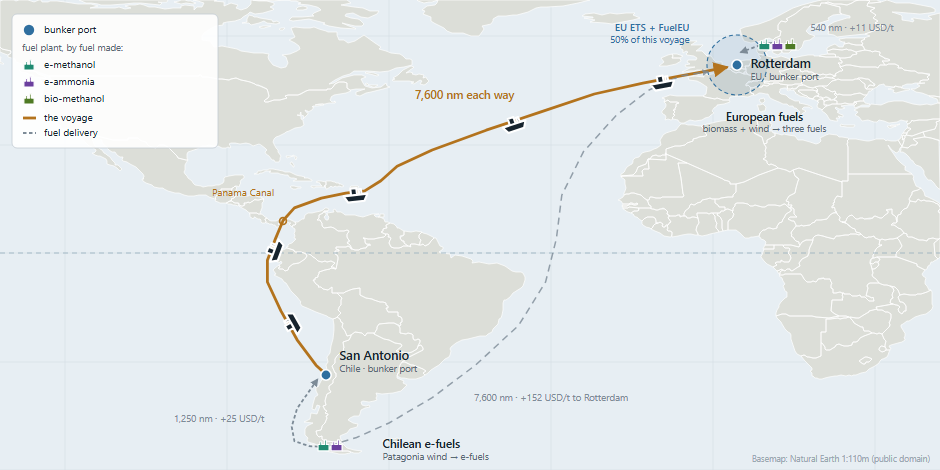)

*San Antonio to Rotterdam via the Panama Canal: the two bunker ports, the
voyage, and the fuel plants that supply it.*

A ship operator runs a fleet of 300 Panamax bulk carriers (~80,000 DWT)
carrying copper concentrate from **San Antonio, Chile** to **Rotterdam**, roughly 7,600
nautical miles each way via the Panama Canal, and returning in ballast (empty).
It is 2026 and every ship in the fleet burns fuel oil. The fleet is ageing and most of the
fleet has to be renewed before 2050, the horizon of the simulation.

Meanwhile, five major green fuel production plants are operating: an e-ammonia
plant and an e-methanol plant in Chile (Patagonia), 1,250 nm from the loading
port and 7,600 nm from Rotterdam, and in Europe, 540 nm from Rotterdam, a
bio-methanol plant alongside an e-ammonia and an e-methanol plant of its own.
Both e-fuels can therefore be made in either place. Conventional fossil fuels (oil and LNG) are also available
directly at the ports at market price.

The ships are exposed to two regulations: FuelEU Maritime and the EU ETS, both
of which cover half of the voyage.

The ship operator has to decide which fuel to bunker and where, and can choose
to retrofit ships or buy new ones at any time. The operator can also take
operational measures such as reducing speed, and can fit efficiency measures.
Four ship designs are available on the market:

| Configuration | Burns |
|---|---|
| `ship_oil` | conventional fuel oil |
| `ship_lng` | dual-fuel LNG |
| `ship_methanol` | dual-fuel methanol |
| `ship_ammonia` | dual-fuel ammonia |

This workshop is about understanding how Navigate imitates the potential
decision process of a ship operator in that case.

## What you'll do

**Part 1: Build the deck.** See how a case like this is expressed using Navigate's components library.

**Part 2: Explore the input data.** Look at the numerical assumptions that will drive the answer.

**Part 3: Understand the logic behind the model.** Understand how Navigate decides, for the fleet
operator and for the fuel producer, and read the results it produces.

**Part 4: Sensitivity analysis.** Change the inputs one at a time (prices, regulation,
fuel supply, the operator's temperament) and see what moves the answer.


## Setup (repeat if starting a fresh session)

Run the cell below on Colab or locally to set up the Navigate model.

In [1]:
# Setup. Works both on Google Colab and in a local checkout of the repository.
import os
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

Moved up to the repository root.
Navigate 1.0.0 is already installed.


Load the pre-made example that will be used to illustrate this part of the workshop.

In [2]:
from pathlib import Path

EXAMPLE = Path("simulations/examples/example_4")

# Fail loudly rather than printing an empty list. The setup cell above clones the
# branch named in BRANCH, so this deck is only here once it has been committed
# and pushed to that branch.
assert EXAMPLE.is_dir(), (
    f"{EXAMPLE} not found under {Path.cwd()}. On Colab the setup cell clones the "
    f"{BRANCH!r} branch, so this deck has to be committed and pushed there "
    "before the notebook can read it."
)


def show(path, first=None, grep=None, code_only=False):
    """Print a deck file: all of it, the first N lines, matching lines, or the
    command lines only (`code_only`, which drops the comments)."""
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    if code_only:
        print(f"# {Path(path).name}: command lines only, "
              f"open the file for the commentary")
        lines = [ln for ln in lines if ln.strip() and not ln.strip().startswith("#")]
    if grep:
        lines = [ln for ln in lines if grep in ln]
    if first:
        lines = lines[:first]
    for ln in lines:
        print(ln)


deck = sorted(EXAMPLE.rglob("*.nav")) + sorted(EXAMPLE.rglob("*.inc"))
assert deck, f"no .nav or .inc files under {EXAMPLE.resolve()}"

print("The deck:")
for p in deck:
    print(f"  {p.relative_to(EXAMPLE)}")

The deck:
  example_4.nav
  includes\bunker_logistics.inc
  includes\energy_efficiencies.inc
  includes\eu_ets.inc
  includes\fleet.inc
  includes\fuel_eu.inc
  includes\fuel_production.inc
  includes\ports.inc
  includes\producer.inc
  includes\regions.inc
  includes\report.inc
  includes\route.inc


---

# Part 1: Build the deck

A **deck** is the input to a Navigate run: one `.nav` file plus the `.inc` files
it includes. The `.nav` file is just a table of contents with two sections —
`DEFINE` for the nodes the simulation is made of, and `EVENTS` for the timeline
it steps through.

Everything in `DEFINE` is a **node**: one declared thing (a vessel, a fuel, a
port) written as a type, a name in quotes, and a block of attributes.

Read the `.nav` file first, to see how the deck is built for the current case.

In [3]:
show(EXAMPLE / "example_4.nav")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# EXAMPLE 4 - Panamax fleet, Chile to Rotterdam.

DEFINE {
    Load DefaultModelDefinition

    # ---- fleet ----
    Include "includes/fleet.inc"
    Include "includes/energy_efficiencies.inc"

    # ---- route ----
    Include "includes/route.inc"
    Include "includes/ports.inc"
    Include "includes/bunker_logistics.inc"

    # ---- fuel ----
    Include "includes/fuel_production.inc"
    Include "includes/regions.inc"
    Include "includes/producer.inc"
    Load DefaultEmission

    # ---- regulation ----
    Include "includes/eu_ets.inc"
    Include "includes/fuel_eu.inc"

    # ---- decision processes ----
    Load DefaultCalibration

    # ---- export ----
    Include "includes/report.inc"

    Load DefaultPlot
}

EVENTS {
    Load DefaultTimeStepYearly
}


## Fleet definition

The fleet starts as 300 fuel-oil vessels. The `set_fuel_conversion_cost` lines
put a price on retrofitting an existing oil ship to another configuration.

`InitialAgeDistribution` is the age spread of the world's 80k DWT bulk carriers,
taken from the library as `Curve("age_dist_bulk_carrier_80k_dwt_oil")`. Navigate
splits the fleet into one cohort per year of age, and the retrofit decision is
taken **per cohort**.

Two mechanisms will compete over the next 25 years:

- **Retrofit** — convert an existing oil ship to methanol or ammonia. An LNG ship can only
  be bought new, and can itself be retrofitted to ammonia.
- **Replace** — do nothing until a cohort retires, then let all four
  configurations compete as newbuilds.

In [4]:
show(EXAMPLE / "includes/fleet.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# FLEET - Panamax bulk carriers (~80,000 DWT), four configurations of one hull.
# All four share hull, propulsion curve, cargo capacity and OPEX.

Copy Vessel "bulk_carrier_80k_dwt_ice_oil"      "ship_oil"
Copy Vessel "bulk_carrier_80k_dwt_ice_methane"  "ship_lng"
Copy Vessel "bulk_carrier_80k_dwt_ice_methanol" "ship_methanol"
Copy Vessel "bulk_carrier_80k_dwt_ice_ammonia"  "ship_ammonia"

Fleet "copper_trade" {
	Vessels = [Vessel("ship_oil"),
	           Vessel("ship_lng"),
	           Vessel("ship_methanol"),
	           Vessel("ship_ammonia")]

	InitialVessels = 300 # Arbitrary number (represents 8% of the world Panamax fleet)
	InitialSplit = [1.0, 0.0, 0.0, 0.0] # Only ship oil vessels

	InitialAgeDistribution = [
		Curve("age_dist_bulk_carrier_80k_dwt_oil"),
		0,
		0,
		0
	]
	# Note: Orderbooks omitted for this example since the library's are sized for

### What a `Vessel` node looks like

`fleet.inc` never describes the ships themselves. It reaches for them with
`Copy Vessel`, which takes a vessel out of the assumptions library and gives
the copy a local name — so `ship_oil` is a copy of
`bulk_carrier_80k_dwt_ice_oil`.

In [5]:
# fleet.inc reaches these four with `Copy Vessel`. Here is one of them.
VESSEL_DIR = Path("assumptions/defaults/installation/Vessel")
show(VESSEL_DIR / "bulk_carrier_80k_dwt_ice_oil.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

Vessel "bulk_carrier_80k_dwt_ice_oil" {
	
	PropulsionLoad = Surface("bulk_carrier_80k_dwt_propulsion_load")
	ElectricalLoadAtSea = Variable("bulk_carrier_80k_dwt_electrical_load_sea")
	ElectricalLoadInPort = Variable("bulk_carrier_80k_dwt_electrical_load_port")
	HeatLoadAtSea = Variable("bulk_carrier_80k_dwt_heat_load_sea")
	HeatLoadInPort = Variable("bulk_carrier_80k_dwt_heat_load_port")
	
	PowerSystem = PowerSystem("ice_oil_bulk_carrier_80k_dwt")
	Tanks = [Tank("main_oil_bulk_carrier_80k_dwt")]
	
	Route = Route("operational_profile_bulk_carrier_80k_dwt")
	NominalCapacity = Variable("bulk_carrier_80k_dwt_nominal_capacity")
	Lifetime = Variable("bulk_carrier_80k_dwt_lifetime")
	
	CAPEX = Forecast("bulk_carrier_80k_dwt_capex")
	OPEX = Forecast("bulk_carrier_80k_dwt_opex")
	CostOfCapital = Variable("cost_of_capital_vessel")
}


## Route definition

The ships sail between the ports of San Antonio and Rotterdam, 7,600 nm apart
via the Panama Canal, at a service speed of 11.5 kn and 6.8 days alongside per
call.

The two legs are asymmetric in this example. Outbound the ship is full of copper concentrate; homebound it sails in ballast (empty). In the model, this can be set as `CapacityUtilizations = [1.0, 0.0]`.

In [6]:
show(EXAMPLE / "includes/route.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# ROUTE - San Antonio to Rotterdam and back via the Panama Canal.
# ROUND_TRIP visits the ports in the order listed; each entry in
# Distances/Speeds/CapacityUtilizations is the leg leaving the port at that index.

Vessel "ship_*" {
    Route = Route("copper_route")
}

Route "copper_route" {
    RouteType = ROUND_TRIP

    Ports = [Port("san_antonio"), Port("rotterdam")]

    # Days alongside per call, from the library's operational profile for this
    # class: TimeAtSea 0.55 over 24 calls/year = 0.45 x 365 / 24.
    PortDurations = [6.8, 6.8]

    # The distances for this example are invented since this route geography
    # is not included in the Navigate Assumption.
    Distances = [7600, 7600]

    # Modal service speed from the library's operational profile for this ship class.
    Speeds = [11.5, 11.5]

    # Laden out, ballast home.
    CapacityUtil

## Ports definition
Both ports sell the same five fuels: fuel oil, LNG, e-ammonia, e-methanol and
bio-methanol. Fuel is shipped from the region that made it to the port
that needs it, each cargo carrying the transport cost of the distance it
travelled - so European bio-methanol reaches San Antonio, and e-ammonia can
arrive at either port from either Patagonia or Europe.

In [7]:
show(EXAMPLE / "includes/ports.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# PORTS - what can be bunkered where. All three alternative fuels are bunkerable at
# both ports; a fuel is shipped to the port that did not produce it, the same way
# Chilean e-ammonia reaches Rotterdam.
# Delivered price is production cost plus transport, set in bunker_logistics.inc.

Port "san_antonio" {
    set_bunkering_allowed("methanol_electro", TRUE)
    set_bunkering_allowed("ammonia_electro", TRUE)
    set_bunkering_allowed("methanol_bio", TRUE)
}

Port "rotterdam" {
    set_bunkering_allowed("methanol_electro", TRUE)
    set_bunkering_allowed("ammonia_electro", TRUE)
    set_bunkering_allowed("methanol_bio", TRUE)
}

Port "*" {
    # the two fossil fuels are treated as globally traded and available anywhere
    set_bunkering_allowed("fossil_fuel_oil", TRUE)
    set_bunkering_allowed("liquefied_natural_gas", TRUE)

    # Fossil prices and upstream

## Fuel production

Five fuels are considered in this model: oil, LNG, e-ammonia, e-methanol and bio-methanol.
A vessel is defined by the fuel **type** its engine and tanks accept, and several fuels can satisfy one type. For example, the same methanol ship can accept bio-methanol, e-methanol or oil (dual-fuel engine).

E-ammonia, e-methanol and bio-methanol need to be produced by a fuel plant. 

In [8]:
show(EXAMPLE / "includes/fuel_production.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# FUEL PRODUCTION - five fuels for four ships; both methanols feed one ship.
#
# Only the siting is set here (region and electricity source). Lead times,
# lifetimes, capacities and process economics come from the library.
# Feedstock ceilings for the two methanols are set in producer.inc.

# ---- fossil (global commodities, no production chain modelled) --------------
Import Fuel "fossil_fuel_oil"
Import Fuel "liquefied_natural_gas"

# ---- Chilean e-methanol -----------------------------------------------------
Import Fuel "methanol_electro"
Import Plant "plant_methanol_electro_alkaline"
Plant "plant_methanol_electro_alkaline" {
    Region = Region("americas")
    Source = Source("renewable")   # dedicated wind, not the Chilean grid
}
Import Process "methanol_synthesis_electro_alkaline"
Import Process "hydrogen_electro_alkaline"
Import Process "electrolys

A **producer** is the agent that decides whether to build fuel plants or not and which ones. We have two producers in this model, split by fuel family rather than by geography: an e-fuel producer that can build e-ammonia and e-methanol in either Patagonia or Europe, and a biofuel producer that builds bio-methanol (only in Europe). Because the e-fuel producer owns two sites for each of its fuels, it has a choice to make between them on delivered cost - Chilean power is cheaper, European delivery to Rotterdam is shorter. The feedstocks for bio-methanol (biomass) and e-methanol (biogenic CO2) are constrained (using an arbitrary number in this simulation) meaning that plant build is limited for these two fuels.

In [9]:

show(EXAMPLE / "includes/producer.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# PRODUCERS - the agents that decide whether to build another plant.
#
# Ownership is by FUEL FAMILY, not by geography. A Producer in Navigate is an EPC
# market rather than a place, so the e-fuel producer builds wherever a site is
# cheapest delivered - and because it owns two plants making the same fuel, it
# has a choice to make between them on delivered cost.

Producer "producer_efuel" {
	Plants = [Plant("plant_methanol_electro_alkaline"),
	          Plant("plant_ammonia_electro_alkaline"),
	          Plant("plant_methanol_electro_alkaline_europe"),
	          Plant("plant_ammonia_electro_alkaline_europe")]

	MaximumDevelopment = <Forecast("epc_global_capacity_mid") * Forecast("epc_global_share_shipping")>

	# Ceiling on biogenic CO2, the feedstock both its e-methanol plants draw on.
	# This one only bites at the end: no e-methanol is built before 2040,

## Implement bunker logistics

`LiquidMarketFuels` such as fuel oil and LNG are treated as global commodities:
available anywhere at a quoted price, with no plant, producer or logistics chain
modelled.

Everything else has to be physically moved from the plant to the bunker port,
priced at `distance × rate`. `set_distance` gives the sea distance from a
production region to a port, and `set_transport_cost` the rate per ton per
nautical mile.

In [10]:
show(EXAMPLE / "includes/bunker_logistics.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# BUNKER LOGISTICS - production site to bunker port.
# LiquidMarketFuels are treated as global commodities: quoted price, no plant,
# no producer, no logistics chain. Everything else picks up distance x rate.

BunkerLogistics {
	LiquidMarketFuels = [Fuel("fossil_fuel_oil"), Fuel("liquefied_natural_gas")]

	# The values have been invented for this example:
	# nautical miles from the production region to each port
	set_distance("americas", "san_antonio", 1250)
	set_distance("americas", "rotterdam", 7600)
	set_distance("europe", "rotterdam", 540)
	set_distance("europe", "san_antonio", 7600)

	# USD per ton per nautical mile
	set_transport_cost("*", 0.02)
}


## Implement regulations (FuelEU and EU ETS)

![The EU regulatory package: the Renewable Energy Directive sets emissions values, sustainability criteria, GHG emission savings and certification; FuelEU Maritime limits the GHG intensity of fuel on a declining staircase to 2050, with penalties paid for emissions above the annual target and pooling rewarding vessels below it; and the EU Emissions Trading System puts a price on every tonne of GHGs, with ships buying EU Allowances](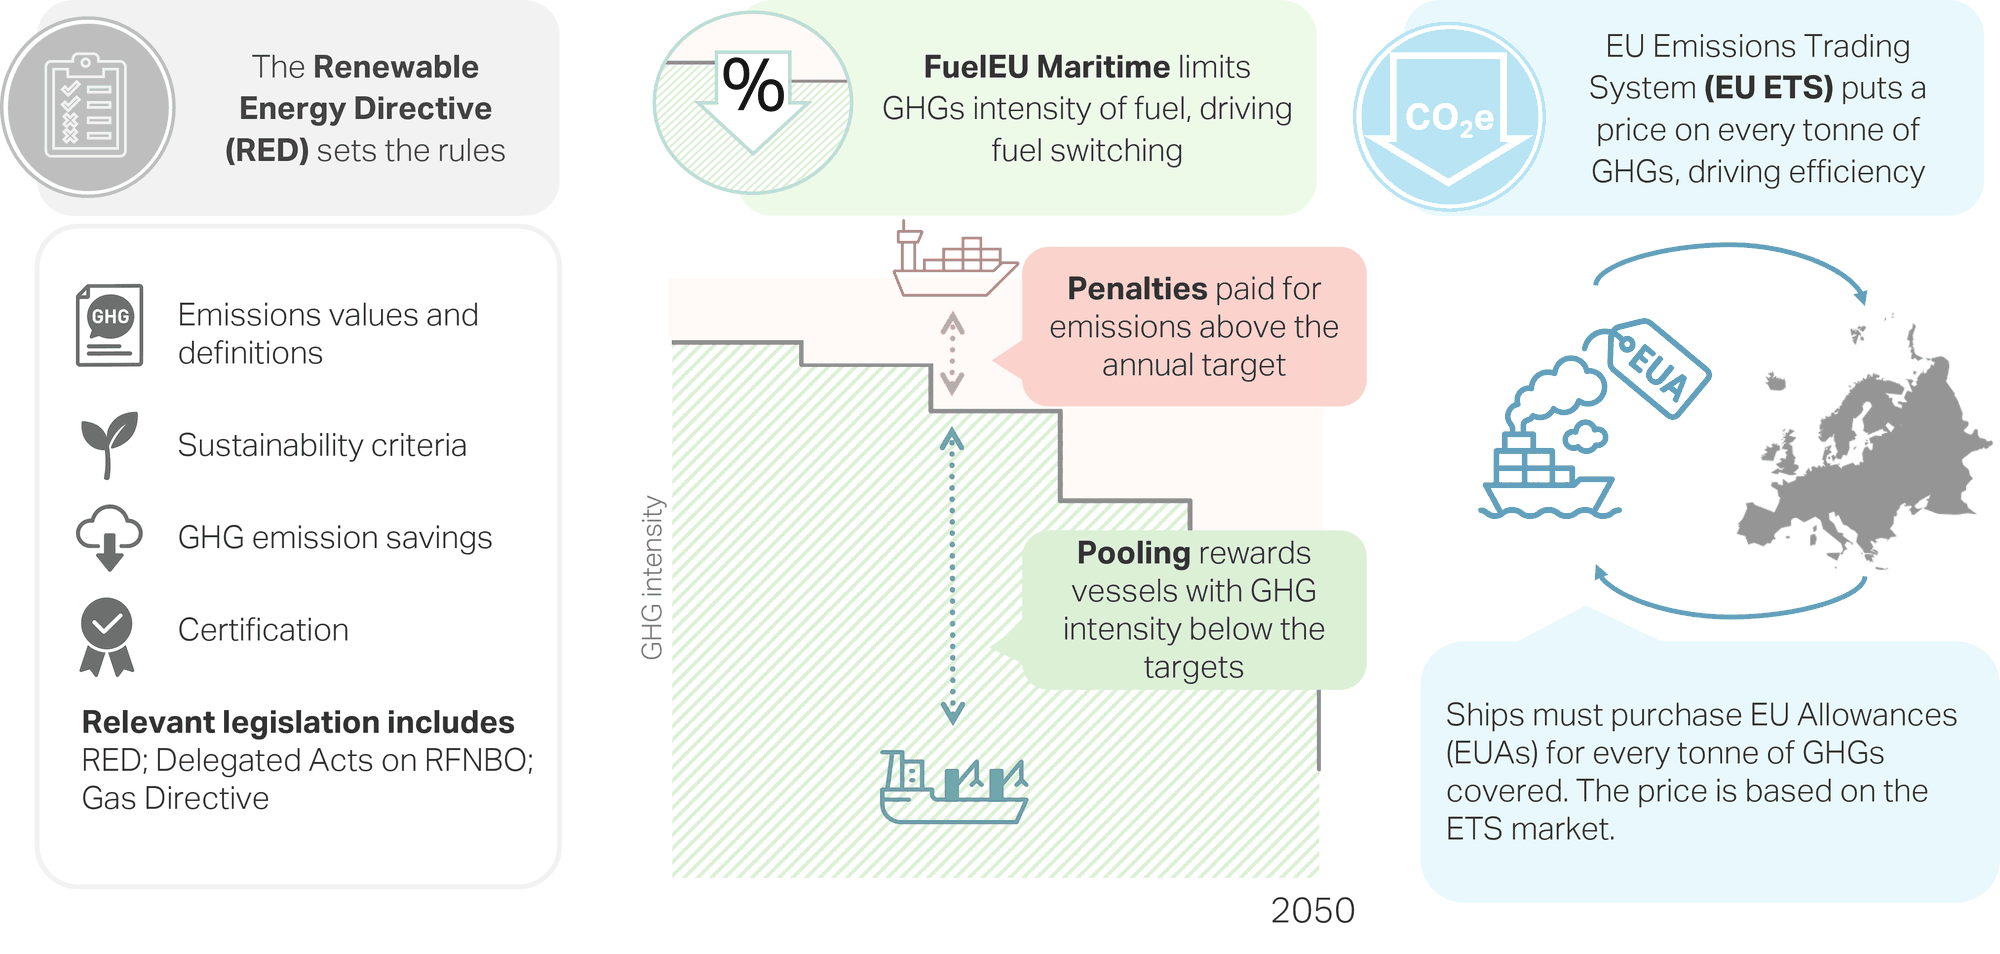)

*FuelEU Maritime caps the GHG **intensity** of the fuel and so drives fuel switching; the EU ETS prices **every tonne** emitted and so drives efficiency. The Renewable Energy Directive supplies the definitions and certification both rely on.*

In Navigate a regulation is applied to a specific geography. `Jurisdiction` lists the
ports that sit inside the regulatory scheme. In this example, FuelEU and EU ETS cover the port of Rotterdam, but not San Antonio. Three fractions decide how much of the fuel burned on a voyage is counted.

The fractions are applied leg by leg. In Navigate, a *leg*
is one port-to-port sailing between two consecutive ports on the route. This
round trip has two, out and back. Navigate reserves the word for the ship's own
route segments, so a fuel's journey from plant to bunker port is a *trip*, not a
leg. Navigate classifies each leg by its two end ports, and the port stay. On this round trip that gives:

| Leg or port stay | Classification | Counted for regulation |
|---|---|---|
| San Antonio → Rotterdam, 7,600 nm ≈ 27.5 days | one end inside → `InterFraction` | **50 %** |
| Rotterdam → San Antonio, 7,600 nm ≈ 27.5 days | one end inside → `InterFraction` | **50 %** |
| alongside in Rotterdam, 6.8 days per call | inside → `IntraFraction` | **100 %** |
| alongside in San Antonio, 6.8 days per call | outside → `ExtraFraction` | 0 % |

The two instruments apply to different emission scopes:

- EU ETS on **TTW — tank to wake.** Emissions that come out of the ship engine.
- FuelEU on **WTW — well to wake.** TTW, plus emissions to make and deliver the
  fuel.

Each instrument is one `Regulation` node, and the `.nav` includes one file per
instrument — `includes/eu_ets.inc` and `includes/fuel_eu.inc`.

Beyond the geography, most of the content is **emission factors**: a
`set_fuel_ttw` line per fuel per gas, saying what a ton of that fuel emits once
burned. FuelEU adds `set_fuel_wtt` lines for the fuels whose upstream value the
regulation fixes by default.
E-fuels are omitted since there are no default factors. Upstream intensity is then calculated by Navigate from the production chain in `regions.inc`.

In [11]:
show(EXAMPLE / "includes/eu_ets.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# EU ETS - absolute price on CO2-equivalent burned on board, no free allowance.
#
# The coverage fractions are applied PER LEG, not to the round trip. Both legs
# here are inter-jurisdiction, so both count at 50%. Port stays are classified
# by their own port, so Rotterdam counts in full and San Antonio not at all.

Regulation "eu_ets" {
	Measure = ABSOLUTE
	Scheme = INDIVIDUAL
	Scope = TTW
	IncludeSlip = FALSE   # methane slip is carried in the TTW methane factors
	Emissions = [Emission("carbon_dioxide"), Emission("methane"), Emission("nitrous_oxide")]
	Fuels = Fuel("*")

	# Rotterdam is the only EU port on this route
	Jurisdiction = [Port("rotterdam")]
	IntraFraction = 1     # both ends in the EU
	InterFraction = 0.5   # one end in the EU
	ExtraFraction = 0     # neither end in the EU

	RemedialCost = <Forecast("eu_ets_carbon_credit_price") * Forecast("eu

FuelEU is the same shape, with two differences to look for: `Scheme = FLEXIBLE` (applies for the fleet) instead of `INDIVIDUAL` (applies per vessel), and the `set_fuel_wtt` lines that fix upstream intensity for the fossil fuels and bio-methanol — but not for the two e-fuels.

In [12]:
show(EXAMPLE / "includes/fuel_eu.inc")

# SPDX-FileCopyrightText: 2026 Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
# SPDX-License-Identifier: CC-BY-4.0

# FUELEU MARITIME - caps WTW greenhouse gas intensity, tightening over time.
#
# The e-fuels get no set_fuel_wtt line below on purpose: Navigate calculates
# their upstream intensity from the production chain in regions.inc, so the
# power price at each site feeds their FuelEU score. The fossil fuels and
# bio-methanol instead use the regulation's own defaults.
#
# Same coverage geography as eu_ets.inc.

Regulation "fuel_eu" {
	Measure = INTENSITY
	Scheme = FLEXIBLE     # pooled and banked across years, unlike the ETS
	Scope = WTW
	IncludeSlip = FALSE   # methane slip is carried in the TTW methane factors
	Emissions = [Emission("carbon_dioxide"), Emission("methane"), Emission("nitrous_oxide")]
	Fuels = Fuel("*")

	Jurisdiction = [Port("rotterdam")]
	IntraFraction = 1
	InterFraction = 0.5
	ExtraFraction = 0

	RemedialCost = Variable("fuel_eu_remedial_cost")


### In summary

The two instruments pull on different things:

| | FuelEU Maritime | EU ETS |
|---|---|---|
| What it limits | the **intensity** of the energy used, gCO2eq/MJ | the **quantity** emitted, tonnes CO2eq |
| What you pay | a penalty on how far you miss the annual target | a price on every covered tonne |
| So the cheapest answer is to | **switch fuel** — a cleaner fuel pulls the average down | **burn less** — slow down, fit efficiency measures |
| Emissions counted | **well-to-wake**: how the fuel was made counts | **tank-to-wake**: only what the ship burns on board |

For FuelEU, the limit is a **staircase**: it holds flat for years and then
steps down, so the pressure to switch arrives in jumps rather than smoothly.


---

# Part 2: Explore the input data

Before running the model, it is worth looking at the numbers behind it: they
explain most of the result.

Navigate fetches numerical assumptions from the
assumptions library as it reads the deck.


## Numerical assumptions in Navigate

Almost every assumption in Navigate is a **lookup table** written into a `.inc`
file: when the model needs a value it reads one out of the table, interpolating
between the rows. Five node types carry the numbers, and they differ only in what
you look a value up *by*.

| Node | Look it up by | In this deck |
|---|---|---|
| `Variable` | nothing — it is a single number | `fuel_eu_remedial_cost`: **760 USD/ton CO2eq** of shortfall |
| `Curve` | one number | `age_dist_bulk_carrier_80k_dwt_oil`: at age 12, **10.6 %** of the fleet |
| `Forecast` | a date | `eu_ets_carbon_credit_price`: in 2050, **417 USD/ton CO2eq** |
| `Surface` | two numbers | `bulk_carrier_80k_dwt_propulsion_load`: at 11.5 kn and utilisation 1 (laden), **4.82 MW** |
| `Timetable` | a date *and* a number | `methanol_synthesis_electro_capex`: in 2025, a 4,000 t/day plant costs **558 USD/(ton of annual capacity)** |

The Center has collected a wide range of these numbers from partners and external
sources, and they have been validated by experts. They can all be found in the
`assumptions` folder.

That folder holds an `installation` and a `user` copy.
`defaults/` holds individual nodes, one folder per type, and is read whenever a deck names
one: `Import Fuel "methanol_bio"` picks up
`defaults/installation/Fuel/methanol_bio.inc`. 

`modules/` holds ready-made bundles invoked with `Load`: `Load DefaultRegulation` reads
`modules/installation/default_regulation.inc`, which is itself just a short list of
imports. 

In both cases Navigate looks in `user/` first and falls back to
`installation/`, so you can use your own numbers by dropping a file into the
matching `user/` folder under the same name. It takes precedence, and nothing the
Center ships has to be edited.

See the reference manual for
[Forecast](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/forecast.html),
[Curve](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/curve.html),
[Surface](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/surface.html),
[Timetable](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/timetable.html)
and
[Variable](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/variable.html)
if you want the full attribute reference.


The next cell needs to be run to prepare the data extraction from Navigate.


In [13]:
import argparse
import contextlib
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
from navigate.bunker.bunker_algorithm import BunkerAlgorithm
from navigate.core.enum_ import BunkerScopeID
from navigate.core.expectations.vessel_expectation import VesselExpectation
from navigate.fuel.producer import producer_planning
from navigate.vessel.fleet import fleet_technology
from navigate.manager import SimulationManager

# The Setup cell at the top normally moves us to the repository root. Repeat the
# check here so this Part also works on its own, e.g. after a kernel restart.
if not (Path("navigate").is_dir() and Path("assumptions").is_dir()):
    if Path("../../navigate").is_dir():
        os.chdir("../..")
assert Path("assumptions").is_dir(), (
    f"not at the repository root ({Path.cwd()}) -- run the Setup cell at the "
    "top of the notebook first"
)

NAV = Path("simulations/examples/example_4/example_4.nav")
ARGS = argparse.Namespace(data_dir=Path("./assumptions"), solver=None)

# Parse the deck, then solve it once. Part 2 is mostly about inputs, but the
# fuels' well-to-tank emissions are not an input at all -- Navigate derives them
# from the production chain -- so the run is what makes them readable. Every later
# cell in this Part reads its numbers off `manager`; Part 3 builds its own.
manager = SimulationManager()
manager.read_deck(NAV, ARGS)

# Copy the Regulation's emission factors before the run, so the charts in this Part
# can show what the DECK states and never something the run derived. A factor the deck
# leaves out stays None here, which is exactly how the model reads it: supplied factors
# are used as given, omitted ones are derived from the fuel and the converter.
DECK_FACTORS = {name: {"gwp": dict(reg.global_warming_potential),
                       "ttw": dict(reg.fuel_TTW),
                       "wtt": dict(reg.fuel_WTT)}
                for name, reg in manager.nodes.regulations.items()}

with contextlib.redirect_stdout(io.StringIO()):   # one line per year, not needed here
    manager.run()

import matplotlib.pyplot as plt


def forecast_to_frame(name, nodes=None):
    """A Forecast node's resolved (date, value) table as a DataFrame."""
    node = (nodes or manager.nodes).forecasts[name]
    return pd.DataFrame({"date": pd.to_datetime(node.get_x_date()),
                         "value": [node.calculate(x) for x in node.get_x()]})


def forecast_curve(name, points=600):
    """What the model actually returns for a Forecast, sampled densely.

    Joining the table rows with straight lines would imply linear interpolation.
    `fuel_eu_target_reduction` sets `Interpolate = PREVIOUS`, so it holds each
    value flat and then steps down. Sampling calculate() draws whatever the node
    really does, whichever mode it uses.
    """
    node = manager.nodes.forecasts[name]
    xs = np.asarray(node.get_x(), dtype=float)
    rows = pd.to_datetime(node.get_x_date())
    grid = np.linspace(xs.min(), xs.max(), points)
    when = rows[0] + pd.to_timedelta(grid - xs[0], unit="D")
    return when, np.array([node.calculate(x) for x in grid])


# One house style for every figure in the workshop. It lives in
# docs/workshop/_style.py rather than in this cell, so that this notebook and
# notebook 4 cannot drift apart - which is exactly what had happened. The
# colours are Navigate's own, and that file explains the one thing about them
# that surprises people: the hue says how a fuel was MADE, not which molecule it
# is, so bio-methanol and e-methanol are deliberately different colours.
import sys

_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, BLUE, GREEN, GRID, INK, MUTED, ORANGE, PALE, SUBINK,
                    TICK, config_colour, config_label, cost_colour, fuel_colour,
                    fuel_label, fuel_sorted, series_colours)


def panel(ax, series, title, ylab):
    """One forecast panel: the model's own response, with its table rows marked."""
    for (name, label), colour in zip(series, (BLUE, ORANGE)):
        when, value = forecast_curve(name)
        ax.plot(when, value, color=colour, lw=2, label=label, zorder=3)
        rows = forecast_to_frame(name)
        if len(rows) <= 8:          # mark the rows only where they are readable
            ax.plot(rows["date"], rows["value"], "o", color=colour, ms=5,
                    mec="white", mew=1.2, zorder=4)
    ax.set_title(title, fontsize=10, color=INK, loc="left")
    ax.set_ylabel(ylab, fontsize=8, color=SUBINK)
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    ax.margins(y=0.15)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    if len(series) > 1:             # a legend only where there are two to tell apart
        ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK)


——————————————————————————————————————————————————————————————————————————————————————————————————
            |    |    |                                  .oO
           )_)  )_)  )_)                             __/___                  _    _
          )___))___))___)\                     _____/______|              __|_|__|_|__
         )____)____)_____)\\           _______/_____\_______\_____      _|____________|__
       _____|____|____|____\\\__       \              < < <       |    |o o o o o o o o /
~~~~~~~\                   /~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        ´´´´´´´´´´´´´´´´´´´              Navigate
——————————————————————————————————————————————————————————————————————————————————————————————————
        Navigate - an integrated assessment model for decarbonizing shipping
        Developed by Fonden Mærsk Mc-Kinney Møller Center for Zero Carbon Shipping
        Version 1.0.0 - for questions, contact navigate@zerocarbonshipping.com


---

## 1. Data about the fleet

The most important data that will affect how the fleet ends up being designed are:
- the ship retrofitting costs from one fuel to another
- the CAPEX of new build ships and their financing conditions
- the efficiency technology on offer, and what it costs
- the sensitivity of the ship operator towards different market signals

Data that also influences the fleet design but is not presented in this example is the composition of the ship orderbook (the ships already ordered but not yet delivered).

### Newbuild CAPEX, retrofitting costs and financing conditions
The next cell presents the ship retrofitting costs, the CAPEX of newbuild ships and the cost of capital each configuration is financed at, used as base assumptions.

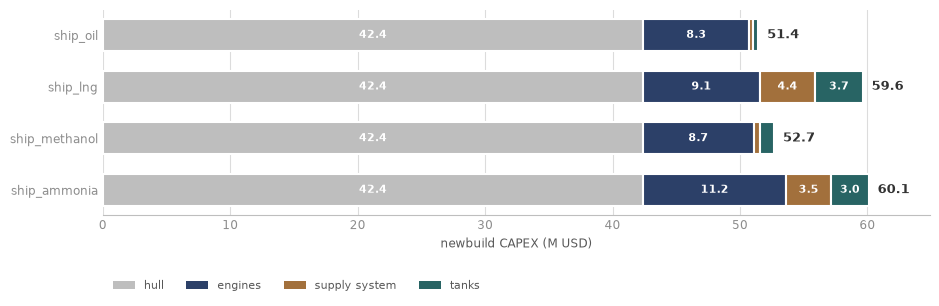

Retrofitting an existing ship, instead of replacing it:


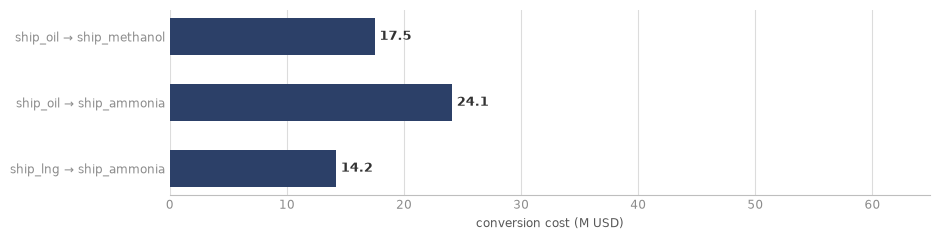

In [14]:
# What the four configurations cost to build.
#
# In this example, the HULL is identical by design - same 80,000 DWT Panamax - so the premium
# for a dual-fuel ship is not in Vessel.CAPEX but in the machinery. The model charges three
# pieces of it, and the charter rate carries all three (navigate/vessel/charter.py):
#   engines        the converters in the PowerSystem, priced per MW installed
#   supply system  the PowerSystem's own CAPEX, a lump sum for fuel handling and safety
#   tanks          each Tank on the vessel, priced per m3 of containment
def scalar(x, t=0.):
    """Resolve a Forecast / Variable / plain number to a value at time t."""
    if hasattr(x, "calculate"):
        return float(x.calculate(t))
    if hasattr(x, "get"):
        return float(x.get())
    return float(x)

rows = []
for name, v in manager.nodes.vessels.items():
    engines = sum(scalar(c.power_capacity) * scalar(c.CAPEX)
                  for c in v.power_system.get_converters())
    supply = scalar(v.power_system.CAPEX)
    tanks = sum(scalar(t.size) * scalar(t.CAPEX) for t in v.tanks)
    machinery = engines + supply + tanks
    hull = scalar(v.CAPEX)
    rows.append({"configuration": name,
                 "hull (M USD)": hull / 1e6,
                 "engines (M USD)": engines / 1e6,
                 "supply system (M USD)": supply / 1e6,
                 "tanks (M USD)": tanks / 1e6,
                 "newbuild total (M USD)": (hull + machinery) / 1e6,
                 "capacity (DWT)": scalar(v.nominal_capacity),
                 "life (yr)": scalar(v.lifetime)})

table = pd.DataFrame(rows).set_index("configuration")
# The same four numbers as a picture, so the split is visible rather than read.
# The hull is drawn in grey because it is the part that does NOT vary: identical
# by design across all four, and still four fifths of the bill. Only the three
# machinery components carry a colour, because they are what the fuel choice moves.
from matplotlib.patches import Patch

COMPONENTS = [("hull (M USD)", "hull", MUTED),
              ("engines (M USD)", "engines", BLUE),
              ("supply system (M USD)", "supply system", ORANGE),
              ("tanks (M USD)", "tanks", GREEN)]

fig, ax = plt.subplots(figsize=(9.5, 3.4))
y = range(len(table))
left = [0.] * len(table)

for column, _label, colour in COMPONENTS:
    values = table[column].to_numpy()
    ax.barh(list(y), values, left=left, height=.62, color=colour, zorder=3,
            edgecolor="white", linewidth=1.5)
    for i, (value, start) in enumerate(zip(values, left)):
        if value >= 2.:                  # only where the segment can hold a number
            ax.annotate(f"{value:.1f}", (start + value / 2, i), ha="center",
                        va="center", fontsize=8, color="white", fontweight="bold",
                        zorder=5)
    left = [a + b for a, b in zip(left, values)]

for i, total in enumerate(left):
    ax.annotate(f"{total:.1f}", (total + 0.7, i), va="center", fontsize=9,
                color=INK, fontweight="bold")

ax.set_yticks(list(y), list(table.index))
ax.set_xlabel("newbuild CAPEX (M USD)", fontsize=8.5, color=SUBINK)
CAPEX_XLIM = max(left) * 1.08   # shared with the retrofit chart, so the two compare
ax.set_xlim(0, CAPEX_XLIM)
ax.invert_yaxis()
ax.grid(axis="x", color=GRID, lw=.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TICK, labelsize=8.5, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.legend(handles=[Patch(facecolor=colour, label=label)
                   for _column, label, colour in COMPONENTS],
          fontsize=8, frameon=False, labelcolor=SUBINK, ncol=4,
          loc="lower left", bbox_to_anchor=(0, -.42))
fig.tight_layout()
plt.show()

# What it costs to convert a ship that already exists, instead of replacing it.
# get_fuel_conversion_cost_pairs() returns only the pairs that were actually given
# a cost; the underlying dict also carries None-valued self-pairs.
fleet = manager.nodes.fleets["copper_trade"]
retrofits = pd.DataFrame(
    [{"from": frm, "to": to,
      "retrofit (M USD)": scalar(fleet.fuel_conversion_cost[(frm, to)]) / 1e6}
     for frm, to in fleet.get_fuel_conversion_cost_pairs()]
).set_index(["from", "to"])

print("Retrofitting an existing ship, instead of replacing it:")

fig, ax = plt.subplots(figsize=(9.5, 2.5))
routes = [f"{frm} \u2192 {to}"
          for frm, to in retrofits.index]
costs = retrofits["retrofit (M USD)"].to_numpy()

ax.barh(range(len(routes)), costs, height=.55, color=BLUE, zorder=3)
for i, cost in enumerate(costs):
    ax.annotate(f"{cost:.1f}", (cost + 0.4, i), va="center", fontsize=9,
                color=INK, fontweight="bold")

ax.set_yticks(range(len(routes)), routes)
ax.set_xlabel("conversion cost (M USD)", fontsize=8.5, color=SUBINK)
ax.set_xlim(0, CAPEX_XLIM)     # same scale as the newbuild chart above
ax.invert_yaxis()
ax.grid(axis="x", color=GRID, lw=.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TICK, labelsize=8.5, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
fig.tight_layout()
plt.show()


In this example, the newbuild hull is the same 42.4 M USD whichever fuel it burns, so the newbuild premium
for going dual-fuel is entirely in the machinery (engines, supply system and tanks): about **+1.2 M for methanol,
+8.2 M for LNG, +8.7 M for ammonia** over a plain oil ship. Ammonia and LNG machinery cost
about the same, because both need containment and fuel-handling equipment that the oil ship
does not. For LNG almost all of the premium is that equipment; ammonia adds a dearer engine on top of it.

The loss of cargo is deliberately not included in the base assumptions: with an optimized ship design it can be reduced to a negligible amount.
(If needed, a number can however be added in the model by changing the Nominal Capacity of a specific ship.)

Important note: the ammonia ship is financed at an **11.05 %** rate in the near future (due to a higher risk) against **8.89 %** for the other
three, easing back to the same 8.89 % by 2030 (when the technology is expected to have matured).

### Efficiency technology on offer, and what is already fitted

The assumptions library carries seven efficiency measures for this vessel
class. This deck fits six of them, each with its own cost and saving:

| Measure | Saves | CAPEX | OPEX/yr | Life |
|---|---|---|---|---|
| Flettner rotor | 0.4 MW of external power | 2.0 M | 40 k | 25 yr\* |
| Hull painting | 5.0 % of propulsion | 200 k | 24 k | **5 yr** |
| Propeller improvement devices | 2.0 % of propulsion | 150 k | 0 | 25 yr\* |
| Variable frequency drive | 10.0 % of electrical | 100 k | 5 k | 25 yr\* |
| Lighting system | 2.5 % of electrical | 100 k | 0 | 25 yr\* |
| Exhaust-gas boiler (aux) | 5.0 % of heat | 100 k | 10 k | 25 yr\* |

\* Not a number the deck states. A measure that sets no lifetime of its own
lasts as long as the hull it is fitted to and is never re-bought: it is paid for
once and written off over the ship's whole life, and these hulls are scrapped at
25 years. Hull painting is the one exception, and because it carries a lifetime
it *is* re-bought - the full 200 k again every five years, since the library
sets no reduced replacement cost.

All six are on offer from the first year, so whether they arrive, and when, is
the model's call rather than something the deck schedules.

The fleet does not start empty, though. It starts with a set of pre-installed efficiency technology defined by `set_initial_technology_share` in `includes/energy_efficiencies.inc`. The uptake and share per technology can be found in (i.e. for the world Panamax fleet):

```
assumptions/defaults/installation/Curve/uptake_<measure>_bulk_carrier_panamax.inc
```

Five start partly fitted at the library's observed uptake for the world Panamax
fleet; the Flettner rotor starts at zero, because no Panamax in that fleet
carries one.

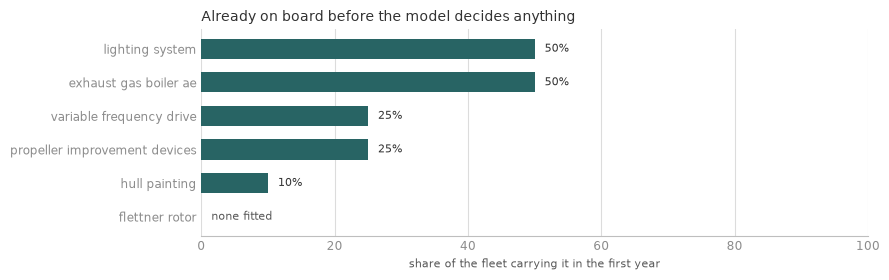

In [15]:
# What each hull already carries before the model decides anything. Read off the
# parsed deck: initial_technology_share maps (vessel, technology) to the library
# Curve the deck pointed it at, or None for a measure with no observed uptake.
_fleet_node = manager.nodes.fleets["copper_trade"]
start_share = {}
for (_vessel, _tech), _curve in _fleet_node.initial_technology_share.items():
    _short = _tech.replace("_bulk_carrier_panamax", "")
    start_share[_short] = float(_curve.get(0.)) if _curve is not None else 0.

_order = sorted(start_share, key=start_share.get)

fig, ax = plt.subplots(figsize=(9, 2.9))
ax.barh(range(len(_order)), [start_share[t] * 100 for t in _order], height=.6,
        color=[GREEN if start_share[t] > 0 else MUTED for t in _order], zorder=3)
for _i, _t in enumerate(_order):
    ax.annotate(f"{start_share[_t] * 100:.0f}%" if start_share[_t] else "none fitted",
                (start_share[_t] * 100 + 1.5, _i), va="center", fontsize=8,
                color=INK if start_share[_t] else SUBINK)
ax.set_yticks(range(len(_order)), [t.replace("_", " ") for t in _order])
ax.set_xlim(0, 100)
ax.set_xlabel("share of the fleet carrying it in the first year", fontsize=8,
              color=SUBINK)
ax.set_title("Already on board before the model decides anything", fontsize=10,
             color=INK, loc="left")
ax.grid(axis="x", color=GRID, lw=.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TICK, labelsize=8.5, length=0)
for _side in ("top", "right", "left"):
    ax.spines[_side].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
fig.tight_layout()
plt.show()


### How sharply the operator reacts

The **decision sensitivities** the `.nav` pulls in with `Load DefaultCalibration`
set how sharply the operator responds to a cost difference.

In [16]:
# The sensitivities that govern how strongly an advantage translates into a
# change of fuel, of hull, or of equipment. These are plain attributes on the
# Fleet.
print("Decision sensitivities (from DefaultCalibration):")
for label, value in [
    ("InterFuelSensitivity", fleet.inter_fuel_sensitivity),
    ("IntraFuelSensitivity", fleet.intra_fuel_sensitivity),
    ("FuelConversionSensitivity", fleet.fuel_conversion_sensitivity),
    ("TechnologySensitivity", fleet.technology_sensitivity),
]:
    print(f"  {label:28} {scalar(value):.2f}")


Decision sensitivities (from DefaultCalibration):
  InterFuelSensitivity         0.75
  IntraFuelSensitivity         0.75
  FuelConversionSensitivity    2.00
  TechnologySensitivity        2.00


The sensitivities are the dial on how much any of this matters. At
`InterFuelSensitivity = 0.75`, a 10 % cost advantage shifts the odds of a fuel
type by roughly a quarter. At `FuelConversionSensitivity = 2`, an NPV advantage worth 5 % of ship CAPEX
doubles the odds of a retrofit. These are calibration, not assumptions about the
world: they describe how decisively a shipowner acts on a given signal.

---

## 2. Data about the fuels

An e-fuel is mostly electricity, roughly 70–80 % of its production cost, so the
Chilean power price is the number that decides whether making fuel in Patagonia
is worth doing at all. The fossil prices are what it has to beat.

Deliberately not shown: the plant and process economics. The synthesis and
electrolyser cost tables are real inputs, but they are currently flat in time (only
larger economies of scale may change the business over time). Learning rates are an option 
that will be developed in a future version of Navigate.
Build capacity is not binding here, but the gasifiable-biomass ceiling is: it is
set where it limits how much bio-methanol this one trade can source, so that
fuel is capped by what can be grown rather than by what the ships would buy.
These assumptions will be tested with sensitivities in Part 4.

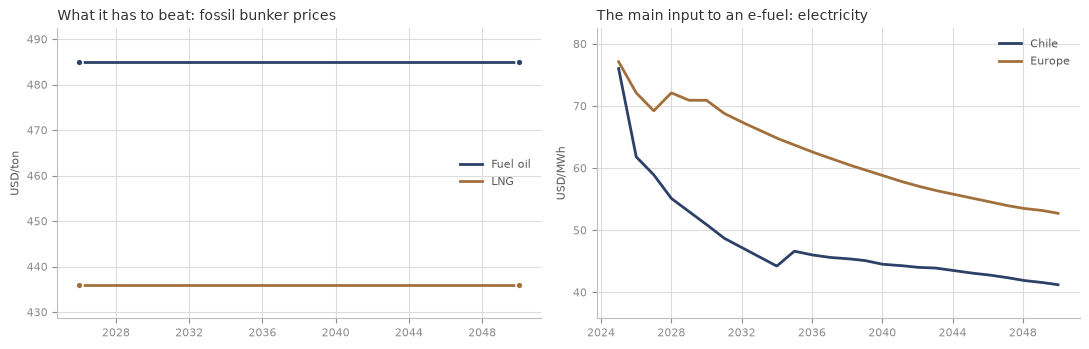

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

panel(ax1, [("fossil_fuel_oil_price_global", "Fuel oil"),
            ("liquefied_natural_gas_price_global", "LNG")],
      "What it has to beat: fossil bunker prices", "USD/ton")
panel(ax2, [("electricity_cost_americas_mid", "Chile"),
            ("electricity_cost_europe_mid", "Europe")],
      "The main input to an e-fuel: electricity", "USD/MWh")

fig.tight_layout()
plt.show()


Two things to take from those panels.

**Fossil prices are flat by assumption.** This deck does not assume fuel oil
becomes expensive on its own, so nothing in the fuel data forces a switch. If
the fleet moves, it is because emitting got dear, not because oil did.

**Chilean power is cheaper than European, and falling faster.** That is the
whole premise of making e-fuel in Patagonia for this example.


### What the feedstock ceilings allow

Two of these fuels are limited by something other than money. Bio-methanol needs
gasifiable biomass and e-methanol needs biogenic CO2, and `includes/producer.inc`
caps how much of each pool this trade may draw: the library's pools are global
and its `*_share_shipping` factors are the whole sector's slice, so each ceiling
is that slice reduced again to one fleet on one trade.

Below are the ceilings themselves, straight out of the deck. Whether either one
ever binds is a result rather than an input, so that waits until Part 3, with
the rest of what the twenty-five years produced.


  Gasification feedstock     ceiling  0.81 Mt/yr in 2026, rising to  0.95 by 2050
  Biogenic CO2 (PS)          ceiling  0.14 Mt/yr in 2026, rising to  0.53 by 2050


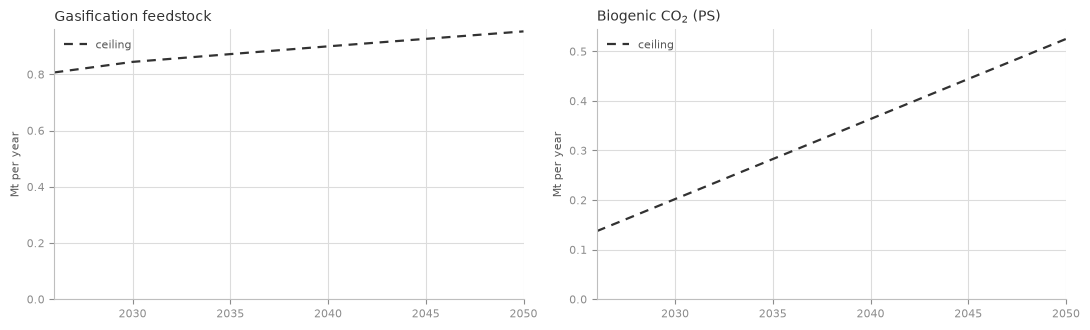

In [18]:
# What the two feedstock ceilings allow. The ceilings only - what the run draws
# against them is a result, and is plotted in Part 3.
#
# A ceiling is a deck EXPRESSION rather than a plain Forecast, so it is resolved
# the way this Part resolves emission factors: `calculate` where the node has
# one, `get(t)` where it does not.
from navigate.illustrations.plots._labels import FEEDSTOCK_LABEL

_days = manager.get_timeline()
_years = manager.get_dateline().astype("datetime64[Y]").astype(int) + 1970


def _feed_ceiling(node, when):
    """One feed ceiling in tons a year, `when` days from the start date."""
    if hasattr(node, "calculate"):
        return float(node.calculate(when))
    try:
        return float(node.get(when))
    except TypeError:
        return float(node.get())


# Every constrained feed in the deck, widest allowance first. That ordering is a
# property of the deck rather than of the run, so the Part 3 figure can reuse it
# and the two will read in the same order.
CEILINGS = sorted(
    ({"feed": _feed,
      "cap": np.array([_feed_ceiling(_node, _w) for _w in _days]) / 1e6}
     for _producer in manager.nodes.producers.values()
     for _feed, _node in _producer.feed_constraints.items() if _node is not None),
    key=lambda c: -c["cap"][-1])

fig, axes = plt.subplots(1, len(CEILINGS), figsize=(11, 3.4), sharex=True)

for ax, c in zip(np.atleast_1d(axes), CEILINGS):
    ax.plot(_years, c["cap"], color=INK, lw=1.6, ls=(0, (4, 3)), label="ceiling")
    ax.set_title(FEEDSTOCK_LABEL.get(c["feed"], c["feed"]), fontsize=10,
                 color=INK, loc="left")
    ax.set_ylabel("Mt per year", fontsize=8, color=SUBINK)
    ax.set_ylim(bottom=0.)
    ax.margins(x=0)
    ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK, loc="upper left")
    ax.grid(color=GRID, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for _side in ("top", "right"):
        ax.spines[_side].set_visible(False)
    for _side in ("left", "bottom"):
        ax.spines[_side].set_color(AXIS)

fig.tight_layout()

for c in CEILINGS:
    # the display labels carry mathtext for the figure, so flatten it for print
    _name = FEEDSTOCK_LABEL.get(c["feed"], c["feed"]).replace("$_2$", "2").replace("$", "")
    print(f"  {_name:26} ceiling {c['cap'][0]:5.2f} Mt/yr in {_years[0]}, "
          f"rising to {c['cap'][-1]:5.2f} by {_years[-1]}")
plt.show()

---

## 3. Data about bunkering

A fuel's production cost is not what a ship pays. The deck adds `distance ×
rate` from the plant to the bunker port. It means that fuel is cheap at the port next door and
carries a penalty at the far one.


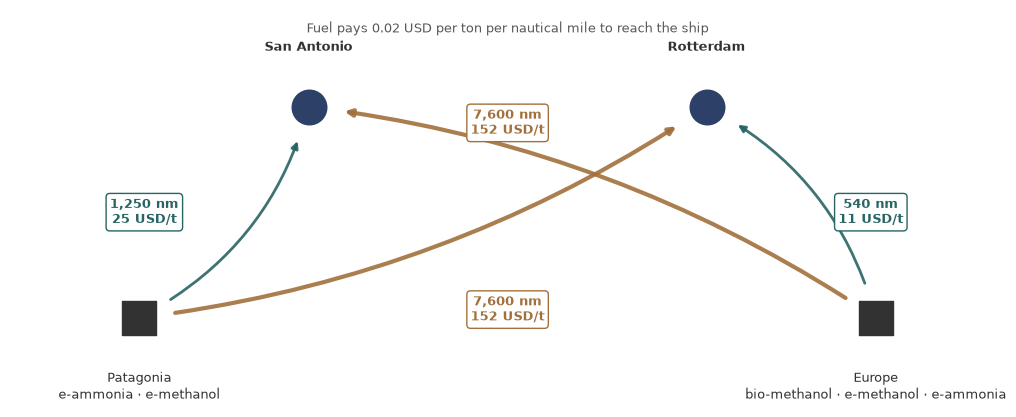

In [19]:
import re

text = (EXAMPLE / "includes" / "bunker_logistics.inc").read_text(encoding="utf-8")

# USD per ton per nautical mile (Navigate: `set_transport_cost`)
USD_PER_TON_NM = float(
    re.search(r'set_transport_cost\("\*",\s*([\d.]+)\)', text).group(1))

# One entry per journey the FUEL makes, plant region -> bunker port
# (Navigate: `set_distance`, from a Region to a Port). Navigate keeps the word
# "leg" for the ship's own route segments, so these are trips, not legs.
FUEL_DELIVERY_TRIPS = [(region, port, int(nm)) for region, port, nm in
                       re.findall(r'set_distance\("(\w+)",\s*"(\w+)",\s*(\d+)\)', text)]

# Drawn rather than tabulated: the point is the CONTRAST between fuel bunkered
# next door and fuel shipped to the far port, which a table makes you work out.
# Positions are schematic - this is the supply chain, not a projection.
POS = {"americas": (0.13, 0.24), "san_antonio": (0.30, 0.76),
       "europe": (0.87, 0.24), "rotterdam": (0.70, 0.76)}
CAPTION = {"americas": "Patagonia\ne-ammonia · e-methanol",
           "europe": "Europe\nbio-methanol · e-methanol · e-ammonia",
           "san_antonio": "San Antonio", "rotterdam": "Rotterdam"}
LOCAL = {("americas", "san_antonio"), ("europe", "rotterdam")}
# arc curvature, then where the label sits; keeps the two crossings legible
DRAW = {("americas", "san_antonio"): (0.22, 0.135, 0.50),
        ("europe", "rotterdam"): (0.22, 0.865, 0.50),
        ("americas", "rotterdam"): (0.12, 0.50, 0.26),
        ("europe", "san_antonio"): (0.12, 0.50, 0.72)}

fig, ax = plt.subplots(figsize=(10.5, 4.3))

for region, port, nm in FUEL_DELIVERY_TRIPS:
    rad, lx, ly = DRAW.get((region, port), (0.12, 0.5, 0.5))
    local = (region, port) in LOCAL
    colour = GREEN if local else ORANGE
    ax.annotate("", xy=POS[port], xytext=POS[region],
                arrowprops=dict(arrowstyle="-|>", color=colour,
                                lw=2.0 if local else 3.0, alpha=0.9,
                                connectionstyle=f"arc3,rad={rad}",
                                shrinkA=26, shrinkB=26))
    ax.text(lx, ly, f"{nm:,} nm\n{nm * USD_PER_TON_NM:.0f} USD/t",
            ha="center", va="center", fontsize=9, color=colour,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.30", fc="white", ec=colour, lw=1.0))

for name, (x, y) in POS.items():
    is_port = name in ("san_antonio", "rotterdam")
    ax.scatter([x], [y], s=620, marker="o" if is_port else "s",
               color=BLUE if is_port else INK, zorder=4)
    ax.text(x, y + (0.13 if is_port else -0.13), CAPTION[name], ha="center",
            va="bottom" if is_port else "top", fontsize=9.5, color=INK,
            fontweight="bold" if is_port else "normal")

ax.text(0.5, 0.97, f"Fuel pays {USD_PER_TON_NM} USD per ton per nautical mile "
                   f"to reach the ship", ha="center", va="top", fontsize=9,
        color=SUBINK)
ax.set_xlim(0, 1)
ax.set_ylim(0.02, 1.0)
ax.axis("off")
fig.tight_layout()
plt.show()


---

## 4. Data about the regulations

Four numbers govern how hard the two instruments press: the **allowance price**,
the **intensity target**, the **penalty** for missing that target, and **how
much of the voyage is counted** at all. The first two are Forecasts and are
plotted below; the third is a single `Variable`; the fourth was set back in
Part 1, as `Jurisdiction` and the three coverage fractions.

One structural fact is worth holding while reading them. The EU ETS is
`Scope = TTW`, so it zero-rates the combustion carbon of every alternative
fuel — e-ammonia, e-methanol and bio-methanol carry the same factors per ton,
leaving only their methane and nitrous oxide to charge. FuelEU is
`Scope = WTW`, so it can influence the choices between the different
alternative fuel supplies.


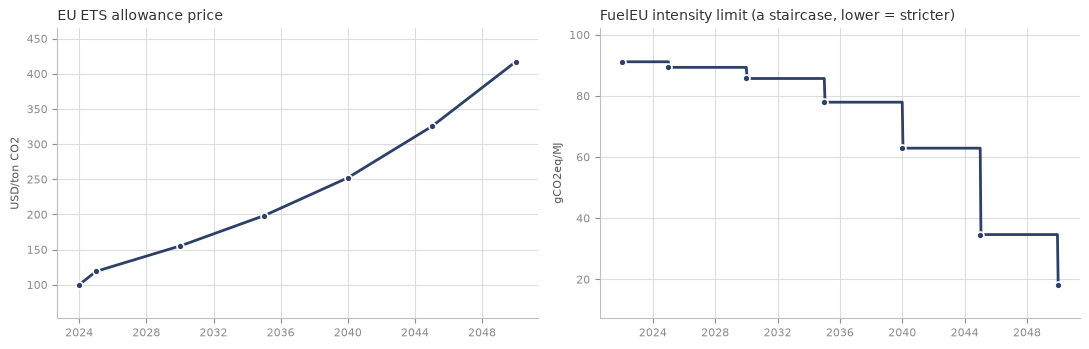

ETS allowance (USD/ton CO2)          100.0 (2024)  ->    417.0 (2050)
FuelEU limit (gCO2eq/MJ)              91.2 (2022)  ->     18.2 (2050)

FuelEU penalty for missing the cap   760.0 USD/ton, flat
EU ETS phase-in at the 2026 start     100% of emissions priced


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

panel(ax1, [("eu_ets_carbon_credit_price", None)],
      "EU ETS allowance price", "USD/ton CO2")
panel(ax2, [("fuel_eu_target_reduction", None)],
      "FuelEU intensity limit (a staircase, lower = stricter)", "gCO2eq/MJ")

fig.tight_layout()
plt.show()

for name, label in [("eu_ets_carbon_credit_price", "ETS allowance (USD/ton CO2)"),
                    ("fuel_eu_target_reduction", "FuelEU limit (gCO2eq/MJ)")]:
    df = forecast_to_frame(name)
    first, last = df.iloc[0], df.iloc[-1]
    print(f"{label:34} {first['value']:7.1f} ({first['date'].year})"
          f"  ->  {last['value']:7.1f} ({last['date'].year})")

# The lever that actually moves the answer is not a Forecast at all: a single
# number with no axis is a `Variable`, read with .get().
penalty = manager.nodes.variables["fuel_eu_remedial_cost"].get()
print(f"\n{'FuelEU penalty for missing the cap':34} {penalty:7.1f} USD/ton, flat")

# And the ETS is not phasing in over this run: it is complete on day one.
phase_in = forecast_to_frame("eu_ets_maritime_phase_in")
started = phase_in.loc[phase_in["date"].dt.year <= 2026, "value"].iloc[-1]
print(f"{'EU ETS phase-in at the 2026 start':34} {started:7.0%} of emissions priced")


The ETS price climbs steadily and the FuelEU limit hardly moves before 2035,
then falls away in steps. So the pressure arrives early as a price and late as
a cap. Breaching the cap leads to a **760 USD/ton penalty** which is the strongest single lever in the deck.

### What each regulation actually counts

The `Scope` (WTW or TTW) decides which part of the fuel chain is counted for taxation. The graph below shows what is counted for each regulation.

The two e-fuels have no WTT written in `fuel_eu.inc` on purpose: Navigate derives theirs from the production chain the deck defines since they have no regulatory default values.

The same fuel can also score a different **TTW** for FuelEU and EU ETS because each regulation carries its own emission factors.

**FuelEU is WTW**, so it charges the full combustion carbon of the molecule at the funnel. Bio-methanol is charged 72 gCO2eq/MJ TTW (the same as e-methanol, because burning either releases the same carbon). In case of biogenic carbon use, the WTT component is credited with a negative value. That is not a modelling shortcut: the regulation derives the WTT from the lifecycle value on the fuel's Proof of Sustainability, reduced by the combustion carbon.

**The EU ETS is TTW**. It zero-rates the combustion CO2 of bio- and e-fuels. So for bio-methanol the TTW is about 2 (for N2O and CH4 emissions).

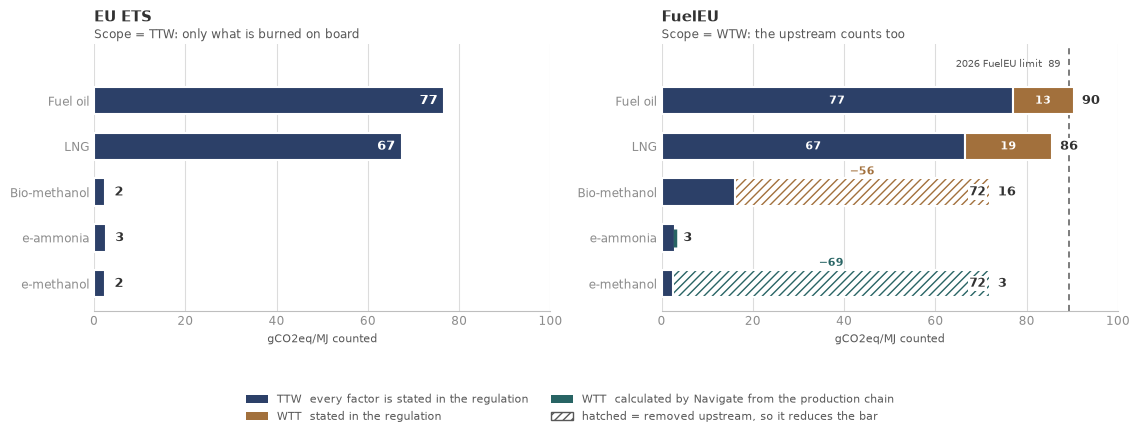

In [21]:
# What each regulation charges each fuel, and where each number comes from.
# The factors come from DECK_FACTORS, the copy Part 2's data-extraction cell took
# of the Regulation nodes before solving (`set_fuel_ttw` / `set_fuel_wtt` in eu_ets.inc and fuel_eu.inc).
# Where a regulation states no WTT of its own, Navigate derives one from the
# production chain instead, which is what the solved run supplies.
from navigate.illustrations.plots._labels import FUEL_LABEL, FUEL_ORDER

# Navigate's own display names and canonical fuel order, so this figure reads the
# same way as the plots the model generates. FUEL_ORDER covers every fuel the
# library knows about, so keep the five this deck actually defines.
ORDER = [f for f in FUEL_ORDER if f in manager.nodes.fuels]


def factor(node, t=0.):
    """An emission-factor node resolved to a number, or None where the deck leaves it open."""
    if node is None:
        return None
    if hasattr(node, "calculate"):
        return float(node.calculate(t))
    try:
        return float(node.get(t))      # expressions carry a Forecast, so they need a date
    except TypeError:
        return float(node.get())


def modelled_wtt(fuel_name, emission, idx=0):
    """The upstream emissions Navigate derives for a fuel from its production chain.

    The plant's own production emissions plus the delivery trip to the bunker port.
    Readable only because Part 2's data-extraction cell solved the deck -- none of this is written
    down in a .inc file. A fuel with no plant (the two fossils) has no chain, so
    there is nothing to derive.
    """
    for plant in manager.nodes.plants.values():
        if plant.fuel.get_name() != fuel_name:
            continue
        production = plant.expectation.get_production_WTT(emission, idx)
        delivery = max(plant.expectation.get_delivery_WTT(port, emission, idx)
                       for port in manager.nodes.ports)
        return production + delivery
    return None


def counted_intensity(regulation, fuel_name):
    """What `regulation` charges `fuel_name` as gCO2eq/MJ, and where the WTT came from.

    Returns (TTW, WTT, source). ton emission/ton fuel x GWP / (GJ/ton) x 1e3 -> g/MJ,
    using the regulation's OWN global warming potentials -- the two instruments do not
    use the same ones. `source` is "regulation" where the deck states a WTT factor and
    "navigate" where it states none and the production chain supplies it instead.
    """
    lhv = factor(manager.nodes.fuels[fuel_name].lower_heating_value)
    counts_wtt = str(regulation.scope).endswith("WTW")
    deck = DECK_FACTORS[regulation.get_name()]
    ttw, wtt, source = 0., 0., "regulation"
    for emission, gwp_node in deck["gwp"].items():
        gwp = factor(gwp_node)
        ttw_factor = factor(deck["ttw"].get((fuel_name, emission)))
        wtt_factor = factor(deck["wtt"].get((fuel_name, emission)))
        if wtt_factor is None and counts_wtt:
            wtt_factor, source = modelled_wtt(fuel_name, emission), "navigate"
        ttw += 0. if ttw_factor is None else ttw_factor * gwp / lhv * 1e3
        wtt += 0. if wtt_factor is None else wtt_factor * gwp / lhv * 1e3
    return ttw, wtt, source


from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True)
PANELS = [("eu_ets", "EU ETS", "Scope = TTW: only what is burned on board"),
          ("fuel_eu", "FuelEU", "Scope = WTW: the upstream counts too")]
LABEL_BOX = dict(boxstyle="square,pad=0.15", fc="white", ec="none")
LABEL_MIN = 10          # a bar narrower than this cannot hold a number

for ax, (reg_name, title, subtitle) in zip(axes, PANELS):
    reg = manager.nodes.regulations[reg_name]
    counts_wtt = str(reg.scope).endswith("WTW")

    for i, fuel in enumerate(ORDER):
        ttw, wtt, source = counted_intensity(reg, fuel)
        net = ttw + wtt if counts_wtt else ttw
        colour = ORANGE if source == "regulation" else GREEN

        ax.barh(i, ttw, height=.6, color=BLUE, zorder=3,
                edgecolor="white", linewidth=1.5)
        if counts_wtt and wtt > 0:
            ax.barh(i, wtt, left=ttw, height=.6, color=colour, zorder=3,
                    edgecolor="white", linewidth=1.5)
        elif counts_wtt and wtt < 0:
            # the regulation really does remove these emissions upstream, so the credit
            # is drawn eating into the TTW bar rather than extending it: what is left
            # solid is what actually counts
            # the hatch is drawn in the edge colour, so it goes on with no outline;
            # the white outline is added separately, matching the solid bars exactly,
            # so both end up the same visible thickness
            ax.barh(i, ttw - net, left=net, height=.6, facecolor="white", zorder=4,
                    edgecolor=colour, linewidth=0, hatch="////")
            ax.barh(i, ttw - net, left=net, height=.6, facecolor="none", zorder=4,
                    edgecolor="white", linewidth=1.5)
        elif counts_wtt:
            # a derived WTT that comes out at zero still has a provenance worth showing
            ax.plot([ttw], [i], marker="|", ms=13, mew=2.5, color=colour, zorder=5)

        # A single-part row (the EU ETS panel) carries one number: inside the bar,
        # or just outside it when the bar is too narrow to hold it.
        if not counts_wtt:
            if ttw >= LABEL_MIN:
                ax.annotate(f"{ttw:.0f}", (ttw - 1.5, i), ha="right", va="center",
                            fontsize=9, color="white", fontweight="bold", zorder=6)
            else:
                ax.annotate(f"{ttw:.0f}", (ttw + 2, i), va="center", fontsize=9,
                            color=INK, fontweight="bold", zorder=6)
        else:
            # Read the same way as the fuel-and-compliance bills: every part that
            # shows at the printed precision carries its number, a removed part
            # with its minus sign on top of its hatching, and the total after the
            # bar is the sum of what is printed, so the row adds up as printed.
            shown_ttw, shown_wtt = round(ttw), round(wtt)
            if shown_wtt < 0:
                # the TTW number sits at the end of the TTW extent, which on a
                # credited row is the far edge of the hatching
                ax.annotate(f"{shown_ttw}", (ttw, i), xytext=(-3, 0),
                            textcoords="offset points", ha="right", va="center",
                            fontsize=8.5, fontweight="bold", zorder=6, color=INK,
                            bbox=LABEL_BOX)
                ax.annotate(f"\u2212{-shown_wtt}", ((net + ttw) / 2, i - .3),
                            xytext=(0, 1), textcoords="offset points", ha="center",
                            va="bottom", fontsize=8, color=colour,
                            fontweight="bold", zorder=6)
            elif shown_wtt > 0:
                for value, start in ((ttw, 0.), (wtt, ttw)):
                    if value >= LABEL_MIN:
                        ax.annotate(f"{round(value)}", (start + value / 2, i),
                                    ha="center", va="center", fontsize=8,
                                    color="white", fontweight="bold", zorder=6)
                    else:
                        # too narrow to hold its number: just above the bar
                        ax.annotate(f"{round(value)}", (start + value / 2, i - .3),
                                    xytext=(0, 1), textcoords="offset points",
                                    ha="center", va="bottom", fontsize=7.5,
                                    color=INK, zorder=6)
            # with a single part, the total is its number
            ax.annotate(f"{shown_ttw + shown_wtt}", (max(ttw, net), i), xytext=(6, 0),
                        textcoords="offset points", va="center", fontsize=9,
                        color=INK, fontweight="bold", zorder=6, bbox=LABEL_BOX)

    if counts_wtt:
        limit = factor(manager.nodes.forecasts["fuel_eu_target_reduction"])
        ax.axvline(limit, color=SUBINK, lw=1.1, ls=(0, (4, 3)), zorder=2)
        ax.annotate(f"2026 FuelEU limit  {limit:.0f}", (limit - 2, -.8),
                    fontsize=7.5, color=SUBINK, ha="right", va="center")

    ax.set_title(title, fontsize=11, color=INK, loc="left", pad=16, fontweight="bold")
    ax.annotate(subtitle, (0, 1.02), xycoords="axes fraction", fontsize=8.5, color=SUBINK)
    ax.set_xlabel("gCO2eq/MJ counted", fontsize=8, color=SUBINK)
    ax.set_xlim(0, 100)
    ax.set_ylim(len(ORDER) - .4, -1.25)
    ax.set_yticks(range(len(ORDER)), [FUEL_LABEL[f] for f in ORDER])
    ax.grid(axis="x", color=GRID, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8.5, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)

fig.legend(handles=[Patch(facecolor=BLUE, label="TTW  every factor is stated in the regulation"),
                    Patch(facecolor=ORANGE, label="WTT  stated in the regulation"),
                    Patch(facecolor=GREEN, label="WTT  calculated by Navigate from the production chain"),
                    Patch(facecolor="white", edgecolor=SUBINK, hatch="////",
                          label="hatched = removed upstream, so it reduces the bar")],
           fontsize=8, frameon=False, labelcolor=SUBINK, ncol=2,
           loc="lower center", bbox_to_anchor=(.5, .005))
fig.tight_layout(rect=(0, .17, 1, 1))
plt.show()


When reading across the two panels you can see that, for bio-methanol, EU ETS gives 2 gCO2e/MJ of TTW emissions and FuelEU 16 gCO2e/MJ. The gap between those totals is bio-methanol's own production footprint: about 14 gCO2eq/MJ of growing, gasifying and shipping the biomass. FuelEU counts it; the ETS never looks upstream, so it cannot see it. The ETS therefore scores bio-methanol some 97 % better than fuel oil where FuelEU says 82 %.

---

# Part 3: Understand the logic behind the model

The idea of Navigate is to mimic the decision behavior of fleet owners and operators and fuel plant owners to understand how the fleet transition may evolve under a given set of conditions.

The aim of this section is to go "inside Navigate's mind" and understand how the model solving actually works, step by step.

## How Navigate decides

Navigate gives a solution one year at a time.
The solving process is the same for each year and each decision maker in the model:

1. **look ahead**: make projections about the future
2. **decide**: make some fancy calculations based on your projections and take some decisions on what you think is best for your business
3. **commit**: you bought your ship or your fuel plant and other actors reacted, now you have to operate it and "reality" may differ from your expectations.

In more detail, the model starts the year by calculating expectations and beliefs about the future from the
information available — among them a look-ahead bunkering optimization, which prices the year before
anything is decided. Those expectations then inform the decisions of the fleet owner (and operator), in this order:

- efficiency measures: implement (or not) efficiency technology, on existing ships when they reach
  their five-yearly retrofit cycle and on any ship ordered new
- operational measures: change the vessels' sailing speed (while minimizing total cost per cargo-mile)
- fleet management: scrap, retrofit or order new ships
- fuel bunkering: which fuel to buy at which port for this year

The bunkering optimisation therefore runs twice: once as a forecast that informs the four
decisions, and once at the end of the year to commit.

What drives the decision making of the fleet owner is mostly economic considerations, supplemented by some behavioral traits. For fuel choice the operator leans towards the cheapest option but is
not blind to the others: `InterFuelSensitivity` sets how sharply a cost gap between fuel types (e.g. ammonia or LNG) turns into a change of mind, and `IntraFuelSensitivity` does the same between ship designs that burn the same fuel type (this deck has only one design per fuel type, so that second axis does not decide anything here). In other words, in Navigate, there is no "absolute winner": each option gets a **share**, larger when it is cheaper, and the sensitivities (~behavioral traits) in the deck set how sharply a cost gap
turns into a share. With 300 ships those shares read as ships — "12 % e-ammonia" is about
thirty-six hulls.

The fuel producer decides last, in the same year, basing its decision on the expected fuel demand from the shipping sector: if that demand exceeds the supply it has already built or ordered, the plant owner takes its share of the gap and turns that into fuel plants. Here too there is no "absolute winner", only shares.

Now, run the next cell that solves the model and "extracts" some information along the solving process that we can observe and analyze.


In [22]:
def run_case(tweak=None, probe_fn=None, quiet=True):
    """Parse the deck, optionally modify it, solve it, return the manager.

    With `probe_fn`, `SimulationManager._perform_time_step` is wrapped for the
    duration of the run and `probe_fn(m, idx)` is called at the end of every
    time step, so the actors' beliefs can be copied out before the next step
    overwrites them. The patch is on the class and is always put back.

    Returns `(manager, snapshots)` when probing, the manager alone otherwise.
    """
    m = SimulationManager()
    snaps = {}
    original = SimulationManager._perform_time_step

    # The expected fuel mix cannot be read after the fact: BunkerAlgorithm.transfer()
    # resets the accumulator on EVERY forward solve, so by the end of a step it holds
    # one year. Wrapping transfer is the only way to add the forward years up while
    # they exist. Only the EXPECTED scope is collected - the binding solve is Stage 4's.
    original_transfer = BunkerAlgorithm.transfer
    expected_mix, expected_first, outer = {}, {}, {"idx": 0, "call": 0}

    # The technology NPV is computed inside perform_technology_installation and
    # thrown away once the shares are drawn, so the only way to see the number the
    # decision was actually made on is to record it as it is produced. One call per
    # vessel per step, in fleet.assets order.
    # The NPV function is defined in navigate/vessel/package.py;
    # fleet_technology imports it and calls it unqualified, so the name
    # it calls is the one that has to be patched.
    original_npv = fleet_technology.npv_for_newbuilds
    npv_log = {}

    def wrapped_npv(packages_saving, packages, discount_rate):
        out = original_npv(packages_saving, packages, discount_rate)
        npv_log.setdefault(outer["idx"], []).append(np.asarray(out, dtype=float).copy())
        return out

    # The delivered-cost split is computed and thrown away: calculate_modelled_uptake
    # returns a share per plant and only the resulting plant COUNT is kept, so which
    # site the producer chose cannot be read back afterwards.
    original_uptake = producer_planning.calculate_modelled_uptake
    uptake_log = {}

    def wrapped_uptake(producer):
        out = original_uptake(producer)
        uptake_log.setdefault(outer["idx"], []).append(
            (producer.get_name(), [a.get_name() for a in producer.assets],
             np.asarray(out, dtype=float).copy()))
        return out

    # The belief keeps compliance as ONE untagged number: remedial, pooling and
    # surplus all land in the same `_policy_expenses` array, and it is wiped at
    # the top of every look-ahead. Booking each contribution as it is made, and
    # clearing the book on the same reset the model uses, is the only way to
    # split the expected bill the way Stage 4 splits the committed one.
    original_add = VesselExpectation.add_policy_expenses
    original_add_path = VesselExpectation.add_policy_expenses_path
    original_reset = VesselExpectation.reset_expected_bunkering
    policy_book = {}

    def _book(idx, value, caller):
        """Credit one contribution to the scheme and ship settling it.

        The regulation name is not passed to add_policy_expenses, so the only
        place it still exists is the caller's own locals. The frame is handed in
        rather than counted back to, so adding a wrapper cannot silently break it.
        """
        local = caller.f_locals
        name = local.get("r")
        if name is None and "regulation" in local:
            name = local["regulation"].get_name()
        vessel = local.get("v") or local.get("vessel_name")
        if name and vessel:
            key = (idx, vessel, name)
            policy_book[key] = policy_book.get(key, 0.) + float(value)

    def wrapped_add(self, idx, expenses):
        _book(idx, expenses, sys._getframe(1))
        return original_add(self, idx, expenses)

    def wrapped_add_path(self, idx, expenses):
        caller = sys._getframe(1)
        for offset, value in enumerate(np.atleast_1d(np.asarray(expenses, dtype=float))):
            _book(idx + offset, value, caller)
        return original_add_path(self, idx, expenses)

    def wrapped_reset(self):
        # every vessel is reset in one loop before the look-ahead runs, so
        # clearing the whole book on any one of them is correct and simpler
        policy_book.clear()
        return original_reset(self)

    def wrapped_transfer(alg):
        original_transfer(alg)
        if alg.scope is not BunkerScopeID.EXPECTED:
            return
        outer["call"] += 1
        store = expected_mix.setdefault(outer["idx"], {})
        # call 1 is this step's own year; the rest are the years beyond it
        first = expected_first.setdefault(outer["idx"], {}) if outer["call"] == 1 else None
        for vessel_name, vessel in alg.vessels.items():
            for port_name in alg.ports:
                for fuel_name in alg.fuels:
                    tons = vessel.expectation.get_bunker_mass_expected(port_name, fuel_name)
                    if tons > 0.:
                        key = (vessel_name, port_name, fuel_name)
                        store[key] = store.get(key, 0.) + tons
                        if first is not None:
                            first[key] = first.get(key, 0.) + tons

    def wrapped(self):
        outer["idx"] = self._idx              # so transfer knows which step it is in
        outer["call"] = 0                     # and which forward year within it
        original(self)                        # let the model do its work
        snap = probe_fn(self, self._idx)
        snap["expected_mix"] = expected_mix.pop(self._idx, {})
        snap["expected_mix_first"] = expected_first.pop(self._idx, {})
        snap["npv_newbuild"] = npv_log.pop(self._idx, [])
        snap["producer_uptake"] = uptake_log.pop(self._idx, [])
        # the book is cleared by the next look-ahead, so copy it out now, exactly
        # as the beliefs above are copied out - the whole forward path, not just
        # this year: Stage 4's panel reads year one out of it and the
        # summed-to-2050 panel reads all of it
        snap["expected_policy"] = {
            (v, r): np.array([policy_book.get((k, v, r), 0.)
                              for k in range(self._idx, self._timeline.size)])
            for v in self.nodes.vessels for r in self.nodes.regulations}
        snaps[self._idx] = snap

    if probe_fn is not None:
        SimulationManager._perform_time_step = wrapped
        BunkerAlgorithm.transfer = wrapped_transfer
        fleet_technology.npv_for_newbuilds = wrapped_npv
        producer_planning.calculate_modelled_uptake = wrapped_uptake
        VesselExpectation.add_policy_expenses = wrapped_add
        VesselExpectation.add_policy_expenses_path = wrapped_add_path
        VesselExpectation.reset_expected_bunkering = wrapped_reset
    ctx = contextlib.redirect_stdout(io.StringIO()) if quiet else contextlib.nullcontext()
    try:
        with ctx:
            m.read_deck(NAV, ARGS)
            if tweak is not None:
                tweak(m)
            m.run()
    finally:
        if probe_fn is not None:              # only undo what we did
            SimulationManager._perform_time_step = original
            BunkerAlgorithm.transfer = original_transfer
            fleet_technology.npv_for_newbuilds = original_npv
            producer_planning.calculate_modelled_uptake = original_uptake
            VesselExpectation.add_policy_expenses = original_add
            VesselExpectation.add_policy_expenses_path = original_add_path
            VesselExpectation.reset_expected_bunkering = original_reset

    return (m, snaps) if probe_fn is not None else m


def years_of(m):
    return m.get_dateline().astype("datetime64[Y]").astype(int) + 1970


def fuel_frame(m):
    """Energy consumed per fuel per year, GJ."""
    fleet = m.nodes.fleets["copper_trade"]
    consumed = fleet.profile.get_consumed_energy()
    df = pd.DataFrame({k: v for k, v in consumed.items() if np.nansum(v) > 0},
                      index=years_of(m))
    return df.loc[:, df.sum().sort_values(ascending=False).index]


def probe(m, idx):
    """Everything the actors are 'thinking' at the end of time step idx.

    `expectation` is overwritten every time step, so a belief has to be copied
    out while it is still the one that step's decisions were taken on. `profile`
    persists and is read back later with an `idx`.
    """
    forward = np.s_[idx:]
    snap = {"operator": {}, "producer": {}, "regulation": {},
            "cohorts": [], "bunkered": {}, "fuel_demand": {}}

    # the operator: its forward view of what each configuration would cost
    for name, vessel in m.nodes.vessels.items():
        e = vessel.expectation
        snap["operator"][name] = {
            "expense_path": np.array(e.get_total_fuel_expenses(forward), dtype=float),
            # the same path split in two. get_total_fuel_expenses() returns their sum,
            # and only the private arrays keep them apart.
            "fuel_path": np.array(e._fuel_expenses[forward], dtype=float),
            "policy_path": np.array(e._policy_expenses[forward], dtype=float),
        }
        # this year's bunkering plan, tons per ship, per port and fuel. Reset at
        # the start of each existing-scope transfer, so it is unambiguously this
        # step's plan rather than a running total.
        for port in m.nodes.ports:
            for fuel in m.nodes.fuels:
                tons = float(e.get_bunker_mass_existing(port, fuel))
                if tons > 0:
                    snap["bunkered"][(name, port, fuel)] = tons

    # the fleet as cohorts. The profile keeps no history of increments, so the
    # only way to see a past year's age structure is to copy it out here.
    fleet = m.nodes.fleets["copper_trade"]
    for vessel, increments in zip(fleet.get_vessels(), fleet.get_multiplier_increments()):
        for inc in increments:
            snap["cohorts"].append((vessel.get_name(), inc.age, inc.multiplier))

    # the ladder the technology choice climbs, and whose NPV is whose
    snap["asset_order"] = [a.get_name() for a in fleet.assets]
    snap["ladder"] = [(sum(float(t.CAPEX.get()) for t in pkg.technologies),
                       pkg.technologies[-1].get_name().replace("_bulk_carrier_panamax", "")
                       if pkg.technologies else "nothing fitted")
                      for pkg in fleet.technology_packages]

    # the demand vector the producer reads -- computed earlier in THIS step,
    # before this year's newbuild and retrofit decisions. That lag is the point.
    snap["fuel_demand"] = {k: np.array(v, dtype=float)
                           for k, v in fleet.expectation.get_fuel_demand(forward).items()}

    # the producer: the two axes it chooses on
    for producer_name, producer in m.nodes.producers.items():
        # the demand the PRODUCER acts on - its fair share, in tons per year. This
        # is the series demand_newbuilds is read off, so it is the only one a
        # sizing marker can honestly be drawn against. The fleet's own fuel demand
        # above is a different quantity and does not line up with it.
        fair = producer.expectation.get_fair_share_demand()
        for plant in producer.get_plants():
            pe = plant.expectation
            snap["producer"][plant.get_name()] = {
                "producer": producer_name,
                "delivered_cost": float(pe.get_intra_fuel_metric()),
                "expected_demand": float(pe.get_inter_fuel_metric()),
                "plants_justified": float(pe.get_demand_newbuilds()),
                # one plant's own yearly output. demand_newbuilds is demand
                # divided by exactly this, so multiplying back gives the
                # production those plants would add - in mass, then energy.
                "plant_output": float(pe.get_production(idx)),
                "lhv": float(plant.fuel.lower_heating_value.get()),
                # how many plants this producer is allowed to START in a year.
                # Without it there is no way to see whether the ceiling bound.
                "max_development": float(producer.maximum_development.get()),
                # years from sanction to first production. The demand this plant
                # is sized against is the demand in the year it COMES ONLINE, not
                # the year the decision is taken - see get_plant_evaluation_timeline.
                "lead_time": float(plant.lead_time.get()),
                # tons/yr -> TJ/yr, so it can be drawn against gap_at_startup
                "demand_path": (np.nan_to_num(np.asarray(
                    fair[plant.fuel.get_name()], dtype=float))
                    * float(plant.fuel.lower_heating_value.get())) / 1e3,
            }

    # the regulator: the believed unit cost, and the limit it holds ships to
    for name, regulation in m.nodes.regulations.items():
        snap["regulation"][name] = {
            "unit_cost": float(regulation.expectation.get_remedial_cost(idx)),
            "limit": float(np.nan_to_num(regulation.profile.get_shared_threshold(idx))),
        }

    return snap


# ONE solve, with the probe installed. `base` is the model Part 4 re-runs with
# tweaks; `snaps` is what the actors believed at each step on the way.
%time base, snaps = run_case(probe_fn=probe)

YEARS = years_of(base)
STEPS = sorted(snaps)
CONFIGS = ["ship_oil", "ship_lng", "ship_methanol", "ship_ammonia"]

copper_trade = base.nodes.fleets["copper_trade"]   # one binding for the fleet node

print(f"captured {len(snaps)} snapshots, {YEARS[0]} to {YEARS[-1]}")

# The two years this Part walks. 2027 is the first year that decides anything at
# all - step 0 takes no decisions, since _perform_time_step gates every decision
# behind `if self._idx > 0` - so it shows the fleet as it starts out. 2040 is far
# enough on that the conditions have changed in several ways at once.
FOCUS_YEARS = (2027, 2040)
STEP_EARLY, STEP_LATE = (int(np.flatnonzero(YEARS == y)[0]) for y in FOCUS_YEARS)


def at(getter, step):
    """One step of a per-vessel (or per-pair) profile series, keyed as stored."""
    value = getter(idx=step)
    if isinstance(value, dict):
        return {k: float(np.nan_to_num(np.asarray(v, dtype=float)))
                for k, v in value.items()}
    return float(np.nan_to_num(np.asarray(value, dtype=float)))


def total_at(getter, step):
    value = at(getter, step)
    return sum(value.values()) if isinstance(value, dict) else value


print(f"walking {FOCUS_YEARS[0]} (step {STEP_EARLY}) "
      f"and {FOCUS_YEARS[1]} (step {STEP_LATE})")


CPU times: total: 14.8 s
Wall time: 15.6 s
captured 25 snapshots, 2026 to 2050
walking 2027 (step 1) and 2040 (step 14)


---

## One time step, from the inside: 2027

### Stage 0 — Initialization

A time step starts with an initialization. It inherits a fleet with an age
structure, plants that were sanctioned years ago, and two regulations whose
terms for this year are already fixed.


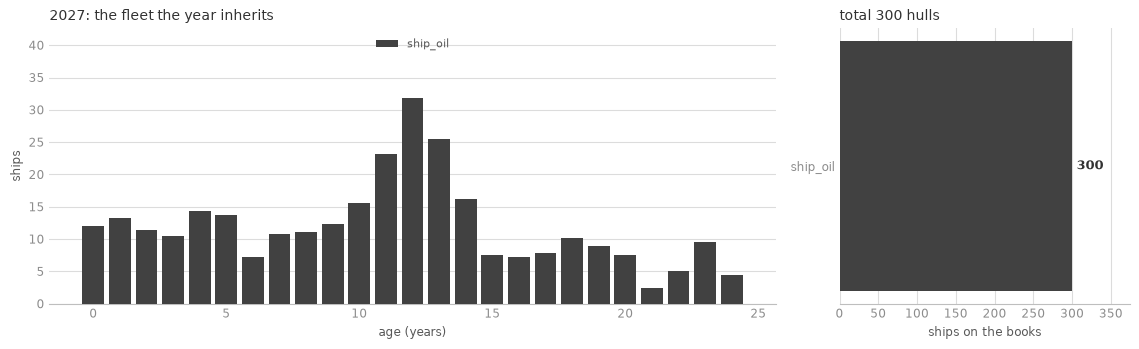

25 live cohorts: decisions are taken per cohort, against that cohort's own remaining life.

this year's regulatory terms:
  eu_ets    unit cost   133.4 USD/ton   limit: no free allowance
  fuel_eu   unit cost   760.0 USD/ton   limit: 89.34 gCO2eq/MJ


In [23]:
# What the year inherits, as two pictures rather than a list. Drawn by a function
# taking a step, so the 2040 section can put the same picture beside this one.

from navigate.illustrations.plots._labels import FUEL_TYPE_ORDER

snap = snaps[STEP_EARLY]          # the year this Part walks


def inherited_cohorts(step):
    """Ships per (age, configuration) that a step OPENS with.

    The probe copies the cohorts out at the END of a step, so snaps[step] would
    already include the ships ordered during the year, which is the opposite of
    what Stage 0 is about. The previous step's snapshot is what it inherits.
    """
    frame = pd.DataFrame(snaps[step - 1]["cohorts"],
                         columns=["configuration", "age", "ships"])
    return frame.pivot_table(index="age", columns="configuration", values="ships",
                             aggfunc="sum", fill_value=0.)


def draw_inherited(step, axes, scale_over=None, legend=True):
    """Stage 0 for one year, into a pair of axes.

    `scale_over` names the steps whose data set the axis limits. Left alone, a
    year scales to itself; the 2040 comparison passes both years so the two rows
    can be read against each other instead of each filling its own panel.
    """
    ax1, ax2 = axes
    steps = tuple(scale_over) if scale_over else (step,)
    by_age = inherited_cohorts(step)

    # stack in Navigate's canonical fuel-type order, restricted to what this deck flies
    stack = sorted(by_age.columns,
                   key=lambda n: FUEL_TYPE_ORDER.index(base.nodes.vessels[n].fuel_type))
    colour = {n: config_colour(n) for n in stack}

    # left: the age structure. Every bar is a cohort the model decides for separately,
    # against that cohort's own remaining life.
    bottom = np.zeros(len(by_age))
    for name in stack:
        values = by_age[name].to_numpy()
        ax1.bar(by_age.index, values, bottom=bottom, width=.82, color=colour[name],
                label=config_label(name), zorder=3)
        bottom += values

    ax1.set_xlabel("age (years)", fontsize=8.5, color=SUBINK)
    ax1.set_ylabel("ships", fontsize=8.5, color=SUBINK)
    ax1.set_title(f"{YEARS[step]}: the fleet the year inherits", fontsize=10,
                  color=INK, loc="left")
    ax1.grid(axis="y", color=GRID, lw=.8)
    # headroom so the legend clears the tallest cohort
    ax1.set_ylim(0, max(inherited_cohorts(s).sum(axis=1).max()
                        for s in steps) * 1.34)
    if legend:
        ax1.legend(fontsize=8, frameon=False, labelcolor=SUBINK, ncol=4,
                   loc="upper center")

    # right: what it adds up to. The numbers are on the bars because two of these
    # colours sit close together for red-green colour blindness.
    totals = by_age[stack].sum()
    ax2.barh(range(len(stack)), totals.to_numpy(), height=.6,
             color=[colour[n] for n in stack], zorder=3)
    for i, name in enumerate(stack):
        ax2.annotate(f"{totals[name]:.0f}", (totals[name] + 6, i), va="center",
                     fontsize=9, color=INK, fontweight="bold")

    ax2.set_yticks(range(len(stack)), [config_label(n) for n in stack])
    ax2.set_xlabel("ships on the books", fontsize=8.5, color=SUBINK)
    ax2.set_title(f"total {totals.sum():.0f} hulls", fontsize=10, color=INK, loc="left")
    ax2.set_xlim(0, max(inherited_cohorts(s).sum().max() for s in steps) * 1.25)
    ax2.invert_yaxis()
    ax2.grid(axis="x", color=GRID, lw=.8)

    for ax in (ax1, ax2):
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8.5, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)


fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6),
                         gridspec_kw={"width_ratios": [2.5, 1]})
draw_inherited(STEP_EARLY, axes)
fig.tight_layout()
plt.show()

print(f"{len(snaps[STEP_EARLY - 1]['cohorts'])} live cohorts: decisions are taken "
      f"per cohort, against that cohort's own remaining life.\n")

# two numbers per regulation is not a picture, so these stay as they are
print("this year's regulatory terms:")
for name, reg in snap["regulation"].items():
    limit = "no free allowance" if reg["limit"] == 0 else f"{reg['limit']:.2f} gCO2eq/MJ"
    print(f"  {name:9} unit cost {reg['unit_cost']:7.1f} USD/ton   limit: {limit}")


### Stage 1 — Look ahead

In this step, the fleet operator calculates the costs of different bunkering strategies for the different available fuels given:
- the expected future compliance costs (induced by regulations)
- the expected fuel costs
- how much of each fuel the ports can supply, and how much fits in the tanks

The fleet operator calculates the expected optimal strategy for his fleet and evaluates: how many tons of which fuel to buy at which port, the cheapest strategy between switching fuel or paying the regulation penalty. It is solved for the whole fleet at once — in fact for every fleet in the simulation — so the ships compete for the same supply. The expenses of new build ships, retrofits, etc. are not considered at this stage yet.

The cheapest bunkering strategy is solved **forward**: one optimisation for each remaining year out to 2050, run one after another.

The step hands a cost path per option to the stages below, and that is what the investment decisions are made on. It produces a second output as well: the **fuel scarcity signal**. For every ship and every leg the optimisation reports the shadow price of energy (what one more unit of energy would have cost). It is the ordinary fuel price when fuel is plentiful and rises above it when the supply is tight. This number is used to act on efficiency and speed decisions for the on-going year.

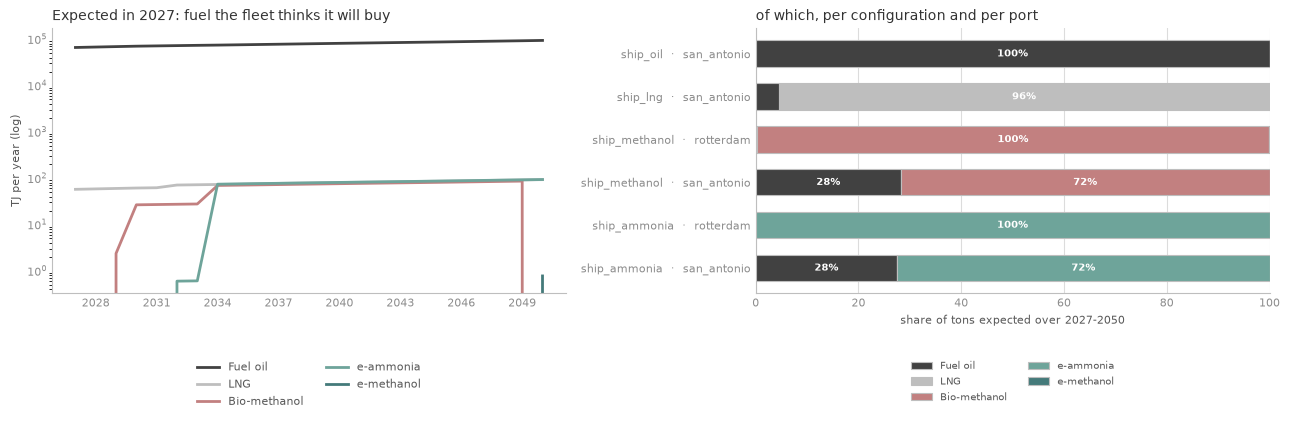

  ship_oil        expects  100% of its tons to be oil
  ship_lng        expects    4% of its tons to be oil
  ship_methanol   expects   18% of its tons to be oil
  ship_ammonia    expects   18% of its tons to be oil


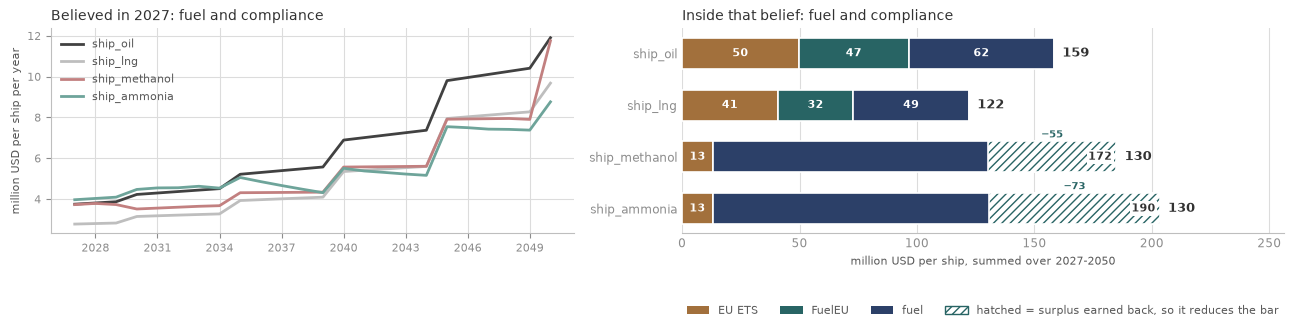

believed cost of missing the mark, this year:
  eu_ets      133.4 USD/ton
  fuel_eu     760.0 USD/ton

Nothing has been decided yet. This is only what the model believes.


In [24]:
from matplotlib.patches import Patch

from navigate.illustrations.plots._labels import FUEL_ORDER
from matplotlib.ticker import MaxNLocator


def label_bill(ax, slices, credit, digits):
    """Print a bill row's numbers so that, as printed, they add up.

    `slices` are (values, starts) pairs in drawing order. Every part that shows
    at `digits` gets its number, the surplus too, and the total after the bar is
    the sum of what is printed: along a row, the parts minus the surplus give
    the total. A part running under the hatching carries its number at the end
    of its extent, as TTW does in the regulation figure; a part too narrow to
    hold its number carries it just above the bar. The surplus's number always
    sits above its hatching, with its minus sign: inside, it would cover the
    fuel number wherever the hatching is narrow.
    """
    fmt = f"{{:.{digits}f}}"
    gross = sum(v for v, _s in slices)
    narrow = .06 * (float(np.max(gross)) or 1.)
    for i in range(len(gross)):
        net = gross[i] - credit[i]
        shown = 0.
        for values, starts in slices:
            v, s = float(values[i]), float(starts[i])
            printed = round(v, digits)
            if printed == 0:
                continue
            shown += printed
            if s + v > net + 1e-9:
                ax.annotate(fmt.format(printed), (s + v, i), xytext=(-3, 0),
                            textcoords="offset points", ha="right", va="center",
                            fontsize=8, fontweight="bold", zorder=6, color=INK,
                            bbox=LABEL_BOX)
            elif v >= narrow:
                ax.annotate(fmt.format(printed), (s + v / 2, i), ha="center",
                            va="center", fontsize=8, fontweight="bold", zorder=5,
                            color="white")
            else:
                ax.annotate(fmt.format(printed), (s + v / 2, i - .3), xytext=(0, 1),
                            textcoords="offset points", ha="center", va="bottom",
                            fontsize=7, color=INK, zorder=6)
        back = round(float(credit[i]), digits)
        if back > 0:
            shown -= back
            ax.annotate("−" + fmt.format(back), (net + credit[i] / 2, i - .3),
                        xytext=(0, 1), textcoords="offset points", ha="center",
                        va="bottom", fontsize=7.5, color=cost_colour("FuelEU"),
                        fontweight="bold", zorder=6)
        ax.annotate(fmt.format(shown), (gross[i], i), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=9,
                    color=INK, fontweight="bold")


# What is inside each of those cost paths. Summed over the remaining years, so one bar is
# everything a ship of that configuration expects to pay for energy and compliance between
# now and 2050. Compliance can come out NEGATIVE: an over-complying ship sells its surplus
# units into FuelEU's pool, and the revenue is booked against the same line.
def plot_believed_bill(step, ax):
    """The believed bill to 2050, split the same four ways as Stage 4.

    Draws into `ax`, beside the cost paths here and in the 2040 comparison.

    The same parts as the committed panel, summed over the remaining years rather
    than taken for one of them. As there, the belief carries no GROSS surplus: a
    scheme the ship expects to be a net seller under comes out negative, and that
    is what is drawn as the credit.
    """

    snapshot = snaps[step]
    if "fuel_path" not in snapshot["operator"][CONFIGS[0]]:
        raise RuntimeError(
            "These snapshots were captured before the fuel/compliance split existed. "
            "Re-run the run_case cell above, then this one.")
    if "expected_policy" not in snapshot:
        raise RuntimeError(
            "These snapshots predate the per-scheme expected split. Re-run the "
            "run_case cell above, then this one.")

    REG_LABEL = {"eu_ets": "EU ETS", "fuel_eu": "FuelEU"}

    rows = {}
    for name in CONFIGS:
        part, credit = {}, 0.
        for reg_name in base.nodes.regulations:
            owed = float(np.nansum(snapshot["expected_policy"][(name, reg_name)])) / 1e6
            part[REG_LABEL.get(reg_name, reg_name)] = max(owed, 0.)
            credit += max(-owed, 0.)
        rows[name] = {"fuel": float(np.nansum(
            snapshot["operator"][name]["fuel_path"])) / 1e6, **part, "credit": credit}
        # the parts must still add up to the belief the decision was taken on
        assert abs(sum(part.values()) - credit - float(np.nansum(
            snapshot["operator"][name]["policy_path"])) / 1e6) < 1e-3

    y = range(len(CONFIGS))

    # Read the way the TTW/WTW figure reads. The surplus is a credit: drawn white
    # and hatched in the colour of the scheme that pays it (FuelEU), eating back
    # into the bar, so what stays solid is what the ship pays. Fuel goes last, so
    # the credit only ever eats into that one slice, as the WTT credit eats into
    # TTW there. label_bill() prints the numbers so that each row adds up.
    credit = np.array([rows[n]["credit"] for n in CONFIGS])

    left = np.zeros(len(CONFIGS))
    slices = []
    for part_name in ("EU ETS", "FuelEU", "fuel"):
        values = np.array([rows[n][part_name] for n in CONFIGS])
        ax.barh(list(y), values, left=left, height=.6, color=cost_colour(part_name),
                zorder=3, edgecolor="white", linewidth=1.2, label=part_name)
        slices.append((values, left.copy()))
        left += values
    ax.barh(list(y), -credit, left=left, height=.6, facecolor="white",
            hatch="////", edgecolor=cost_colour("FuelEU"), linewidth=0, zorder=4,
            label="hatched = surplus earned back, so it reduces the bar")
    ax.barh(list(y), -credit, left=left, height=.6, facecolor="none",
            edgecolor="white", linewidth=1.2, zorder=4)
    label_bill(ax, slices, credit, digits=0)

    ax.set_yticks(list(y), CONFIGS)
    ax.invert_yaxis()
    ax.set_xlim(0, left.max() * 1.26)
    ax.set_xlabel(f"million USD per ship, summed over {YEARS[step]}-{YEARS[-1]}",
                  fontsize=8, color=SUBINK)
    ax.set_title("Inside that belief: fuel and compliance",
                 fontsize=10, color=INK, loc="left")
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8.5, length=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.legend(handles=[Patch(facecolor=cost_colour("EU ETS"), label="EU ETS"),
                       Patch(facecolor=cost_colour("FuelEU"), label="FuelEU"),
                       Patch(facecolor=cost_colour("fuel"), label="fuel"),
                       Patch(facecolor="white", edgecolor=cost_colour("FuelEU"),
                             hatch="////", label="hatched = surplus earned back, so it reduces the bar")],
              fontsize=8, frameon=False, labelcolor=SUBINK, ncol=4,
              loc="upper center", bbox_to_anchor=(0.5, -0.30))


# The other half of the look-ahead: not what it will cost, but what it expects to buy.
# Left: the fleet's expected demand per fuel for every remaining year, on a log axis
# because oil outweighs the rest by three orders of magnitude. Right: the same belief
# per configuration, as a share - what each hull thinks it will actually burn between
# now and 2050. Both come from the snapshot, so neither knows how the run turned out.
def expected_demand(step):
    """What the fleet expects to buy per fuel, TJ per year, for the years ahead.

    get_fuel_demand() is a MASS in tons, so energy needs each fuel's own heating
    value rather than one divisor - oil carries 41.2 GJ/t against ammonia's 18.8,
    and dividing them alike would rank them wrongly.
    """
    believed = snaps[step]["fuel_demand"]
    lhv = {f: float(base.nodes.fuels[f].lower_heating_value.get()) for f in believed}
    return pd.DataFrame(
        {f: np.asarray(v, dtype=float) * lhv[f] / 1e3       # tons -> GJ -> TJ
         for f, v in believed.items()},
        index=YEARS[step:])


def draw_expected_demand(step, ax, scale_over=None, legend=True):
    """Stage 1's demand half for one year, into one axis."""
    demand = expected_demand(step)
    for fuel in [f for f in FUEL_ORDER if f in demand.columns and demand[f].sum() > 0]:
        ax.plot(demand.index, demand[fuel], lw=2, color=fuel_colour(fuel),
                label=fuel_label(fuel))
    ax.set_yscale("log")
    ax.set_title(f"Expected in {YEARS[step]}: fuel the fleet thinks it will buy",
                 fontsize=10, color=INK, loc="left")
    ax.set_ylabel("TJ per year (log)", fontsize=8, color=SUBINK)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    # Only when two years are being compared: one log range across both, or each
    # panel fills its own decades and the eye reads no change at all. On its own
    # the panel keeps matplotlib's limits, so this Part draws exactly as before.
    steps = tuple(scale_over) if scale_over else ()
    if len(steps) > 1:
        seen = [v for s in steps
                for v in expected_demand(s).to_numpy().ravel() if v > 0]
        ax.set_ylim(min(seen) * .6, max(seen) * 1.8)
    # no gridlines here: a decade-spanning log axis draws enough minor lines to bury the
    # pale LNG series, and the point of the panel is the ORDER of magnitude, not the value
    if legend:
        ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK, ncol=2,
                  loc="upper center", bbox_to_anchor=(0.5, -0.22))
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
draw_expected_demand(STEP_EARLY, axL)

if "expected_mix" not in snap:
    raise RuntimeError(
        "These snapshots predate the expected-mix hook. Re-run the run_case cell above, "
        "then this one.")
mix = snap["expected_mix"]
if mix and len(next(iter(mix))) != 3:
    raise RuntimeError(
        "These snapshots predate the per-port mix key. Re-run the run_case cell above, "
        "then this one.")
fuels_seen = [f for f in FUEL_ORDER if any(k[2] == f for k in mix)]
PORTS = sorted({k[1] for k in mix})

# One bar per (configuration, port), because a hull can only load what the port it is
# standing in is willing to sell it. That permission is a property of the deck, not of
# anything the model has worked out yet, so it is fair game at this stage.
rows = [(n, p) for n in CONFIGS for p in PORTS
        if any((n2, p2) == (n, p) for n2, p2, _f in mix)]
totals = np.array([sum(v for (n2, p2, _f), v in mix.items() if (n2, p2) == (n, p))
                   for n, p in rows])
left = np.zeros(len(rows))
for fuel in fuels_seen:
    tons = np.array([mix.get((n, p, fuel), 0.) for n, p in rows])
    share = tons / totals * 100
    axR.barh(range(len(rows)), share, left=left, height=.62,
             color=fuel_colour(fuel), label=fuel_label(fuel),
             zorder=3, edgecolor=AXIS, linewidth=0.8)
    for i, (value, start) in enumerate(zip(share, left)):
        if value >= 11:
            axR.annotate(f"{value:.0f}%", (start + value / 2, i), ha="center",
                         va="center", fontsize=7.5, color="white", fontweight="bold",
                         zorder=5)
    left += share
axR.set_yticks(range(len(rows)), [f"{n}  ·  {p}" for n, p in rows])
axR.invert_yaxis()
axR.set_xlim(0, 100)
axR.set_xlabel(f"share of tons expected over {YEARS[STEP_EARLY]}-{YEARS[-1]}",
               fontsize=8, color=SUBINK)
axR.set_title("of which, per configuration and per port", fontsize=10,
              color=INK, loc="left")
axR.grid(axis="x", color=GRID, lw=0.8)
axR.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, -0.22))

axR.set_axisbelow(True)          # axL gets its chrome inside draw_expected_demand
axR.tick_params(colors=TICK, labelsize=8, length=0)
for side in ("top", "right"):
    axR.spines[side].set_visible(False)
for side in ("left", "bottom"):
    axR.spines[side].set_color(AXIS)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# Why the clean hulls still expect some oil. Read it off the snapshot, never off
# the finished run.
for name in CONFIGS:
    oil = sum(v for (n, _p, f), v in mix.items()
              if n == name and f == "fossil_fuel_oil")
    total = sum(v for (n, _p, _f), v in mix.items() if n == name) or 1.
    print(f"  {name:15} expects {oil / total * 100:4.0f}% of its tons to be oil")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 3.9),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# what the operator expects each configuration to cost, from this year on
for name in CONFIGS:
    colour = config_colour(name)
    path = snap["operator"][name]["expense_path"] / 1e6
    ax1.plot(YEARS[STEP_EARLY:], path, lw=2, color=colour, label=name)
ax1.set_title(f"Believed in {FOCUS_YEARS[0]}: fuel and compliance", fontsize=10,
              color=INK, loc="left")
ax1.set_ylabel("million USD per ship per year", fontsize=8, color=SUBINK)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))   # years, not 2030.0
ax1.grid(color=GRID, lw=0.8)
ax1.set_axisbelow(True)
ax1.tick_params(colors=TICK, labelsize=8)
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax1.spines[side].set_color(AXIS)
ax1.legend(fontsize=8, frameon=False, labelcolor=SUBINK)

# the same belief, totalled and split, in the panel beside it
plot_believed_bill(STEP_EARLY, ax=ax2)

fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# the only regulation figure that belongs in a look-ahead: what the operator BELIEVES
# a unit of non-compliance will cost. What it ends up buying is settled in Stage 4.
print("believed cost of missing the mark, this year:")
for name, reg in snap["regulation"].items():
    print(f"  {name:9} {reg['unit_cost']:7.1f} USD/ton")
print("\nNothing has been decided yet. This is only what the model believes.")


### Stage 2 — Decide

The fleet owner's decisions are taken in this order, based on the beliefs formed
in the previous stage:

1. **Technology**: equipment fitted to a ship to reduce its fuel consumption
2. **Speed**: how fast to sail, within the band the deck allows
3. **The scorecard**: an investment freight rate per configuration leading to a configuration ranking
4. **The fleet**: depending on the ranking: scrap hulls, retrofit for fuel
   conversions and order newbuilds

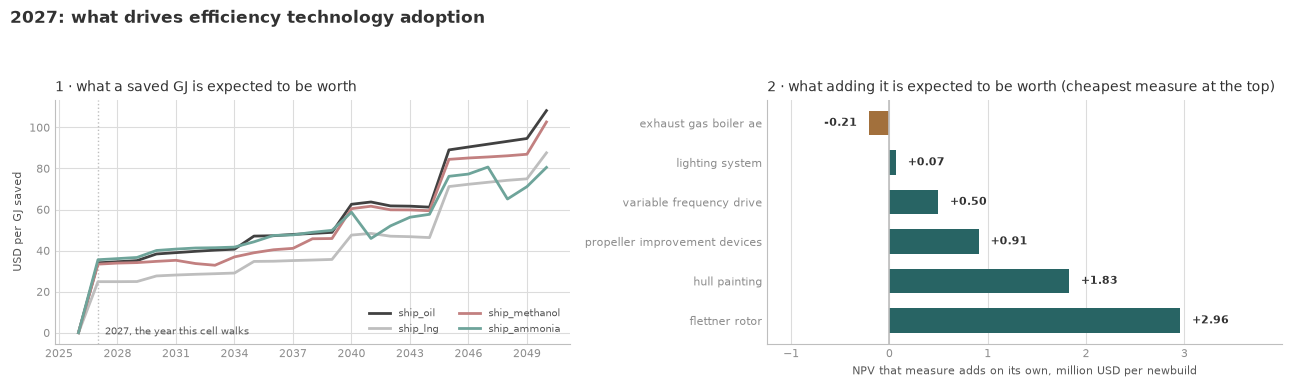

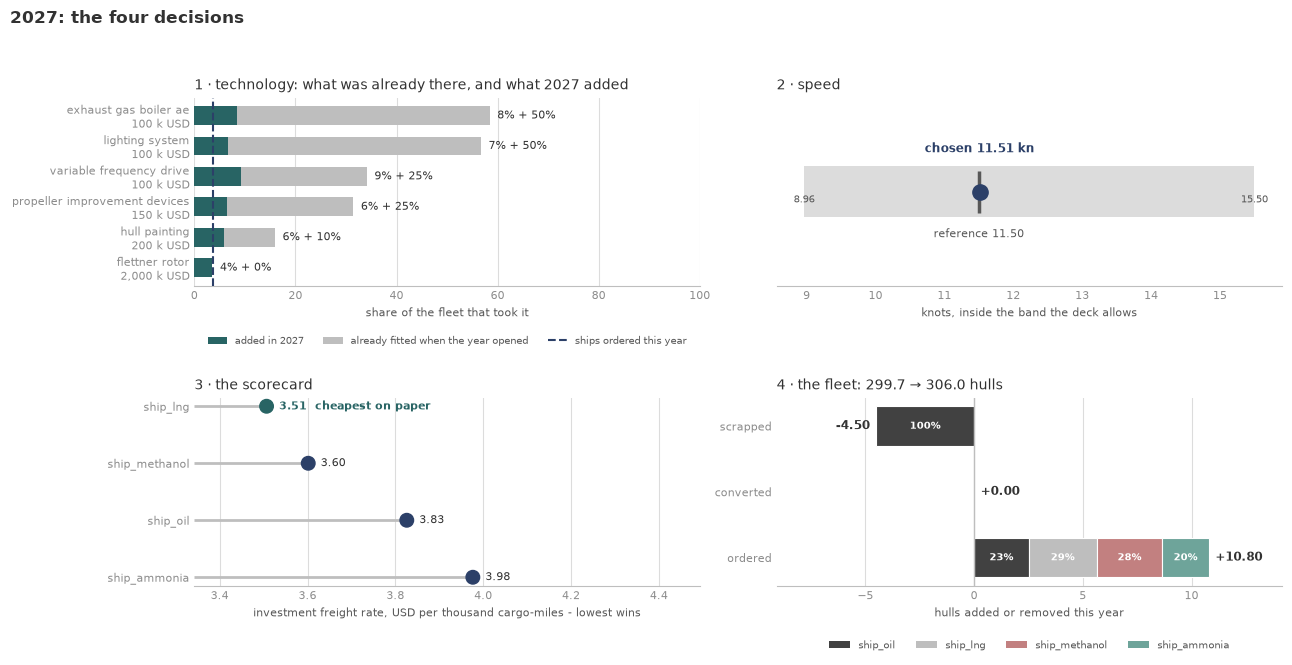

In [25]:
# The four levers Stage 2 pulls, side by side. Each panel is one decision, taken
# on this year's beliefs and without waiting for the other three.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from navigate.illustrations.plots._labels import FUEL_TYPE_ORDER
from matplotlib.ticker import MaxNLocator

def flow_by_config(getter, step, credit_destination=False):
    """One flow, split by vessel configuration.

    Conversions are keyed (from, to) rather than by a single name, so credit the
    hull to what it BECOMES and drop the same-to-same entries, which are not
    conversions at all. Scrapping and newbuilds are keyed by name already.
    """
    out = {}
    for key, value in at(getter, step).items():
        if isinstance(key, tuple):
            source, destination = key
            if source == destination:
                continue
            name = destination if credit_destination else source
        else:
            name = key
        out[name] = out.get(name, 0.) + value
    return out


def stage2_state(step):
    """Everything the four levers decided in one step, and what drove lever 1."""
    # lever 1: technology. get_fleet_technology_uptake is the FLEET share, 0 to 1.
    # get_technology_uptake is per vessel CONFIGURATION, and summed across the
    # four of them it can exceed 1.
    series_ = copper_trade.profile.get_fleet_technology_uptake()

    def share_at(idx):
        return {name.replace("_bulk_carrier_panamax", ""):
                float(np.nan_to_num(np.asarray(s, dtype=float))[idx])
                for name, s in series_.items()}

    uptake = share_at(step)
    # what the fleet ALREADY had when the year opened, from the library's observed
    # world-fleet shares. The difference is all this year's decision actually did.
    inherited = share_at(step - 1)

    # lever 2: speed
    speed = {k: total_at(getattr(copper_trade.profile, f"get_{k}_speed"), step)
             for k in ("actual", "reference", "minimum", "maximum")}

    # lever 3: the scorecard the newbuild choice is made on
    scores = {name: float(np.nan_to_num(
                  vessel.profile.get_investment_freight_rate(idx=step)))
              for name, vessel in base.nodes.vessels.items()
              if vessel.profile.is_active(step)}

    # lever 4: the fleet, in perform_fleet_evolution's own order
    scrap_by = flow_by_config(copper_trade.profile.get_scrap, step)
    convert_by = flow_by_config(copper_trade.profile.get_fuel_conversions, step,
                                credit_destination=True)
    order_by = flow_by_config(copper_trade.profile.get_newbuilds, step)
    scrapped = sum(scrap_by.values())
    ordered = sum(order_by.values())
    opening = sum(at(copper_trade.profile.get_existing_vessels, step - 1).values())
    closing = sum(at(copper_trade.profile.get_existing_vessels, step).values())
    assert abs(opening - scrapped + ordered - closing) < 1e-6, \
        "the waterfall does not close"

    # how lever 1 actually chose. Two numbers decide it: what a saved GJ is WORTH
    # - the bunkering LP's energy dual, smoothed into an investment signal - and
    # what each technology COSTS to install. A package is bought when the first,
    # applied to the energy it saves, beats the second; and the choice is
    # odds-based against doing nothing, so a technology that only just pays gets
    # some of the fleet rather than all of it.
    signal_path = {n: np.nan_to_num(np.asarray(
                       base.nodes.vessels[n].profile.get_investment_signal_technology(),
                       dtype=float)) for n in CONFIGS}

    when = base.get_timeline()[step]

    def limit_now(node):
        """A technology limit is a Scalar for most, a Forecast for a gated one."""
        try:
            return float(np.nan_to_num(np.asarray(node.get(when), dtype=float)))
        except TypeError:
            return float(np.nan_to_num(np.asarray(node.get(), dtype=float)))

    tech_rows = []
    for tech in copper_trade.technologies:
        full = tech.get_name()
        name = full.replace("_bulk_carrier_panamax", "")
        offered = max(limit_now(copper_trade.newbuild_technology_limit[full]),
                      limit_now(copper_trade.retrofit_technology_limit[full])) > 0.
        tech_rows.append((name, float(tech.CAPEX.get()), uptake.get(name, 0.) * 100,
                          offered, inherited.get(name, 0.) * 100))
    tech_rows.sort(key=lambda r: r[1])

    return {"uptake": uptake, "inherited": inherited, "speed": speed,
            "scores": scores, "scrap_by": scrap_by, "convert_by": convert_by,
            "order_by": order_by, "scrapped": scrapped,
            "converted": sum(convert_by.values()), "ordered": ordered,
            "opening": opening, "closing": closing,
            "signal_path": signal_path, "tech_rows": tech_rows}


# the year this Part walks: its signal path is what the figure below draws
signal_path = stage2_state(STEP_EARLY)["signal_path"]

fig2, (axV, axW) = plt.subplots(1, 2, figsize=(13, 3.9))
fig2.suptitle(f"{FOCUS_YEARS[0]}: what drives efficiency technology adoption",
              fontsize=12, color=INK, x=0.01, ha="left", fontweight="bold")

# left: the price the whole lever turns on, over the whole horizon rather than
# at a couple of years - the SHAPE is the point, since a technology bought now is
# paid for once and earns against this curve for the rest of its life.
for name in CONFIGS:
    axV.plot(YEARS, signal_path[name], lw=2, color=config_colour(name), label=name,
             zorder=3)
axV.axvline(YEARS[STEP_EARLY], color=AXIS, lw=1, ls=":", zorder=2)
axV.annotate(f"{FOCUS_YEARS[0]}, the year this cell walks",
             (YEARS[STEP_EARLY], axV.get_ylim()[0]), xytext=(5, 5),
             textcoords="offset points", fontsize=7.5, color=SUBINK, va="bottom")
axV.set_ylabel("USD per GJ saved", fontsize=8, color=SUBINK)
axV.xaxis.set_major_locator(MaxNLocator(integer=True))
axV.set_title("1 · what a saved GJ is expected to be worth", fontsize=10, color=INK, loc="left")
axV.grid(color=GRID, lw=0.8)
axV.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=2, loc="lower right")

# right: what ADDING each measure is worth on its own. The model works in
# cumulative packages, so the value of one measure is the step between two of
# them - a subtraction of numbers the model produced, nothing recomputed.
_npv = snap.get("npv_newbuild", [])
_order = snap.get("asset_order", [])
_ladder = snap.get("ladder", [])
if not _npv or not _ladder:
    raise RuntimeError(
        "These snapshots predate the NPV hook. Re-run the run_case cell above, "
        "then this one.")
_pick = _order.index(CONFIGS[0]) if CONFIGS[0] in _order else 0
_steps = np.diff(np.asarray(_npv[_pick], dtype=float)) / 1e6
_step_names = [name for _capex, name in _ladder[1:]]

axW.barh(range(len(_steps)), _steps, height=.62, zorder=3,
         color=[GREEN if v > 0 else ORANGE for v in _steps])
for _i, _v in enumerate(_steps):
    axW.annotate(f"{_v:+.2f}", (_v + (.12 if _v >= 0 else -.12), _i), va="center",
                 ha="left" if _v >= 0 else "right", fontsize=8,
                 color=INK, fontweight="bold")
axW.set_yticks(range(len(_steps)),
               [n.replace("_", " ") for n in _step_names])
axW.invert_yaxis()
axW.axvline(0, color=AXIS, lw=1.2, zorder=4)
_pad = max(abs(_steps.min()), abs(_steps.max())) * .35 if _steps.size else 1.
axW.set_xlim(_steps.min() - _pad, _steps.max() + _pad)
axW.set_xlabel("NPV that measure adds on its own, million USD per newbuild",
               fontsize=8, color=SUBINK)
axW.set_title("2 · what adding it is expected to be worth (cheapest measure at the top)",
              fontsize=10, color=INK, loc="left")
axW.grid(axis="x", color=GRID, lw=0.8)

for ax in (axV, axW):
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color(AXIS)

fig2.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


def draw_four_decisions(step, axes, scale_over=None, legend=True):
    """Stage 2's four levers for one year, into four axes (technology, speed,
    scorecard, fleet).

    `scale_over` shares the speed band and the fleet-flow axis across the years
    given. The SCORECARD is deliberately left out of it: those numbers differ in
    the fourth decimal, and one axis across thirteen years would flatten each
    year's spread into a single dot.
    """
    axT, axS, axC, axF = axes
    state = stage2_state(step)
    steps = tuple(scale_over) if scale_over else (step,)
    peers = [stage2_state(s) for s in steps]
    rows_, speed_ = state["tech_rows"], state["speed"]

    # 1 - technology: cheapest first, what it costs and who took it
    labels_ = [r[0].replace("_", " ") for r in rows_]
    had = [r[4] for r in rows_]
    added = [r[2] - r[4] for r in rows_]
    axT.barh(range(len(rows_)), added, height=.62, color=GREEN, zorder=3,
             label=f"added in {YEARS[step]}")
    axT.barh(range(len(rows_)), had, left=added, height=.62, color=MUTED,
             zorder=3, label="already fitted when the year opened")
    for i, (_name, _capex, share, _offered, was) in enumerate(rows_):
        axT.annotate(f"{share - was:.0f}% + {was:.0f}%", (share + 1.5, i), va="center",
                     fontsize=8, color=INK)
    # Ships ordered this year, as a share of the fleet. A measure whose green slice
    # stops at this line was taken by the newbuilds and by nobody else - which is the
    # whole difference between a fleet-wide share and the per-newbuild NPV opposite.
    axT.axvline(state["ordered"] / state["opening"] * 100, color=BLUE, lw=1.5,
                ls="--", zorder=5)
    if legend:
        axT.legend(handles=[Patch(facecolor=GREEN, label=f"added in {YEARS[step]}"),
                            Patch(facecolor=MUTED,
                                  label="already fitted when the year opened"),
                            Line2D([], [], color=BLUE, lw=1.5, ls="--",
                                   label="ships ordered this year")],
                   fontsize=7, frameon=False, labelcolor=SUBINK, ncol=3,
                   loc="upper center", bbox_to_anchor=(0.5, -0.22))
    axT.set_yticks(range(len(rows_)),
                   [f"{l}\n{r[1] / 1e3:,.0f} k USD" for l, r in zip(labels_, rows_)])
    axT.invert_yaxis()
    axT.set_xlim(0, 100)
    axT.set_xlabel("share of the fleet that took it", fontsize=8, color=SUBINK)
    axT.set_title("1 \u00b7 technology: what was already there, and what {} added"
                  .format(YEARS[step]), fontsize=10, color=INK, loc="left")
    axT.grid(axis="x", color=GRID, lw=0.8)

    # 2 - speed, against the band the deck allows
    axS.barh([0], [speed_["maximum"] - speed_["minimum"]], left=speed_["minimum"],
             height=.34, color=PALE, zorder=2)
    axS.plot([speed_["reference"]], [0], marker="|", ms=30, mew=2.5, color=SUBINK,
             zorder=4)
    axS.plot([speed_["actual"]], [0], marker="o", ms=11, color=BLUE, zorder=5)
    axS.annotate(f"chosen {speed_['actual']:.2f} kn", (speed_["actual"], .26),
                 ha="center", fontsize=8.5, color=BLUE, fontweight="bold")
    axS.annotate(f"reference {speed_['reference']:.2f}", (speed_["reference"], -.30),
                 ha="center", fontsize=8, color=SUBINK)
    for edge in ("minimum", "maximum"):
        axS.annotate(f"{speed_[edge]:.2f}", (speed_[edge], 0), xytext=(0, -2),
                     textcoords="offset points", ha="center", va="top", fontsize=7.5,
                     color=SUBINK)
    axS.set_xlim(min(p["speed"]["minimum"] for p in peers) - .4,
                 max(p["speed"]["maximum"] for p in peers) + .4)
    axS.set_ylim(-.62, .62)
    axS.set_yticks([])
    axS.set_xlabel("knots, inside the band the deck allows", fontsize=8, color=SUBINK)
    axS.set_title("2 \u00b7 speed", fontsize=10, color=INK, loc="left")

    # 3 - the scorecard. A dot plot, because these differ only slightly and bars
    # from zero would hide the whole story. Scaled to ITS OWN year, on purpose.
    # Per THOUSAND cargo-miles, as everywhere else in the workshop.
    scores_ = state["scores"]
    order_ = sorted(scores_, key=scores_.get)
    vals = [1e3 * scores_[n] for n in order_]
    best, worst = min(vals), max(vals)
    floor = best - (worst - best) * .35
    axC.hlines(range(len(order_)), floor, vals, color=MUTED, lw=2, zorder=2)
    axC.scatter(vals, range(len(order_)), s=95, zorder=4,
                color=[GREEN if v == best else BLUE for v in vals])
    for i, v in enumerate(vals):
        axC.annotate(f"{v:.2f}" + ("  cheapest on paper" if v == best else ""),
                     (v, i), xytext=(9, 0), textcoords="offset points", va="center",
                     fontsize=8, color=GREEN if v == best else INK,
                     fontweight="bold" if v == best else "normal")
    axC.set_yticks(range(len(order_)), order_)
    axC.invert_yaxis()
    axC.set_xlim(floor, worst + (worst - best) * 1.1)
    axC.set_xlabel("investment freight rate, USD per thousand cargo-miles - lowest wins",
                   fontsize=8, color=SUBINK)
    axC.set_title("3 \u00b7 the scorecard", fontsize=10, color=INK, loc="left")
    axC.grid(axis="x", color=GRID, lw=0.8)

    # 4 - the fleet. Only the FLOWS are drawn: opening and closing differ by about 2%,
    # so a stock-on-stock waterfall would show four bars of the same apparent height.
    # Each bar is split by configuration, in Stage 0's colours, because WHICH hulls
    # leave and which arrive is the whole point of the lever.
    hue = {n: config_colour(n) for n in CONFIGS}
    stack_ = sorted(CONFIGS,
                    key=lambda n: FUEL_TYPE_ORDER.index(base.nodes.vessels[n].fuel_type))

    def flows_of(s):
        return [("scrapped", {n: -v for n, v in s["scrap_by"].items()}),
                ("converted", s["convert_by"]),
                ("ordered", s["order_by"])]

    flows_ = flows_of(state)
    # the value labels sit outside their bars, so the axis needs slack at both ends
    # or "-4.50" lands on top of the "scrapped" tick label. Worked out before the
    # bars are drawn, because the share labels are judged against it.
    every = [sum(parts.values()) for p in peers for _l, parts in flows_of(p)]
    lo, hi = min(0., min(every)), max(0., max(every))
    span = (hi - lo) or 1.
    axF.set_xlim(lo - span * .30, hi + span * .22)
    axis_width = span * 1.52

    for i, (_label, parts) in enumerate(flows_):
        run_pos = run_neg = 0.
        row_total = sum(parts.values()) or 1.
        for name in stack_:
            value = parts.get(name, 0.)
            if abs(value) < 1e-9:
                continue
            start = run_pos if value > 0 else run_neg
            axF.barh(i, value, left=start, height=.6, color=hue[name],
                     zorder=3, edgecolor="white", linewidth=.8)
            # the share of THIS flow, so the reader can see that scrapping is all one
            # configuration while ordering is spread across every one of them
            share = abs(value) / abs(row_total) * 100
            # a slice worth 29% of its row is still unreadable if the row is 3% of
            # the axis, which is what happens once both years share one scale
            if share >= 10 and abs(value) / axis_width >= 0.05:
                axF.annotate(f"{share:.0f}%", (start + value / 2, i), ha="center",
                             va="center", fontsize=7.5, color="white",
                             fontweight="bold", zorder=5)
            if value > 0:
                run_pos += value
            else:
                run_neg += value

    for i, (_label, parts) in enumerate(flows_):
        total = sum(parts.values())
        axF.annotate(f"{total:+.2f}", (total + (.3 if total >= 0 else -.3), i),
                     va="center", ha="left" if total >= 0 else "right", fontsize=8.5,
                     fontweight="bold", color=INK)
    axF.set_yticks(range(len(flows_)), [f[0] for f in flows_])
    axF.invert_yaxis()
    axF.axvline(0, color=AXIS, lw=1, zorder=4)
    axF.set_xlabel("hulls added or removed this year", fontsize=8, color=SUBINK)
    axF.set_title(f"4 \u00b7 the fleet: {state['opening']:,.1f} \u2192 "
                  f"{state['closing']:,.1f} hulls",
                  fontsize=10, color=INK, loc="left")
    axF.grid(axis="x", color=GRID, lw=0.8)
    moved = [n for n in stack_
             if any(abs(parts.get(n, 0.)) > 1e-9 for _l, parts in flows_)]
    if moved and legend:
        axF.legend(handles=[Patch(facecolor=hue[n], label=n) for n in moved],
                   fontsize=7.5, frameon=False, labelcolor=SUBINK,
                   ncol=min(len(moved), 4),
                   loc="upper center", bbox_to_anchor=(0.5, -0.24))

    for ax in (axT, axS, axC, axF):
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)


fig, ((axT, axS), (axC, axF)) = plt.subplots(2, 2, figsize=(13, 7.1))
fig.suptitle(f"{FOCUS_YEARS[0]}: the four decisions", fontsize=12, color=INK,
             x=0.01, ha="left", fontweight="bold")
draw_four_decisions(STEP_EARLY, (axT, axS, axC, axF))
fig.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


### Stage 3 — The producer decides too

The operator and the producer read and write shared state: the
fleet's expected bunkering *is* the producer's order book, and the plants'
output *is* the fleet's available supply.

There is an intentional structural lag between the two. The demand is taken directly from the expected bunkering calculated previously in the time-step, so it does not account for the newest fleet evolution but rather a time-lagged view. The producer is acting on the demand figure computed *earlier in this same year* — before the newbuilds and retrofits we just watched.

In this example the build-rate ceiling (max number of plants that can be built) is voluntarily not binding, though the gasifiable-biomass feedstock ceiling is. Both can be investigated in the sensitivity analysis section. 

Check `navigate/fuel/supply_demand.py` and `_calculate_expected_fleet_fuel_demand` for more details.


=== 2027: what the producer saw, and did ===

the demand vector it read (this year's forward view, first year):
  fossil_fuel_oil                  66,001.3 TJ/yr   ( 1,602.0 kt/yr)
  liquefied_natural_gas                57.3 TJ/yr   (     1.2 kt/yr)


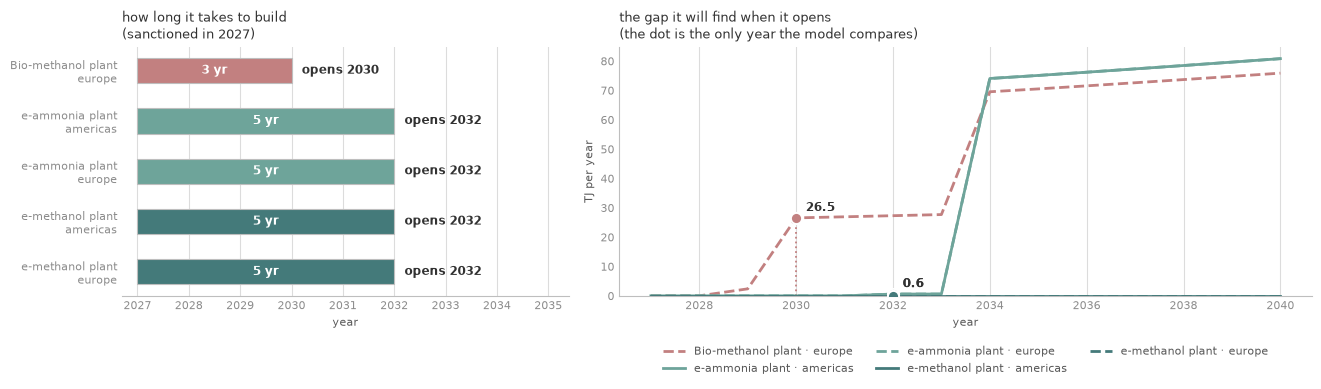

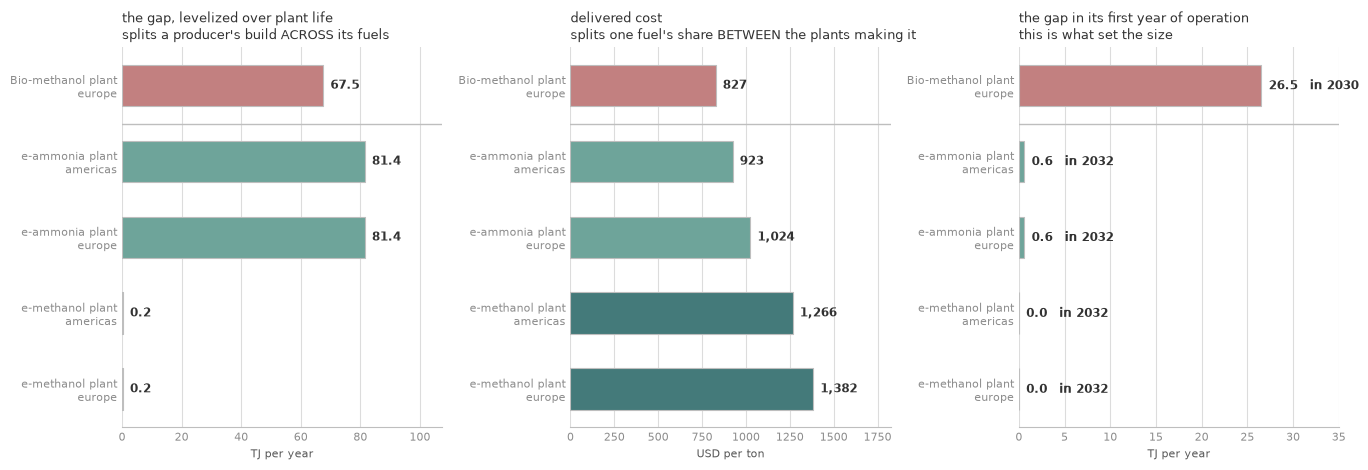


the groups in 2027, after plants with no gap are dropped:
  producer_biofuel     methanol_bio           1 plant in demand
  producer_efuel       ammonia_electro        2 plants in demand
  producer_efuel       methanol_electro       2 plants in demand

Neither producer came near its build-rate ceiling:
  producer_biofuel       0.0027 of   8.31 plants  ( 0.03% of the ceiling)
  producer_efuel         0.0003 of   8.31 plants  ( 0.00% of the ceiling)


In [26]:
print(f"=== {FOCUS_YEARS[0]}: what the producer saw, and did ===\n")
print("the demand vector it read (this year's forward view, first year):")
# get_fuel_demand() is a mass in tons, so it takes each fuel's own heating value
# to reach energy. Everything else in this cell is TJ/yr, so this has to be too.
for fuel, path in sorted(snap["fuel_demand"].items(),
                         key=lambda kv: -float(np.nan_to_num(kv[1][0]))):
    _tons = float(np.nan_to_num(path[0]))
    head = _tons * float(base.nodes.fuels[fuel].lower_heating_value.get()) / 1e3
    if head > 0:
        print(f"  {fuel:26} {head:14,.1f} TJ/yr   ({_tons / 1e3:8,.1f} kt/yr)")

def producer_view(step):
    """The producer's plants for one step: order, labels, and the derived gaps.

    Order groups by owner, because a plant is only ever weighed against the
    other plants of its OWN producer and that is not obvious from the names.

    The two gap figures are different quantities. `gap_levelized` is the gap
    levelized over the plant's life, which is what splits a producer's build
    across its fuels. `gap_at_startup` multiplies the plant COUNT back by one
    plant's own yearly output, giving the gap it is SIZED on - read in a
    different year again, because the evaluation grid starts at lead_time and
    steps one year at a time, so the only year compared is the plant's
    FIRST YEAR OF OPERATION.
    """
    seen = snaps[step]["producer"]
    plants = sorted(seen, key=lambda p: (seen[p]["producer"], p))

    for _d in seen.values():
        _d["gap_levelized"] = _d["expected_demand"] / 1e3
        _d["gap_at_startup"] = (_d["plants_justified"] * _d["plant_output"]
                                * _d["lhv"]) / 1e3
        _d["online"] = YEARS[step] + int(round(_d["lead_time"]))

    fuel_of = {p: base.nodes.plants[p].fuel.get_name() for p in plants}
    region_of = {p: base.nodes.plants[p].region.get_name() for p in plants}

    # A group of one takes 100% of its group whatever its metric says, which is
    # how an axis can be present and still decide nothing.
    groups = {}
    for p in plants:
        if seen[p]["gap_levelized"] > 0:   # is_in_demand(): no gap, no plant
            groups.setdefault((seen[p]["producer"], fuel_of[p]), []).append(p)
    per_owner = {}
    for _owner, _fuel in groups:
        per_owner[_owner] = per_owner.get(_owner, 0) + 1

    return {"plants": plants,
            "owners": [seen[p]["producer"] for p in plants],
            "fuel_of": fuel_of, "region_of": region_of,
            "colour": [fuel_colour(fuel_of[p]) for p in plants],
            # Label by fuel AND where it is made: two plants can make the same
            # fuel, so stripping the node name would leave them indistinguishable.
            "ticks": [f"{fuel_label(fuel_of[p])} plant\n{region_of[p]}"
                      for p in plants],
            "groups": groups,
            "cost_live": any(len(v) > 1 for v in groups.values()),
            "gap_live": any(n > 1 for n in per_owner.values())}


_view = producer_view(STEP_EARLY)
plants = _view["plants"]
FUEL_OF, REGION_OF = _view["fuel_of"], _view["region_of"]
colour, ticks = _view["colour"], _view["ticks"]
groups = _view["groups"]
# a shared fuel means a shared colour, so the region carries the line style
dashes = ["-" if REGION_OF[p] == "americas" else "--" for p in plants]

if "demand_path" not in next(iter(snap["producer"].values())):
    raise RuntimeError(
        "These snapshots predate the producer demand path. Re-run the run_case "
        "cell above, then this one.")


# ---------------------------------------------------------------------------
# 1. What sets the SIZE: how long the plant takes to build, and what the gap has
#    grown to by the time it opens. Drawn rather than described. The demand path
#    is the producer's own expectation from the same snapshot - the very series
#    the sizing marker is read off, so the dot must lie on the curve.
_stop = min(len(YEARS), STEP_EARLY + 14)
_yrs = YEARS[STEP_EARLY:_stop]
_leads = [snap["producer"][p]["lead_time"] for p in plants]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.3),
                               gridspec_kw={"width_ratios": [1, 1.55]})

for i, _plant in enumerate(plants):
    _d = snap["producer"][_plant]
    axL.barh(i, _d["lead_time"], left=FOCUS_YEARS[0], height=.5, color=colour[i],
             zorder=3, edgecolor=AXIS, linewidth=0.8)
    axL.annotate(f"{_d['lead_time']:.0f} yr", (FOCUS_YEARS[0] + _d["lead_time"] / 2, i),
                 ha="center", va="center", fontsize=8.5, color="white",
                 fontweight="bold", zorder=5)
    axL.annotate(f"opens {_d['online']}", (_d["online"] + .2, i), va="center",
                 fontsize=8.5, color=INK, fontweight="bold")
axL.set_yticks(range(len(plants)), ticks)
axL.invert_yaxis()
axL.set_xlim(FOCUS_YEARS[0] - .3, FOCUS_YEARS[0] + max(_leads) + 3.4)
axL.set_title(f"how long it takes to build\n(sanctioned in {FOCUS_YEARS[0]})",
              fontsize=9.5, color=INK, loc="left")

for i, _plant in enumerate(plants):
    _d = snap["producer"][_plant]
    _path = np.asarray(_d["demand_path"], dtype=float)[STEP_EARLY:_stop]
    axR.plot(_yrs, _path, lw=2, color=colour[i], ls=dashes[i], zorder=3,
             label=f"{fuel_label(FUEL_OF[_plant])} plant · {REGION_OF[_plant]}")
    axR.plot([_d["online"]] * 2, [0., _d["gap_at_startup"]], ls=":", lw=1.3,
             color=colour[i], zorder=2)
    axR.plot(_d["online"], _d["gap_at_startup"], "o", ms=8, color=colour[i],
             markeredgecolor="white", markeredgewidth=1.4, zorder=5)
    # several plants can open in the same year with nothing to read, and four
    # "0.0" labels on one point is just noise - a dot on the axis says it
    if _d["gap_at_startup"] > 0.05:
        axR.annotate(f"{_d['gap_at_startup']:,.1f}",
                     (_d["online"], _d["gap_at_startup"]),
                     textcoords="offset points", xytext=(7, 5), fontsize=8.5,
                     color=INK, fontweight="bold")
axR.set_ylim(bottom=0.)
axR.set_title("the gap it will find when it opens\n"
              "(the dot is the only year the model compares)",
              fontsize=9.5, color=INK, loc="left")
axR.set_ylabel("TJ per year", fontsize=8, color=SUBINK)
axR.legend(fontsize=8, frameon=False, labelcolor=SUBINK, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))

for ax in (axL, axR):
    ax.set_xlabel("year", fontsize=8, color=SUBINK)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
axL.spines["left"].set_visible(False)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


# ---------------------------------------------------------------------------
# 2. The two share axes. calculate_two_axis_uptake does not PICK a plant: it
#    returns a share per plant. Plants are grouped by the FUEL they make, and
#    a plant's share is the product of two splits:
#       delivered cost  -> splits a fuel's share between the plants making THAT
#                          SAME fuel. It never compares two different fuels.
#       levelized gap   -> splits a producer's build across its fuels.
#    A group of one takes 100% of its group whatever its metric says, which is
#    how an axis can be present and still decide nothing.
def draw_producer_axes(step, axes, scale_over=None):
    """Stage 3's three axes for one year, into three axes objects.

    `scale_over` names the steps whose data set the x limits, so the 2040
    comparison can be read row against row rather than each panel filling itself.
    """
    view = producer_view(step)
    seen = snaps[step]["producer"]
    plants_ = view["plants"]
    steps = tuple(scale_over) if scale_over else (step,)

    panels = [
        ("the gap, levelized over plant life", "TJ per year", "gap_levelized",
         "splits a producer's build ACROSS its fuels",
         None if view["gap_live"] else "idle here: each producer had one fuel in demand",
         view["gap_live"]),
        ("delivered cost", "USD per ton", "delivered_cost",
         "splits one fuel's share BETWEEN the plants making it",
         None if view["cost_live"] else "idle here: every fuel is made by one plant",
         view["cost_live"]),
        ("the gap in its first year of operation", "TJ per year", "gap_at_startup",
         "this is what set the size", None, True),
    ]

    for ax, (title, unit, key, note, idle, live) in zip(axes, panels):
        values = [seen[p][key] for p in plants_]
        # an axis that decided nothing is greyed, so the eye does not read it as a
        # reason for the outcome on its right
        fills = view["colour"] if live else [TICK] * len(plants_)
        ax.barh(range(len(plants_)), values, height=.55, color=fills, zorder=3,
                edgecolor=AXIS, linewidth=0.8)
        span = max(max(snaps[s]["producer"][p][key]
                       for p in producer_view(s)["plants"]) for s in steps) or 1.
        for i, value in enumerate(values):
            text = f"{value:,.0f}" if span > 200 else f"{value:,.1f}"
            # on the sizing panel the YEAR matters as much as the number
            if key == "gap_at_startup":
                text += f"   in {seen[plants_[i]]['online']}"
            ax.annotate(text, (value + span * 0.03, i), va="center", fontsize=8.5,
                        color=INK if live else SUBINK, fontweight="bold")
        for i in range(1, len(plants_)):
            if view["owners"][i] != view["owners"][i - 1]:
                ax.axhline(i - .5, color=AXIS, lw=1.0, zorder=4)
        ax.set_yticks(range(len(plants_)), view["ticks"])
        ax.invert_yaxis()
        ax.set_xlim(0, span * 1.32)
        ax.set_xlabel(unit, fontsize=8, color=SUBINK)
        ax.set_title(f"{title}\n{note}" + (f"\n{idle}" if idle else ""),
                     fontsize=9.5, color=INK if live else SUBINK, loc="left")
        ax.grid(axis="x", color=GRID, lw=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)


fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.8))
draw_producer_axes(STEP_EARLY, axes)
fig.tight_layout()
plt.show()

print(f"\nthe groups in {FOCUS_YEARS[0]}, after plants with no gap are dropped:")
for (_owner, _fuel), _members in groups.items():
    print(f"  {_owner:20} {_fuel:22} {len(_members)} plant"
          f"{'s' if len(_members) > 1 else ''} in demand")
by_owner = {}
for _plant in plants:
    by_owner.setdefault(snap["producer"][_plant]["producer"], []).append(_plant)
print("\nNeither producer came near its build-rate ceiling:")
for _owner, _members in by_owner.items():
    _cap = snap["producer"][_members[0]]["max_development"]
    _used = sum(snap["producer"][p]["plants_justified"] for p in _members)
    print(f"  {_owner:20} {_used:8.4f} of {_cap:6.2f} plants  "
          f"({_used / _cap * 100:5.2f}% of the ceiling)")

### Stage 4 — Commit: the bunkering algorithm that binds

The forward optimization bunkering algorithm of Stage 1 was a belief. 
Now the year is bought for real, with the new fleet from this year and against what the producers actually
delivered.


=== 2027: the bunkering plan, tons per ship ===

  fuel                           san_antonio
  fossil_fuel_oil                     16,544
  liquefied_natural_gas                4,316

what the voyage actually cost this year: 3.52 USD per thousand cargo-miles

Note which fuels appear against which port, and that a dual-fuel hull
can still bunker oil. Ordering the ship and burning the fuel are two
different decisions.


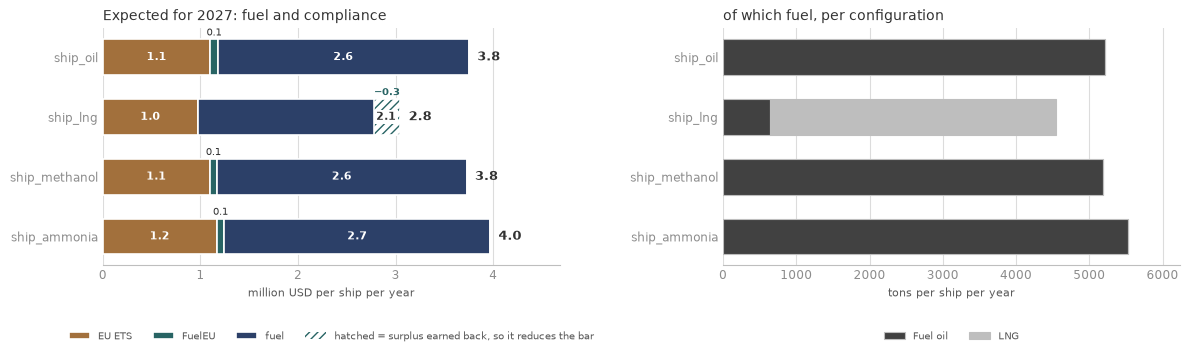

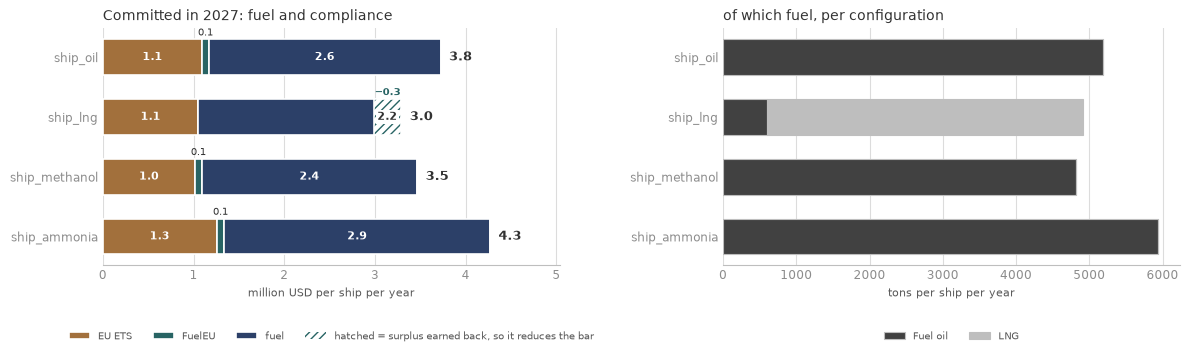

=== 2027: expected against committed, per ship ===

                        tons bunkered            total bill, M USD     
                  expected committed     gap expected committed     gap
  ship_oil           5,219     5,183   -0.7%     3.75      3.72   -0.7%
  ship_lng           4,540     4,910   +8.1%     2.77      2.99   +7.7%
  ship_methanol      5,188     4,825   -7.0%     3.73      3.47   -7.0%
  ship_ammonia       5,522     5,942   +7.6%     3.97      4.27   +7.6%

The two gap columns are the same number. Nothing was mispriced: the
look-ahead in Stage 1 costed a fleet that Stage 2 then changed underneath
it - ordering, scrapping and fitting technology - and Stage 4 committed
whatever the resulting ships actually burned.


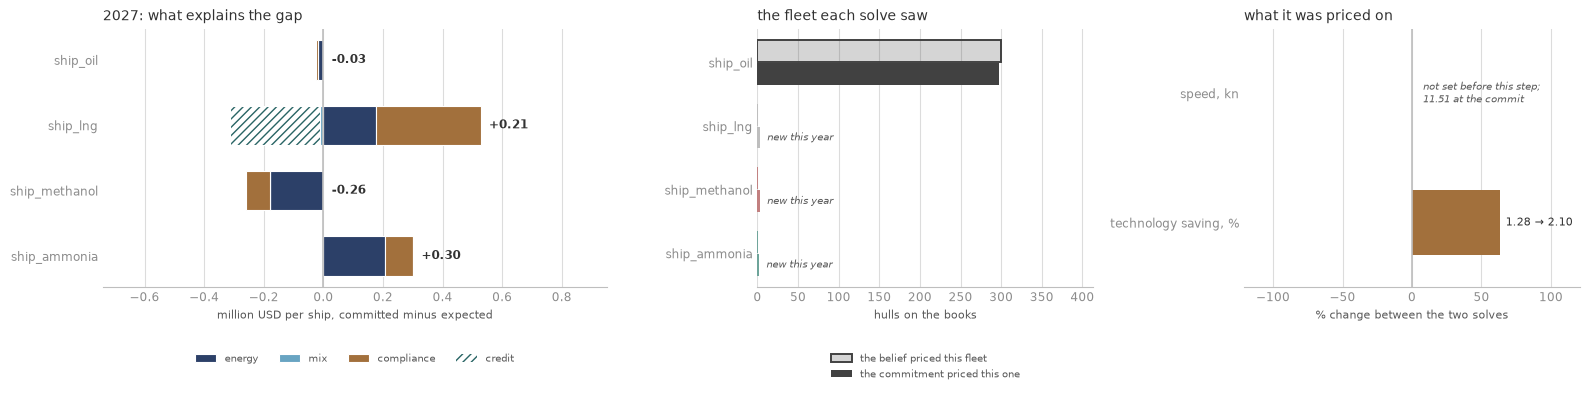

In [27]:
from matplotlib.colors import to_rgba

plan = {}
for (vessel, port, fuel), tons in snap["bunkered"].items():
    plan.setdefault(fuel, {}).setdefault(port, 0.0)
    plan[fuel][port] += tons

ports = sorted({p for byport in plan.values() for p in byport})
print(f"=== {FOCUS_YEARS[0]}: the bunkering plan, tons per ship ===\n")
print(f"  {'fuel':26}" + "".join(f"{p:>16}" for p in ports))
for fuel in sorted(plan, key=lambda f: -sum(plan[f].values())):
    row = "".join(f"{plan[fuel].get(p, 0):16,.0f}" for p in ports)
    print(f"  {fuel:26}{row}")

rate = total_at(copper_trade.profile.get_instantaneous_freight_rate, STEP_EARLY)
print(f"\nwhat the voyage actually cost this year: {1e3 * rate:.2f} USD per thousand "
      "cargo-miles")
print("\nNote which fuels appear against which port, and that a dual-fuel hull")
print("can still bunker oil. Ordering the ship and burning the fuel are two")
print("different decisions.")


# What the operator EXPECTED of this year when it took the decision, and then
# what it actually committed. The belief comes first because it is what the
# decision was made on. Both are split the same four ways so they can be read
# against each other; the belief's split has to be recorded as it is produced,
# because the expectation itself keeps compliance as one untagged number.
from navigate.illustrations.plots._labels import FUEL_ORDER


def tons_limit(*steps):
    """One x limit for the fuel panels, so they can be compared by eye.

    Given several steps it spans them all, which is what puts the 2040 repeat on
    the same scale as the 2027 original instead of each filling its own panel.
    """
    return 1.05 * max(
        sum(t for (v, _p, _f), t in mix.items() if v == name)
        for step in steps
        for mix in (snaps[step]["expected_mix_first"], snaps[step]["bunkered"])
        for name in CONFIGS)


def plot_expected_bill(step, axes=None, scale_over=None, legend=True):
    """This year as it was expected: fuel, each scheme, and the fuel behind it.

    Split the same four ways as the committed panel below, so the two can be
    read against each other. One honest difference: the belief never forms a
    GROSS surplus. The look-ahead stores flexibility units NET of surplus units
    and the signal layer prices that net, so a ship expecting to be a net seller
    shows a negative scheme line, and that is what is drawn as the credit here.
    """

    snapshot = snaps[step]
    mix = snapshot.get("expected_mix_first")
    if not mix:
        raise RuntimeError(
            "These snapshots predate the first-year expected mix. Re-run the "
            "run_case cell above, then this one.")
    if "expected_policy" not in snapshot:
        raise RuntimeError(
            "These snapshots predate the per-scheme expected split. Re-run the "
            "run_case cell above, then this one.")

    REG_LABEL = {"eu_ets": "EU ETS", "fuel_eu": "FuelEU"}

    # Per ship of that configuration, as everywhere else in this Part.
    rows = {}
    for name in CONFIGS:
        part, credit = {}, 0.
        for reg_name in base.nodes.regulations:
            net = snapshot["expected_policy"][(name, reg_name)][0] / 1e6
            part[REG_LABEL.get(reg_name, reg_name)] = max(net, 0.)
            credit += max(-net, 0.)
        rows[name] = {"fuel": snapshot["operator"][name]["fuel_path"][0] / 1e6,
                      **part, "credit": credit}
        # the parts must still add up to the belief the decision was taken on
        assert abs(sum(part.values()) - credit
                   - snapshot["operator"][name]["policy_path"][0] / 1e6) < 1e-6

    own_figure = axes is None
    if own_figure:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
    axA, axB = axes
    y = range(len(CONFIGS))

    # Read the way the TTW/WTW figure reads. The surplus is a credit: drawn white
    # and hatched in the colour of the scheme that pays it (FuelEU), eating back
    # into the bar, so what stays solid is what the ship pays. Fuel goes last, so
    # the credit only ever eats into that one slice, as the WTT credit eats into
    # TTW there. label_bill() prints the numbers so that each row adds up.
    credit = np.array([rows[n]["credit"] for n in CONFIGS])

    left = np.zeros(len(CONFIGS))
    slices = []
    for part_name in ("EU ETS", "FuelEU", "fuel"):
        values = np.array([rows[n][part_name] for n in CONFIGS])
        axA.barh(list(y), values, left=left, height=.6, color=cost_colour(part_name),
                 label=part_name, zorder=3, edgecolor="white", linewidth=1.2)
        slices.append((values, left.copy()))
        left += values
    axA.barh(list(y), -credit, left=left, height=.6, facecolor="white",
             hatch="////", edgecolor=cost_colour("FuelEU"), linewidth=0, zorder=4,
             label="hatched = surplus earned back, so it reduces the bar")
    axA.barh(list(y), -credit, left=left, height=.6, facecolor="none",
             edgecolor="white", linewidth=1.2, zorder=4)
    label_bill(axA, slices, credit, digits=1)
    axA.set_title(f"Expected for {YEARS[step]}: fuel and compliance",
                  fontsize=10, color=INK, loc="left")
    axA.set_xlim(0, left.max() * 1.18)
    axA.set_xlabel("million USD per ship per year", fontsize=8, color=SUBINK)
    axA.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, -0.24))

    fuels_used = [f for f in FUEL_ORDER if any(k[2] == f for k in mix)]
    left = np.zeros(len(CONFIGS))
    for fuel_name in fuels_used:
        values = np.array([sum(v for (n2, _p, f), v in mix.items()
                               if n2 == name and f == fuel_name) for name in CONFIGS])
        axB.barh(list(y), values, left=left, height=.6, color=fuel_colour(fuel_name),
                 label=fuel_label(fuel_name), zorder=3, edgecolor=AXIS,
                 linewidth=0.8)
        left += values
    axB.set_title("of which fuel, per configuration", fontsize=10, color=INK,
                  loc="left")
    axB.set_xlim(0, tons_limit(*(scale_over or (step,))))
    axB.set_xlabel("tons per ship per year", fontsize=8, color=SUBINK)
    # one legend serves every year in scale_over, so it names every fuel they used
    shown = [f for f in FUEL_ORDER
             if any(k[2] == f for s in (scale_over or (step,))
                    for k in snaps[s]["expected_mix_first"])]
    axB.legend(handles=[Patch(facecolor=fuel_colour(f), edgecolor=AXIS, linewidth=0.8,
                              label=fuel_label(f)) for f in shown],
               fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=len(shown),
               loc="upper center", bbox_to_anchor=(0.5, -0.24))

    for ax in (axA, axB):
        ax.set_yticks(list(y), CONFIGS)
        ax.invert_yaxis()
        ax.grid(axis="x", color=GRID, lw=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8.5, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)
    if not legend:            # one legend is enough when the years are stacked
        for ax in (axA, axB):
            if ax.get_legend() is not None:
                ax.get_legend().remove()
    if own_figure:
        fig.tight_layout(rect=(0, 0.04, 1, 1))
        plt.show()


plot_expected_bill(STEP_EARLY)


# The same year, as it was actually committed. This one comes from the profile,
# which keeps the spend per fuel and the remedial units per regulation - so it
# can split compliance by scheme and show the surplus a compliant ship earns
# back, neither of which the belief above can carry.
def plot_committed_bill(step, axes=None, scale_over=None, legend=True):
    """This year's realised bill: fuel and compliance, and the fuel behind it."""

    def series(getter):
        return float(np.nan_to_num(np.asarray(getter(), dtype=float))[step])

    REG_LABEL = {"eu_ets": "EU ETS", "fuel_eu": "FuelEU"}

    # bunker.X is per vessel and the fleet multiplier is applied separately, so every
    # figure below is one ship of that configuration, not the sub-fleet.
    rows = {}
    for name in CONFIGS:
        profile = base.nodes.vessels[name].profile
        spend = sum(series(lambda f=fuel: profile.get_fuel_expenses(f))
                    for fuel in base.nodes.fuels) / 1e6
        # get_remedial_expenses() is a SINGLE accumulator that every regulation adds
        # into, so it cannot be read as one scheme's bill. The remedial units ARE
        # kept per regulation, and units x the believed unit cost splits it exactly.
        part = {}
        for reg_name, regulation in base.nodes.regulations.items():
            units = series(lambda r=reg_name: profile.get_remedial_units(r))
            part[REG_LABEL.get(reg_name, reg_name)] = (
                units * regulation.expectation.get_remedial_cost(step) / 1e6)
        # pooling sits with the scheme that offers it
        part["FuelEU"] = (part.get("FuelEU", 0.)
                          + series(profile.get_flexibility_expenses) / 1e6)
        # and a ship that beats the limit is PAID. Leaving this out is what made a
        # compliant hull look as though it had overspent against its own forecast.
        rows[name] = {"fuel": spend, **part,
                      "credit": series(profile.get_surplus_revenue) / 1e6}
        # the bar needs the parts, but the parts must still add up to the whole
        assert abs(sum(part.values())
                   - (series(profile.get_remedial_expenses)
                      + series(profile.get_flexibility_expenses)) / 1e6) < 1e-6

    own_figure = axes is None
    if own_figure:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
    axA, axB = axes
    y = range(len(CONFIGS))

    # Read the way the TTW/WTW figure reads. The surplus is a credit: drawn white
    # and hatched in the colour of the scheme that pays it (FuelEU), eating back
    # into the bar, so what stays solid is what the ship pays. Fuel goes last, so
    # the credit only ever eats into that one slice, as the WTT credit eats into
    # TTW there. label_bill() prints the numbers so that each row adds up.
    credit = np.array([rows[n]["credit"] for n in CONFIGS])

    left = np.zeros(len(CONFIGS))
    slices = []
    for part_name in ("EU ETS", "FuelEU", "fuel"):
        values = np.array([rows[n][part_name] for n in CONFIGS])
        axA.barh(list(y), values, left=left, height=.6, color=cost_colour(part_name),
                 label=part_name, zorder=3, edgecolor="white", linewidth=1.2)
        slices.append((values, left.copy()))
        left += values
    axA.barh(list(y), -credit, left=left, height=.6, facecolor="white",
             hatch="////", edgecolor=cost_colour("FuelEU"), linewidth=0, zorder=4,
             label="hatched = surplus earned back, so it reduces the bar")
    axA.barh(list(y), -credit, left=left, height=.6, facecolor="none",
             edgecolor="white", linewidth=1.2, zorder=4)
    label_bill(axA, slices, credit, digits=1)
    axA.set_title(f"Committed in {YEARS[step]}: fuel and compliance",
                  fontsize=10, color=INK, loc="left")
    axA.set_xlim(0, left.max() * 1.18)
    axA.set_xlabel("million USD per ship per year", fontsize=8, color=SUBINK)
    axA.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=4,
               loc="upper center", bbox_to_anchor=(0.5, -0.24))

    # In TONS, so this panel and the expected one above it answer the same
    # question. 
    mix = snaps[step]["bunkered"]
    fuels_used = [f for f in FUEL_ORDER if any(k[2] == f for k in mix)]
    left = np.zeros(len(CONFIGS))
    for fuel_name in fuels_used:
        values = np.array([sum(v for (n2, _p, f), v in mix.items()
                               if n2 == name and f == fuel_name) for name in CONFIGS])
        axB.barh(list(y), values, left=left, height=.6, color=fuel_colour(fuel_name),
                 label=fuel_label(fuel_name), zorder=3, edgecolor=AXIS, linewidth=0.8)
        left += values
    axB.set_title("of which fuel, per configuration", fontsize=10, color=INK, loc="left")
    axB.set_xlim(0, tons_limit(*(scale_over or (step,))))
    axB.set_xlabel("tons per ship per year", fontsize=8, color=SUBINK)
    # one legend serves every year in scale_over, so it names every fuel they used
    shown = [f for f in FUEL_ORDER
             if any(k[2] == f for s in (scale_over or (step,))
                    for k in snaps[s]["bunkered"])]
    axB.legend(handles=[Patch(facecolor=fuel_colour(f), edgecolor=AXIS, linewidth=0.8,
                              label=fuel_label(f)) for f in shown],
               fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=len(shown),
               loc="upper center", bbox_to_anchor=(0.5, -0.24))

    for ax in (axA, axB):
        ax.set_yticks(list(y), CONFIGS)
        ax.invert_yaxis()
        ax.grid(axis="x", color=GRID, lw=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8.5, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)
    if not legend:            # one legend is enough when the years are stacked
        for ax in (axA, axB):
            if ax.get_legend() is not None:
                ax.get_legend().remove()
    if own_figure:
        fig.tight_layout(rect=(0, 0.04, 1, 1))
        plt.show()


plot_committed_bill(STEP_EARLY)
# Both figures show the same year, so the two can be subtracted. The prices and
# the unit penalties behind them are identical - they come from the same deck and
# neither solve revises them - so whatever is left has to be volume.
_snap = snaps[STEP_EARLY]


def _at(values):
    return float(np.nan_to_num(np.asarray(values, dtype=float))[STEP_EARLY])


print(f"=== {YEARS[STEP_EARLY]}: expected against committed, per ship ===")
print()
print(f"  {'':15}{'tons bunkered':^27}{'total bill, M USD':^27}")
print(f"  {'':15}{'expected':>9}{'committed':>10}{'gap':>8}"
      f"{'expected':>9}{'committed':>10}{'gap':>8}")
for _name in CONFIGS:
    _p = base.nodes.vessels[_name].profile
    _et = sum(t for (v, _, _f), t in _snap["expected_mix_first"].items() if v == _name)
    _ct = sum(t for (v, _, _f), t in _snap["bunkered"].items() if v == _name)
    _eb = (_snap["operator"][_name]["fuel_path"][0]
           + _snap["operator"][_name]["policy_path"][0]) / 1e6
    # get_regulation_expenses() is penalties + pooling - surplus earned, which is
    # the number to compare against a belief that holds one net figure
    _cb = (sum(_at(_p.get_fuel_expenses(f)) for f in base.nodes.fuels)
           + _at(_p.get_regulation_expenses())) / 1e6
    print(f"  {_name:15}{_et:9,.0f}{_ct:10,.0f}{100. * (_ct / _et - 1.):+7.1f}%"
          f"{_eb:9.2f}{_cb:10.2f}{100. * (_cb / _eb - 1.):+7.1f}%")

print()
print("The two gap columns are the same number. Nothing was mispriced: the")
print("look-ahead in Stage 1 costed a fleet that Stage 2 then changed underneath")
print("it - ordering, scrapping and fitting technology - and Stage 4 committed")
print("whatever the resulting ships actually burned.")


# ---------------------------------------------------------------------------
# WHERE THE DIFFERENCE COMES FROM
#
# _perform_time_step solves the belief (manager.py:292) and the commitment
# (manager.py:345) in the SAME step, and ten calls sit in between, six of
# which matter here: the scarcity signals update, technology is installed,
# speed is managed, the fleet scraps and orders, the producers evolve, and
# the fuel import and fair share are recomputed. So the belief is priced on last year's speed and last year's
# technology, for a fleet that has not yet changed.
# ---------------------------------------------------------------------------
def _step_value(series, step):
    return float(np.nan_to_num(np.asarray(series, dtype=float))[step])


def belief_gap(step):
    """The bill bridged from belief to outturn, per configuration, million USD.

    Four measured effects, not four assumptions:
      energy      the ship needed more or less energy than the belief priced
      mix         it got a different blend, so a different cost per GJ
      compliance  the emission bill that followed from that energy
      credit      the surplus a compliant ship earns, which the belief nets into
                  one number and the outturn books separately

    Price is not a term. The deck's bunker prices are the same in both solves,
    so every dollar of the fuel difference is energy or blend.
    """
    snapshot = snaps[step]
    lhv = {f: float(base.nodes.fuels[f].lower_heating_value.get())
           for f in base.nodes.fuels}
    out = {}
    for name in CONFIGS:
        def energy_of(mix, n=name):
            return sum(t * lhv[f] for (v, _p, f), t in mix.items() if v == n)

        believed_gj = energy_of(snapshot["expected_mix_first"]) or 1.
        got_gj = energy_of(snapshot["bunkered"])
        profile = base.nodes.vessels[name].profile
        e_fuel = snapshot["operator"][name]["fuel_path"][0] / 1e6
        c_fuel = sum(_step_value(profile.get_fuel_expenses(f), step)
                     for f in base.nodes.fuels) / 1e6
        e_pol = snapshot["operator"][name]["policy_path"][0] / 1e6
        c_pol = _step_value(profile.get_regulation_expenses(), step) / 1e6
        credit = _step_value(profile.get_surplus_revenue(), step) / 1e6
        # same blend, more or less of it
        energy = (got_gj - believed_gj) * (e_fuel / believed_gj)
        out[name] = {"expected": e_fuel + e_pol,
                     "energy": energy,
                     "mix": c_fuel - e_fuel - energy,
                     "compliance": c_pol + credit - e_pol,
                     "credit": -credit,
                     "committed": c_fuel + c_pol}
    return out


def intensity_shifts(step):
    """The two fleet-wide numbers the belief was priced on, then and now."""
    return [("speed, kn",
             total_at(copper_trade.profile.get_actual_speed, step - 1),
             total_at(copper_trade.profile.get_actual_speed, step)),
            ("technology saving, %",
             total_at(copper_trade.profile.get_technology_energy_intensity_saving,
                      step - 1) * 100,
             total_at(copper_trade.profile.get_technology_energy_intensity_saving,
                      step) * 100)]


def draw_belief_gap(step, axes, scale_over=None, legend=True):
    """Why the committed bill is not the expected one, for one year.

    Left: the bill bridged into measured effects. Middle: the hulls that existed
    when each solve ran. Right: the two intensity numbers the belief was priced
    on. The middle and right panels are separate because one axis cannot carry a
    fleet that grew from nothing beside a saving that moved a percentage point.
    """
    axL, axM, axR = axes
    steps = tuple(scale_over) if scale_over else (step,)
    gap = belief_gap(step)

    # ---- left: the bridge, as signed contributions off the expected bill ----
    PARTS = [("energy", cost_colour("fuel"), None),
             ("mix", series_colours(6)[5], None),
             ("compliance", cost_colour("compliance"), None),
             ("credit", "white", "////")]
    y = range(len(CONFIGS))
    pos, neg = np.zeros(len(CONFIGS)), np.zeros(len(CONFIGS))
    for part, colour, hatch in PARTS:
        values = np.array([gap[n][part] for n in CONFIGS])
        start = np.where(values >= 0, pos, neg)
        # hatch with no outline, then the same white outline every other bar
        # gets, so the hatched bar is exactly as wide as the solid ones
        axL.barh(list(y), values, left=start, height=.6, facecolor=colour,
                 hatch=hatch, label=part, zorder=3,
                 edgecolor=cost_colour("FuelEU") if hatch else "white",
                 linewidth=0 if hatch else .8)
        if hatch:
            axL.barh(list(y), values, left=start, height=.6, facecolor="none",
                     edgecolor="white", linewidth=.8, zorder=3)
        pos = pos + np.where(values >= 0, values, 0.)
        neg = neg + np.where(values < 0, values, 0.)
    reach = max(abs(belief_gap(s)[n][p]) for s in steps for n in CONFIGS
                for p in ("energy", "mix", "compliance", "credit")) or 1.
    for i, name in enumerate(CONFIGS):
        net = gap[name]["committed"] - gap[name]["expected"]
        axL.annotate(f"{net:+.2f}", (pos[i] + reach * .08, i), va="center",
                     fontsize=8.5, color=INK, fontweight="bold")
    axL.axvline(0, color=AXIS, lw=1.2, zorder=4)
    axL.set_yticks(list(y), CONFIGS)
    axL.invert_yaxis()
    axL.set_xlim(-reach * 2.1, reach * 2.7)
    axL.set_xlabel("million USD per ship, committed minus expected",
                   fontsize=8, color=SUBINK)
    axL.set_title(f"{YEARS[step]}: what explains the gap", fontsize=10,
                  color=INK, loc="left")
    if legend:
        axL.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=4,
                   loc="upper center", bbox_to_anchor=(0.5, -0.22))

    # ---- middle: the fleet each solve was pricing --------------------------
    before = at(copper_trade.profile.get_existing_vessels, step - 1)
    after = at(copper_trade.profile.get_existing_vessels, step)
    widest = max(v for s in steps
                 for d in (at(copper_trade.profile.get_existing_vessels, s - 1),
                           at(copper_trade.profile.get_existing_vessels, s))
                 for v in d.values()) or 1.
    # Belief hollow, commitment solid, both in the hull's own colour. An outline
    # reads at every lightness, near-black ship_oil included, and survives a
    # greyscale print.
    for i, name in enumerate(CONFIGS):
        axM.barh(i - .18, before[name], height=.34,
                 facecolor=to_rgba(config_colour(name), .22),
                 edgecolor=config_colour(name), linewidth=1.4, zorder=3,
                 label="the belief priced this fleet" if i == 0 else None)
        axM.barh(i + .18, after[name], height=.34, color=config_colour(name),
                 zorder=3, label="the commitment priced this one" if i == 0 else None)
        if before[name] <= 0 < after[name]:
            axM.annotate("new this year", (after[name] + widest * .03, i + .18),
                         va="center", fontsize=7.5, color=SUBINK, style="italic")
    axM.set_yticks(list(y), [config_label(n) for n in CONFIGS])
    axM.invert_yaxis()
    axM.set_xlim(0, widest * 1.38)
    axM.set_xlabel("hulls on the books", fontsize=8, color=SUBINK)
    axM.set_title("the fleet each solve saw", fontsize=10, color=INK, loc="left")
    if legend:
        axM.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=1,
                   loc="upper center", bbox_to_anchor=(0.5, -0.22))

    # ---- right: the two intensity numbers ----------------------------------
    rows = intensity_shifts(step)
    span = max([abs(100. * (n / w - 1.)) for s in steps
                for _l, w, n in intensity_shifts(s) if w > 0] or [1.])
    for i, (_label, was, now) in enumerate(rows):
        if was <= 0:
            # speed management does not run at step 0, so the first step has no
            # previous speed to compare against - a fact, not a missing number
            axR.annotate(f"not set before this step;{chr(10)}{now:,.2f} at the commit",
                         (0, i), xytext=(8, 0), textcoords="offset points",
                         va="center", fontsize=7.5, color=SUBINK, style="italic")
            continue
        change = 100. * (now / was - 1.)
        axR.barh(i, change, height=.5, zorder=3,
                 color=GREEN if change < 0 else ORANGE)
        axR.annotate(f"{was:,.2f} \u2192 {now:,.2f}",
                     (change + span * (.06 if change >= 0 else -.06), i),
                     va="center", ha="left" if change >= 0 else "right",
                     fontsize=8, color=INK)
    axR.axvline(0, color=AXIS, lw=1.2, zorder=4)
    axR.set_yticks(range(len(rows)), [r[0] for r in rows])
    axR.set_ylim(len(rows) - .5, -.5)
    axR.set_xlim(-span * 1.9, span * 1.9)
    axR.set_xlabel("% change between the two solves", fontsize=8, color=SUBINK)
    axR.set_title("what it was priced on", fontsize=10, color=INK, loc="left")

    for ax in (axL, axM, axR):
        ax.grid(axis="x", color=GRID, lw=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8.5, length=0)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(AXIS)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.4),
                         gridspec_kw={"width_ratios": [1.5, 1, 1]})
draw_belief_gap(STEP_EARLY, axes)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


Both solves happen inside the **same time step**, about fifty lines apart in
`navigate/manager.py`: `_calculate_expected_bunkering()` at line 292 is the
belief, `_perform_existing_bunkering()` at line 345 is the commitment. Ten
calls sit in between, and six of them matter here — the scarcity signals
update, technology is installed, speed is managed, the fleet scraps and
orders, the producers evolve, and the fuel import and fair share are
recomputed.

So the belief is priced on **last year's speed and last year's technology, for a
fleet that has not yet changed**. That is the whole of the gap, and the figure
above breaks it into the pieces that can be measured:

- **energy** — the ship needed more or less energy than the belief priced,
  because Stage 2 slowed it down and fitted efficiency to it afterwards;
- **mix** — it was offered a different blend, so a different cost per GJ;
- **compliance** — the emission bill that followed from that energy;
- **credit** — the surplus a compliant ship is *paid*, which the belief nets
  into one number and the outturn books separately.

There is no price term, and that is not an omission: the deck's bunker prices
are identical in both solves, so every dollar of the fuel difference is energy
or blend.

The middle panel is the blunt version. In 2027 the LNG, methanol and ammonia
hulls **did not exist** when the belief was formed — they were ordered later in
the same step — so their "expected" bill is a forecast for ships that were not
yet on the books. By 2040 the fleet is large enough that the effect is a
percentage rather than a category, and the right-hand panel takes over: the
belief was priced at 10.90 knots and an 11.4% technology saving, the commitment
at 10.53 knots and 12.5%.

```{admonition} The lag is the model, not a defect
:class: note
Nothing here is an error to be corrected. An operator commits fuel on a view
formed before it knows what it will decide this year, and Navigate reproduces
that ordering deliberately. Expecting the two to agree would mean expecting the
look-ahead to know the outcome of decisions it is itself an input to.
```

Nothing carries forward from a time step except the fleet, the plants and the
numbers written into the profile arrays. Every belief we just read — the cost
paths, the scorecard, the producer's two axes — is about to be overwritten by
next year's look-ahead. That is why they had to be copied out while the step was
still running.


---

## Thirteen years on: the same step in 2040

Tadaaa, we are now 13 years later (we repeated the 2027 step multiple times and we are now checking what happens at the year 2040). The logic is the same as before but the conditions have changed.


In [28]:
# What CHANGED between the two steps. The levers themselves are drawn further
# down, one stage at a time; these are the conditions the stages answered to.
late = snaps[STEP_LATE]


def compare(label, early, late_value, fmt="{:>12,.2f}"):
    print(f"  {label:34}{fmt.format(early):>14}{fmt.format(late_value):>14}")


print(f"{'':36}{FOCUS_YEARS[0]:>14}{FOCUS_YEARS[1]:>14}")
print("  " + "-" * 60)
for name in snap["regulation"]:
    compare(f"{name}: unit cost, USD/ton",
            snap["regulation"][name]["unit_cost"], late["regulation"][name]["unit_cost"])
compare("fuel_eu limit, gCO2eq/MJ",
        snap["regulation"]["fuel_eu"]["limit"], late["regulation"]["fuel_eu"]["limit"])

print()
for step, year in ((STEP_EARLY, FOCUS_YEARS[0]), (STEP_LATE, FOCUS_YEARS[1])):
    converted = at(copper_trade.profile.get_fuel_conversions, step)
    live = {k: v for k, v in converted.items() if v > 1e-9}
    print(f"  conversions in {year}: {live if live else 'none - no cohort was both in a '
          'retrofit cycle and worth converting'}")

                                              2027          2040
  ------------------------------------------------------------
  eu_ets: unit cost, USD/ton                133.39        252.00
  fuel_eu: unit cost, USD/ton               760.00        760.00
  fuel_eu limit, gCO2eq/MJ                   89.34         62.90

  conversions in 2027: none - no cohort was both in a retrofit cycle and worth converting
  conversions in 2040: none - no cohort was both in a retrofit cycle and worth converting


### Stage 0 — Initialization (2027 vs 2040)

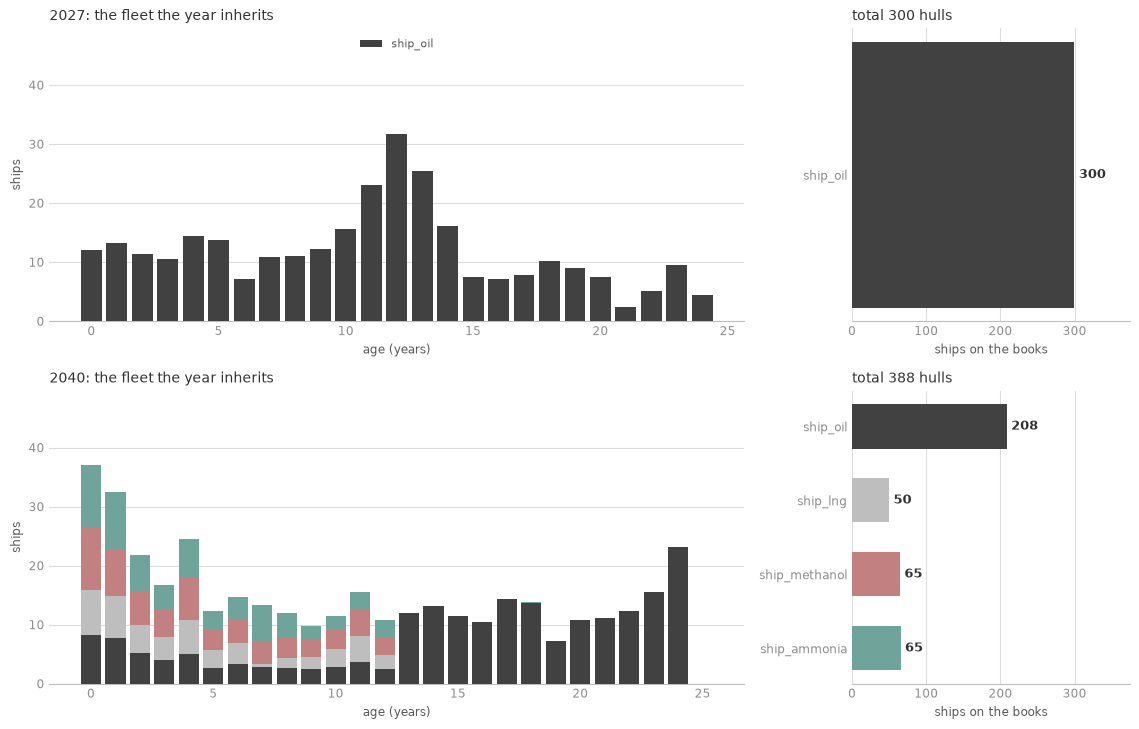

In [29]:
# Stage 0, both years. Same function, same scale: what the year inherits.
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4),
                         gridspec_kw={"width_ratios": [2.5, 1]})
for row, step in enumerate((STEP_EARLY, STEP_LATE)):
    draw_inherited(step, axes[row], scale_over=(STEP_EARLY, STEP_LATE), legend=row == 0)
fig.tight_layout()
plt.show()

### Stage 1 — Look ahead (2027 vs 2040)

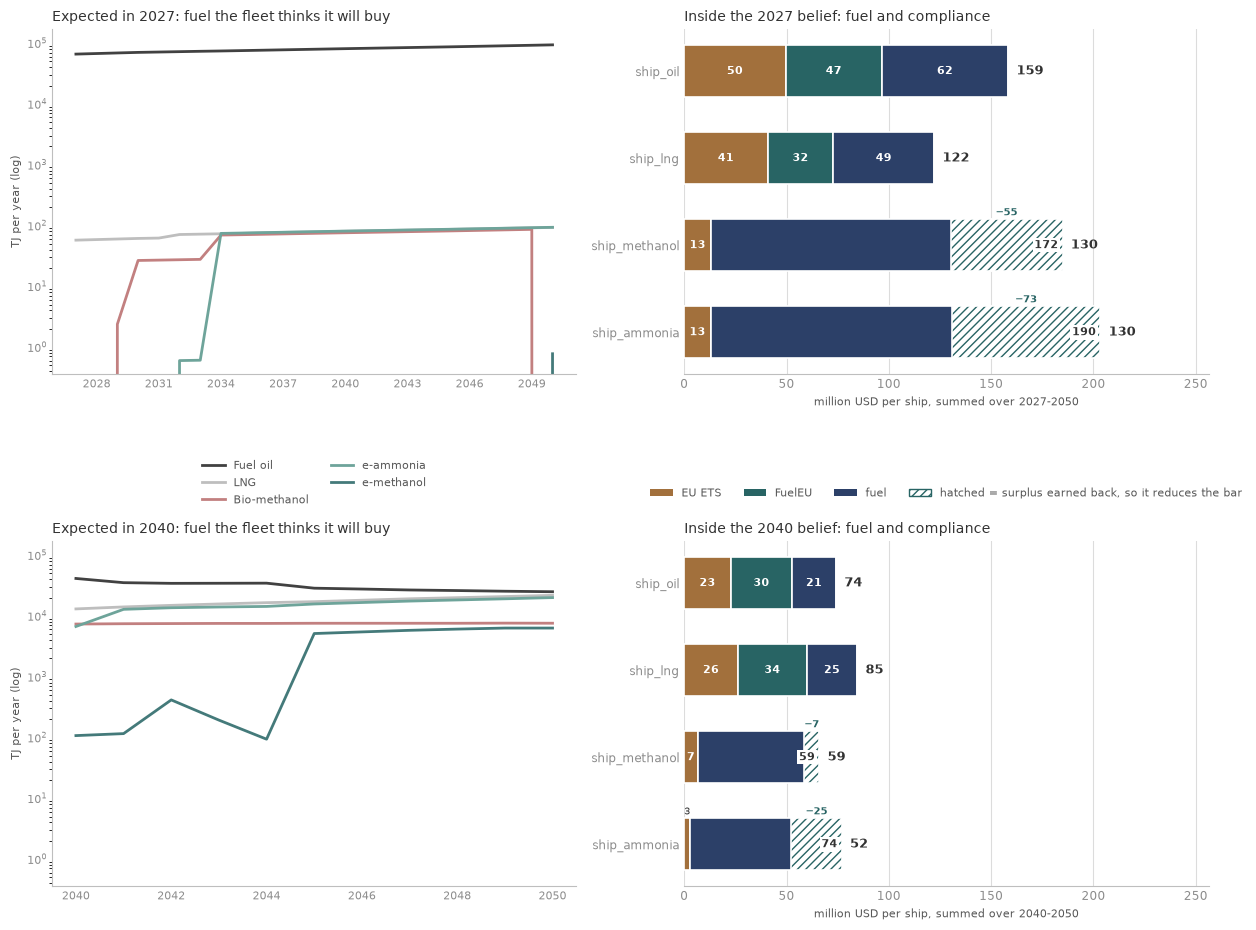

In [30]:
# Stage 1, both years. The look-ahead's two outputs - what it expects to buy,
# and what it expects that to cost.
fig, axes = plt.subplots(2, 2, figsize=(13, 9.4))
for row, step in enumerate((STEP_EARLY, STEP_LATE)):
    draw_expected_demand(step, axes[row][0], scale_over=(STEP_EARLY, STEP_LATE),
                         legend=row == 0)
    plot_believed_bill(step, ax=axes[row][1])
    axes[row][1].set_title(f"Inside the {YEARS[step]} belief: fuel and compliance",
                           fontsize=10, color=INK, loc="left")
    if row and axes[row][1].get_legend() is not None:
        axes[row][1].get_legend().remove()

# plot_believed_bill scales to its own year, so put the two on one axis by hand.
# They are NOT the same window - 2027 sums 2027-2050 and 2040 sums 2040-2050 -
# and a shared scale is what makes that shorter bar read as a shorter horizon
# rather than as a saving.
_wide = max(axes[r][1].get_xlim()[1] for r in (0, 1))
for r in (0, 1):
    axes[r][1].set_xlim(0, _wide)

fig.tight_layout()
plt.show()

### Stage 2 — Decide (2027 vs 2040)

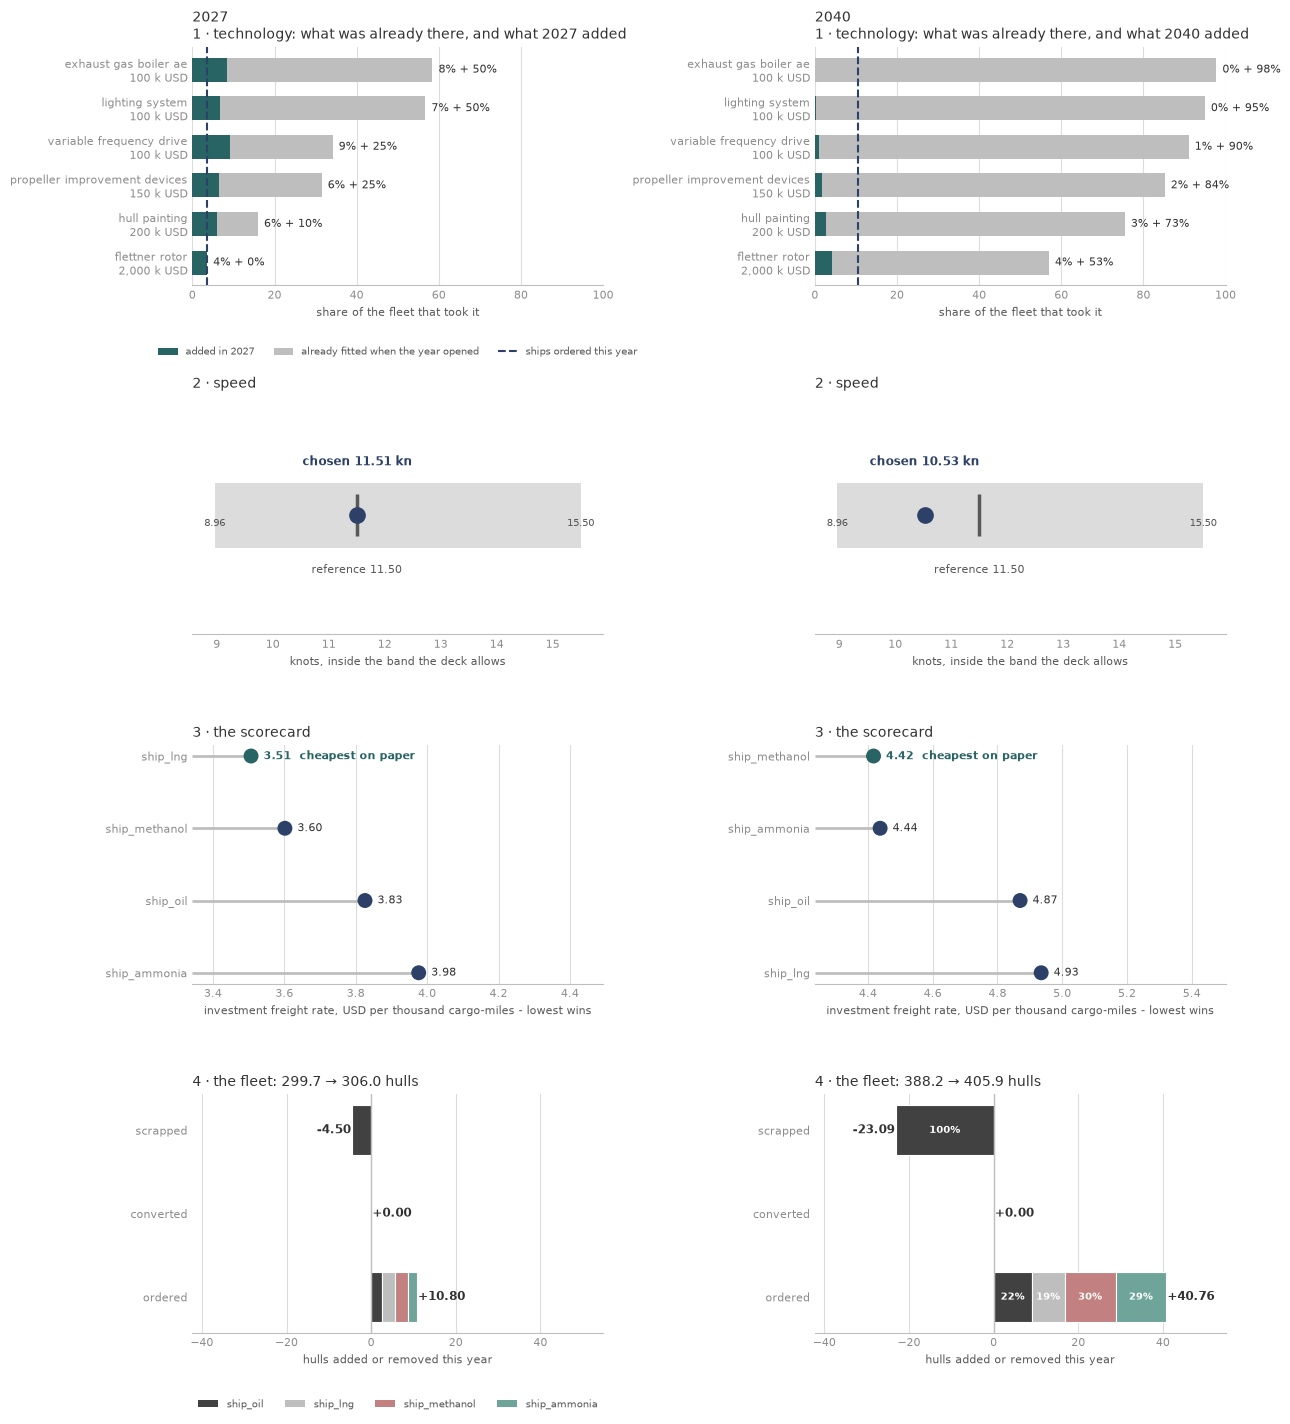

In [31]:
# Stage 2, both years. Four panels per year will not fit across one row, so here
# the YEAR IS THE COLUMN: 2027 on the left, 2040 on the right, each column in the
# same order as the 2×2 above - technology, speed, scorecard, fleet.
fig, axes = plt.subplots(4, 2, figsize=(13, 14.5))
for col, step in enumerate((STEP_EARLY, STEP_LATE)):
    draw_four_decisions(step, axes[:, col], scale_over=(STEP_EARLY, STEP_LATE),
                        legend=col == 0)
    # get_title() returns the CENTRE title, which is empty here - every title in
    # this notebook is set loc="left" - so ask for the one that exists.
    axes[0][col].set_title(f"{YEARS[step]}\n" + axes[0][col].get_title(loc="left"),
                           fontsize=10, color=INK, loc="left")
fig.tight_layout(rect=(0, 0.01, 1, 1))
plt.show()

### Stage 3 — The producer decides too (2027 vs 2040)

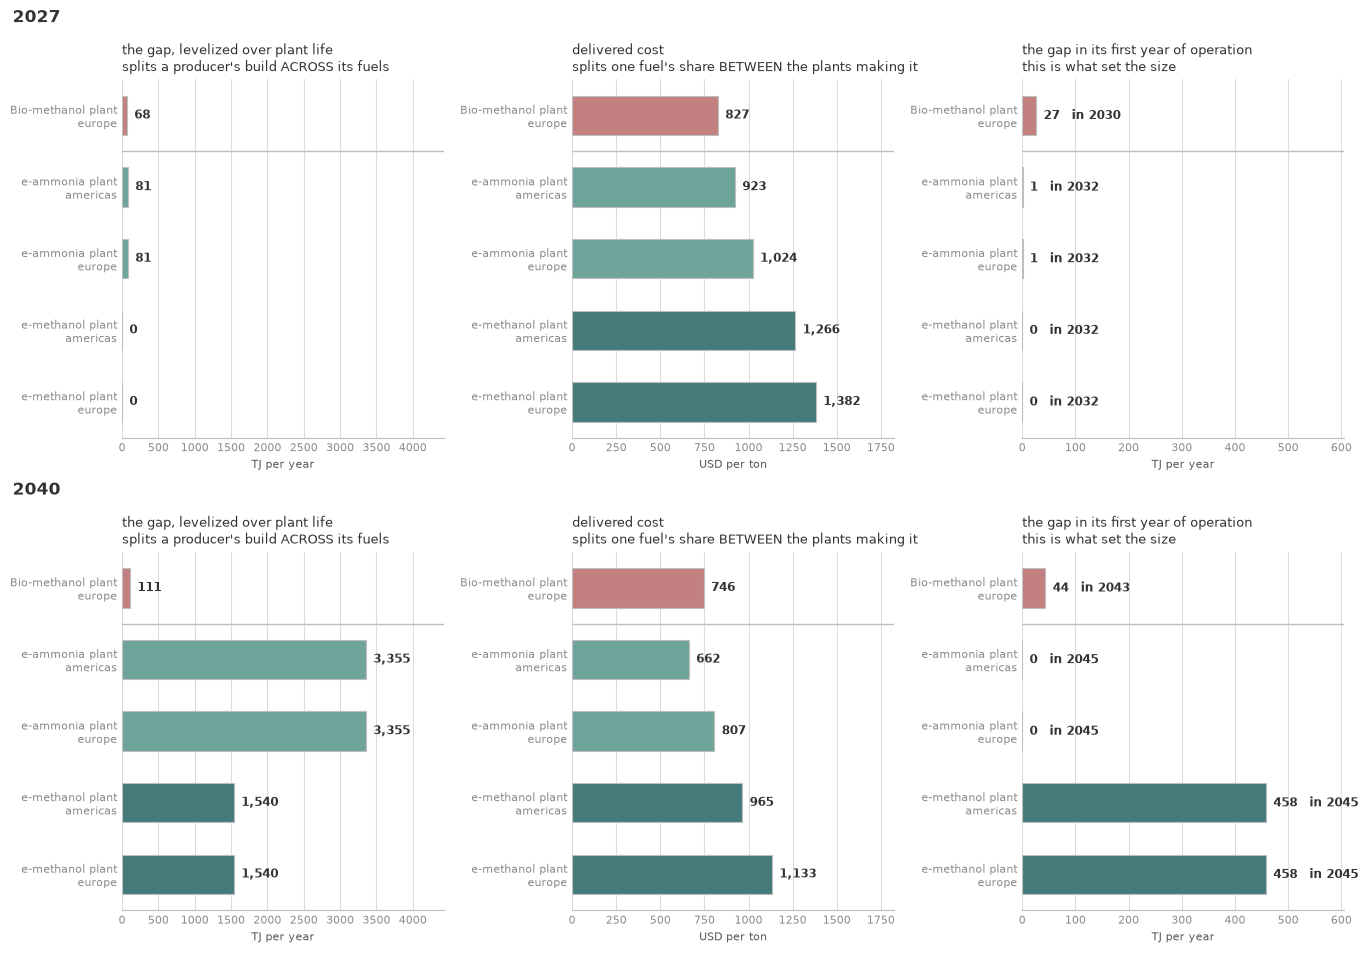

In [32]:
# Stage 3, both years. This is the one to read closely: the e-fuel producer owns
# two sites for each of its fuels, so the delivered-cost axis splits each fuel's
# build between them, and it has two fuels in demand, so the gap axis splits
# across those. The biofuel producer has one plant and one fuel, so both axes
# are flat for it.
fig, axes = plt.subplots(2, 3, figsize=(13.8, 9.6))
for row, step in enumerate((STEP_EARLY, STEP_LATE)):
    draw_producer_axes(step, axes[row], scale_over=(STEP_EARLY, STEP_LATE))
    axes[row][0].annotate(str(YEARS[step]), (-0.34, 1.16), xycoords="axes fraction",
                          fontsize=12, color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

### Stage 4 — Commit: the bunkering algorithm that binds (2027 vs 2040)

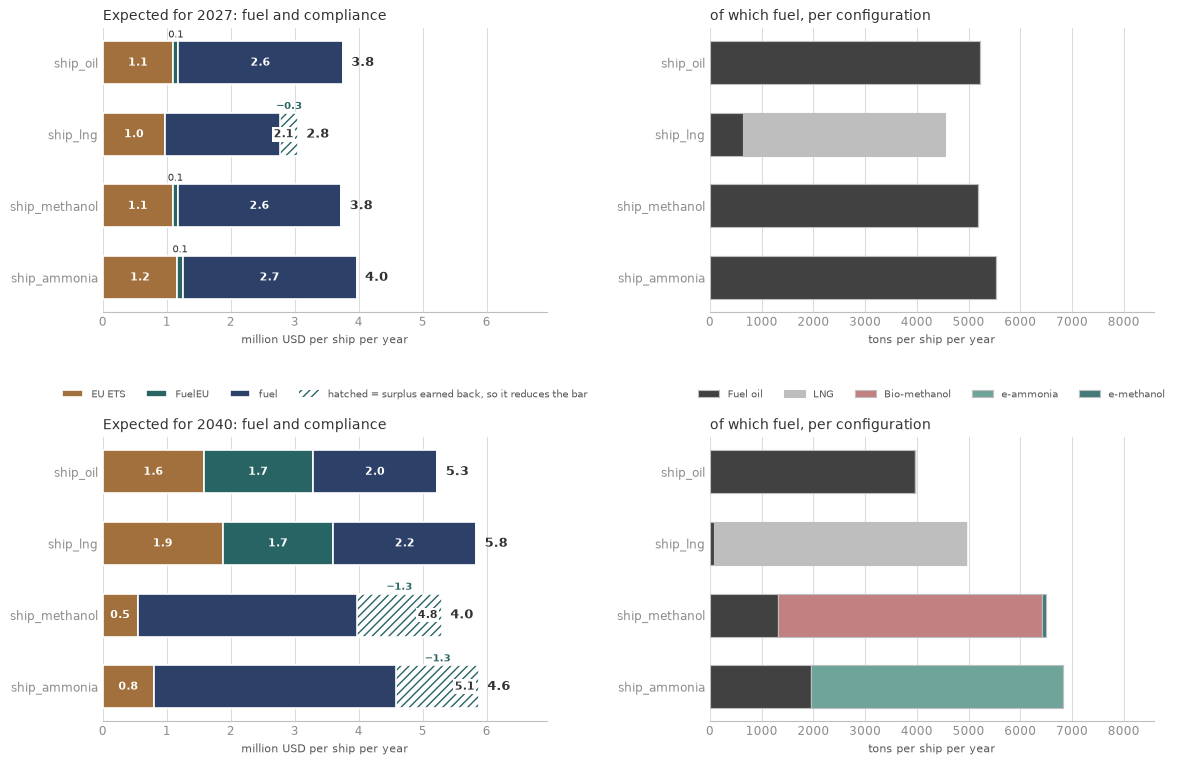

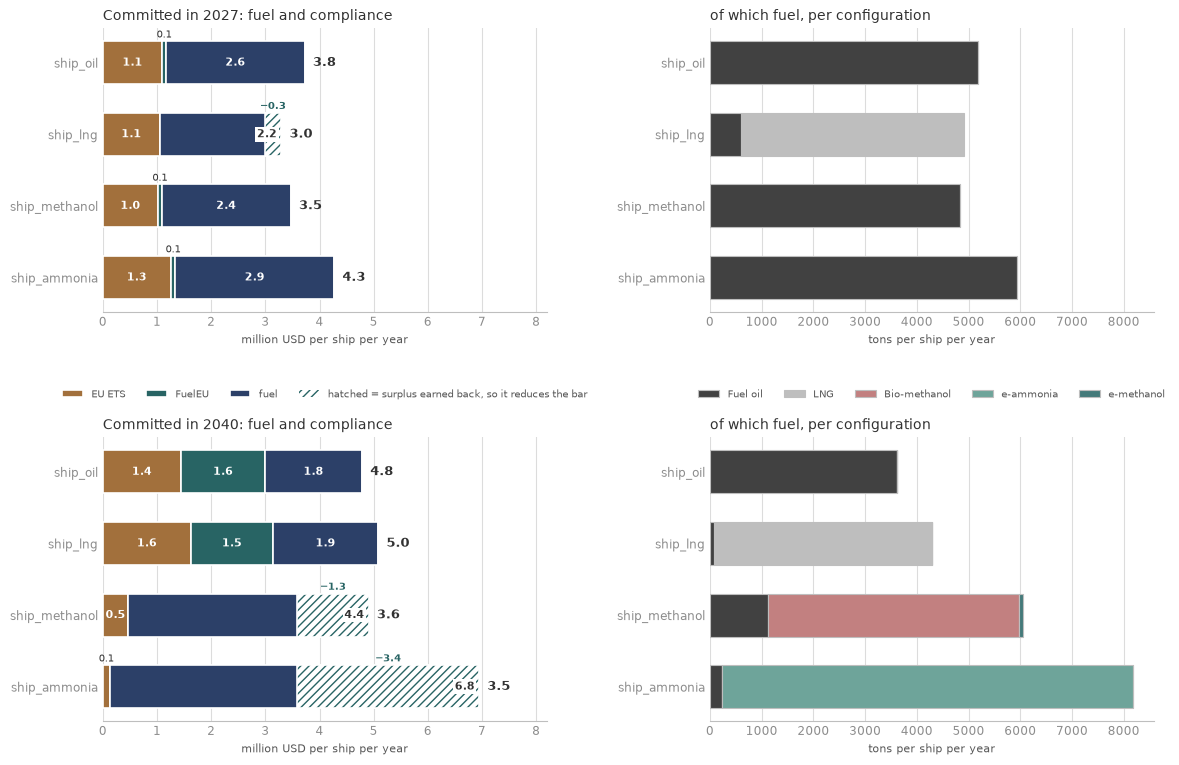

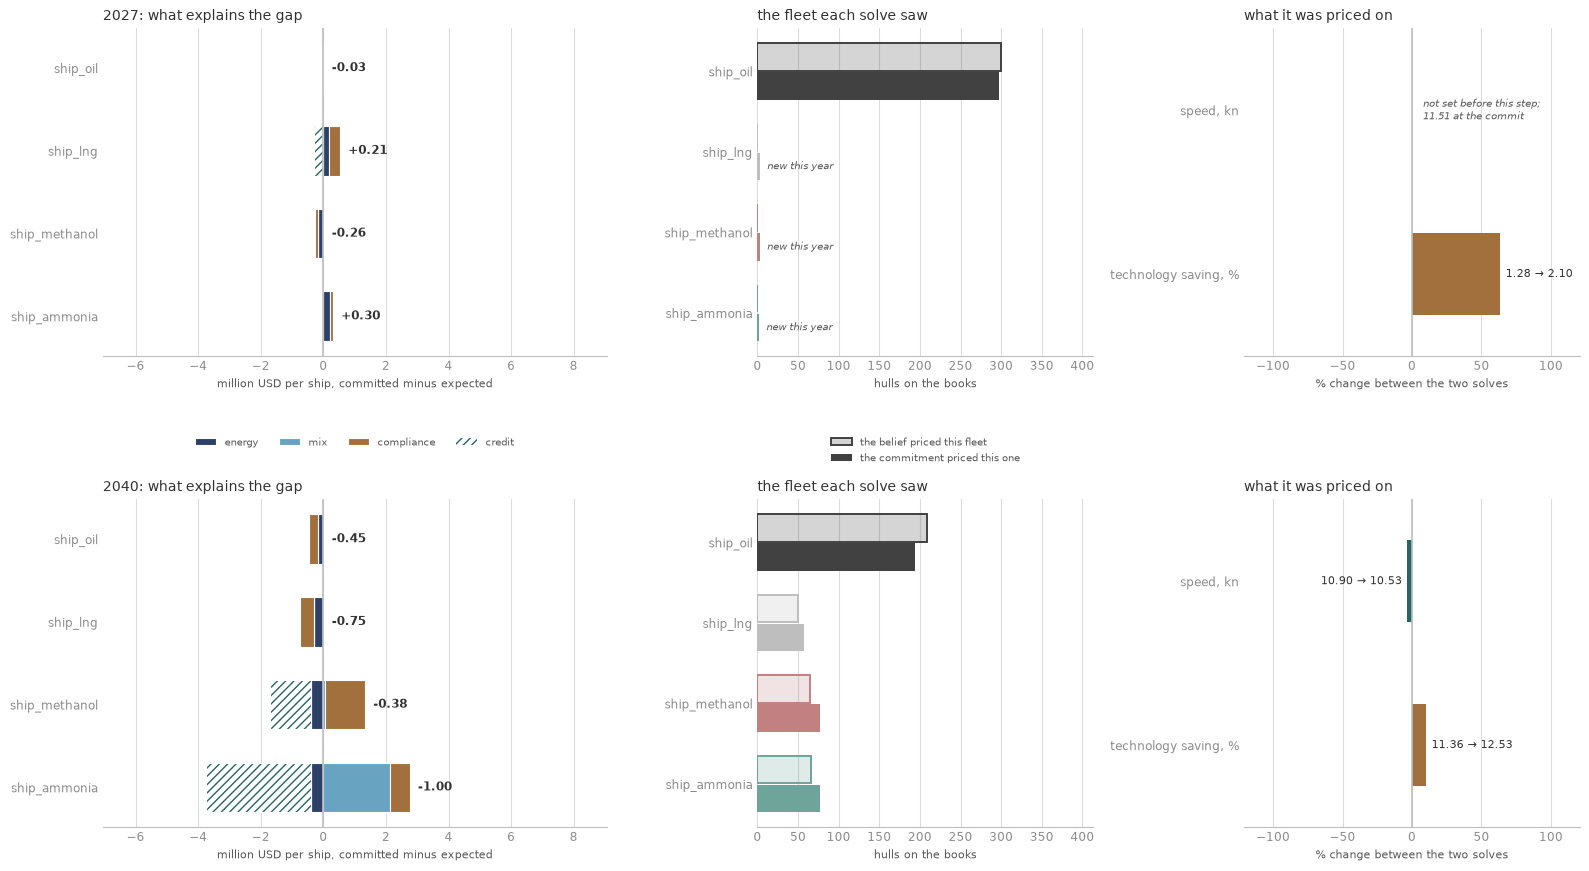

In [33]:
# Stage 4, both years: what was committed, then what had been expected of the
# same year. Both pairs share one tons scale, across both years and both halves.
for drawer, what in ((plot_expected_bill, "expected"),
                     (plot_committed_bill, "committed")):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8.0))
    for row, step in enumerate((STEP_EARLY, STEP_LATE)):
        drawer(step, axes=axes[row], scale_over=(STEP_EARLY, STEP_LATE), legend=row == 0)
    # scale_over already put the TONS panels on one axis; the money panels size
    # themselves from their own year, so harmonise them here rather than
    # threading a second limit through the helper.
    _wide = max(axes[r][0].get_xlim()[1] for r in (0, 1))
    for r in (0, 1):
        axes[r][0].set_xlim(0, _wide)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()

# and why each year's outturn is not the belief it started from
fig, axes = plt.subplots(2, 3, figsize=(16, 9.0),
                         gridspec_kw={"width_ratios": [1.5, 1, 1]})
for row, step in enumerate((STEP_EARLY, STEP_LATE)):
    draw_belief_gap(step, axes[row], scale_over=(STEP_EARLY, STEP_LATE),
                    legend=row == 0)
fig.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()


Three conditions moved, and each stage answered differently.

**Efficiency spread across the fleet.** Every measure is on offer from the first
year, but in 2027 a saved GJ is worth too little to carry the dearer ones, so the
fleet buys only the cheap rungs. By 2040 the signal has roughly doubled and it has
climbed further up the ladder — the one condition that moved because energy got
dearer rather than because a price in the deck changed.

**The fleet slowed down.** In 2027 it sailed at its reference speed, seeing no
reason to do otherwise; by 2040 it is a knot below. Slow steaming is compliance
bought without buying anything, and it only becomes worth the lost cargo-miles
once the shadow price of energy is high enough.

**Conversion never fired.** Neither year converted a single hull: no cohort was
both in a retrofit cycle and worth converting. The fleet changed its fuel by
ordering and scrapping instead — 11 ships ordered in 2027 against 41 in 2040,
with scrapping rising from 4.5 to 23.

And the two instruments move apart rather than together. The ETS buys *fewer*
units in 2040 than in 2027 — 1.7 million against 2.5 — yet its bill still rises,
from 335 to 420 M USD, because the allowance price nearly doubles from 133 to
252 USD/ton. FuelEU moves the other way and much harder: **23 M USD in 2027
against 389 in 2040**, a seventeenfold rise, because its limit tightens from 89 to
63 gCO2eq/MJ faster than this fleet cleans up. The gap keeps widening — by 2050
FuelEU charges 640 M USD a year against the ETS's 449. The intensity cap, not
the carbon price, is what ends up biting.


---

## Now run all twenty-five

Nothing new is computed from here on. This is the same solve, read across all of
its time steps instead of one — the walkthrough above was two of the twenty-five
years this already contains.


## 1. What the fleet did

### What the fleet became, and how it got there

Two views of one thing: **what the fleet is** at each date, and **where each
configuration came from** — a hull the operator already owned, converted, or a
new one ordered.

Retrofits arrive in bursts rather than a trickle, and the bursts are the
mechanism showing through: Navigate does not average 300 ships into one
representative hull, it builds **one cohort per row of the age curve** and runs
a separate logit for each, scored on that cohort's own remaining life and its
own NPV.
`RetrofitFrequency` and `FuelConversionMinimumAge` then gate which cohorts are
asked at all, so in a given year only four or five of the twenty-five are
offered the choice.

The fleet grows from 300 hulls to roughly 490, because `TradeGrowth` is switched
on in `includes/fleet.inc` — about 2.2 % a year, easing to 1.4–1.5 % from 2030 — so an
order is no longer necessarily a replacement. What the growth does *not* change
is the mix: turn it off and the 2050 shares move by well under a percentage
point each.

fleet 300 -> 489 hulls;  over the horizon 477 ordered, 38 converted, 288 scrapped


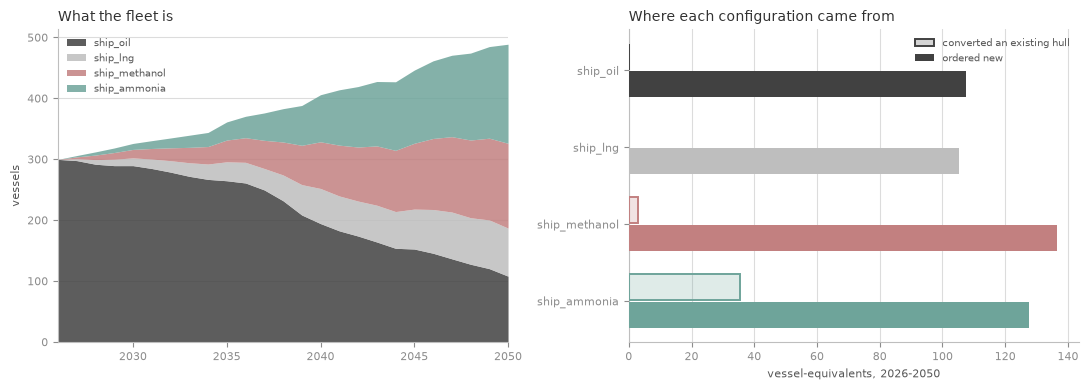

In [34]:
# One figure for the fleet: what it is at each date, and where each configuration
# came from.
from matplotlib.colors import to_rgba


def sum_over(d):
    """Sum a profile dict of per-vessel (or per-pair) series into one series."""
    return sum(np.nan_to_num(np.asarray(v, dtype=float)) for v in d.values())


hulls = pd.DataFrame({config_label(k): np.nan_to_num(np.asarray(v, dtype=float))
                      for k, v in copper_trade.profile.get_existing_vessels().items()},
                     index=YEARS)

# Where each configuration's hulls came from, summed over the horizon. A retrofit
# is credited to what the hull BECOMES, so both bars answer one question: how did
# this configuration get here?
arrived = {}
for (_from, _to), _series in copper_trade.profile.get_fuel_conversions().items():
    _total = float(np.nansum(_series))
    if _total > 1e-6:
        arrived.setdefault(_to, {"retrofitted": 0., "ordered": 0.})["retrofitted"] += _total
for _config, _series in copper_trade.profile.get_newbuilds().items():
    _total = float(np.nansum(_series))
    if _total > 1e-6:
        arrived.setdefault(_config, {"retrofitted": 0., "ordered": 0.})["ordered"] += _total
routes = pd.DataFrame(arrived).T.reindex([c for c in CONFIGS if c in arrived])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.0))

hulls.plot.area(ax=ax1, linewidth=0, alpha=0.85,
                color=[config_colour(c) for c in hulls.columns])
ax1.set_title("What the fleet is", fontsize=10, color=INK, loc="left")
ax1.set_ylabel("vessels", fontsize=8, color=SUBINK)
ax1.margins(x=0)
ax1.legend(fontsize=7, frameon=False, labelcolor=SUBINK, loc="upper left")

# Same grammar as the belief-vs-commitment figure in Stage 4: hollow for the
# route that reuses what is already there, solid for the one that buys new.
for i, name in enumerate(routes.index):
    ax2.barh(i - .18, routes.loc[name, "retrofitted"], height=.34,
             facecolor=to_rgba(config_colour(name), .22),
             edgecolor=config_colour(name), linewidth=1.4, zorder=3,
             label="converted an existing hull" if i == 0 else None)
    ax2.barh(i + .18, routes.loc[name, "ordered"], height=.34,
             color=config_colour(name), zorder=3,
             label="ordered new" if i == 0 else None)
ax2.set_yticks(list(range(len(routes))), [config_label(n) for n in routes.index])
ax2.invert_yaxis()
ax2.set_title("Where each configuration came from", fontsize=10, color=INK, loc="left")
ax2.set_xlabel(f"vessel-equivalents, {YEARS[0]}-{YEARS[-1]}", fontsize=8, color=SUBINK)
ax2.legend(fontsize=7, frameon=False, labelcolor=SUBINK)

for ax in (ax1, ax2):
    ax.grid(axis="y" if ax is ax1 else "x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

fig.tight_layout()

_total = hulls.sum(axis=1)
_scrapped = float(np.nansum(sum_over(copper_trade.profile.get_scrap())))
print(f"fleet {_total.iloc[0]:.0f} -> {_total.iloc[-1]:.0f} hulls;  over the horizon "
      f"{routes['ordered'].sum():.0f} ordered, {routes['retrofitted'].sum():.0f} "
      f"converted, {_scrapped:.0f} scrapped")
plt.show()

### Energy efficiency over the horizon

Switching fuel and slowing down are not the only ways to cut emissions. The
third is to need less energy for the same voyage. Part 2 lists the six measures
this deck offers and what each one costs; this is when the model actually fitted
them. What they turn out to be worth is a Part 4 question.

technology energy saving:  2026  1.3%   2038 10.8%   2050 17.1%


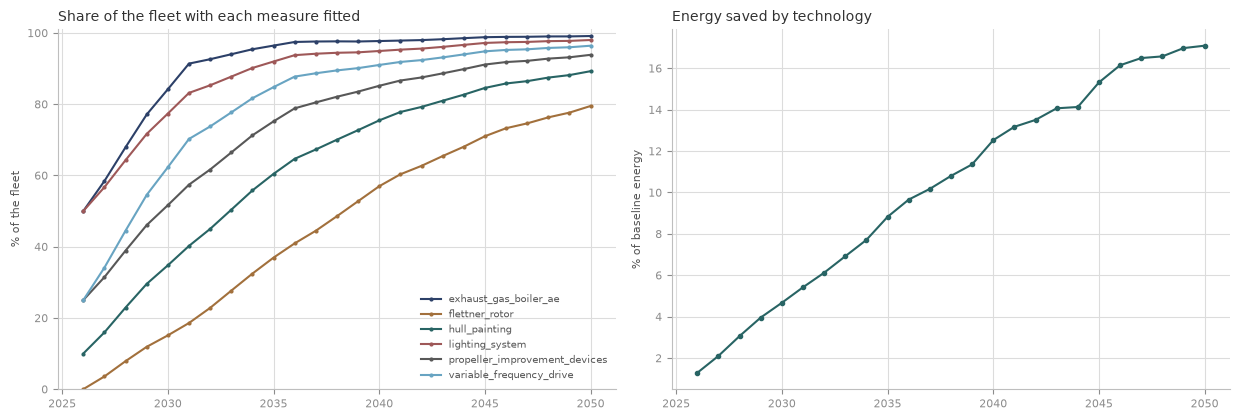

In [35]:
# What got fitted, and when.
#
# get_technology_uptake() is keyed by (vessel, technology) and each entry is that
# CONFIGURATION's share, so adding them up gives a number that runs to 4.0 on a
# four-configuration fleet and is not a share of anything. The library already
# does this properly: get_fleet_technology_uptake() weights each configuration by
# how many hulls it has, which is bounded by 1 - and is what Navigate's own
# technology_uptake plot draws, with ylim [0, 1.01].
fitted = pd.DataFrame({str(k).replace("_bulk_carrier_panamax", ""):
                       100. * np.nan_to_num(np.asarray(v, dtype=float))
                       for k, v in
                       copper_trade.profile.get_fleet_technology_uptake().items()},
                      index=YEARS)
fitted = fitted.loc[:, fitted.max() > 1e-4]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

fitted.plot(ax=ax1, marker=".", ms=4, color=series_colours(fitted.columns))
ax1.set_title("Share of the fleet with each measure fitted", fontsize=10, color=INK,
              loc="left")
ax1.set_ylabel("% of the fleet", fontsize=8, color=SUBINK)
ax1.set_ylim(0, 101)
ax1.legend(fontsize=7, frameon=False, labelcolor=SUBINK)

saving = np.nan_to_num(copper_trade.profile.get_technology_energy_intensity_saving()) * 100
ax2.plot(YEARS, saving, marker="o", ms=3, color=GREEN)
ax2.set_title("Energy saved by technology", fontsize=10, color=INK, loc="left")
ax2.set_ylabel("% of baseline energy", fontsize=8, color=SUBINK)

for ax in (ax1, ax2):
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

fig.tight_layout()

print(f"technology energy saving:  {YEARS[0]} {saving[0]:4.1f}%"
      f"   {YEARS[len(YEARS) // 2]} {saving[len(saving) // 2]:4.1f}%"
      f"   {YEARS[-1]} {saving[-1]:4.1f}%")
plt.show()


## 2. What the fuels did

### What it bunkers, and when

The headline result, and the question the case opened with. Shares of energy,
not of hulls — a dual-fuel ship that bunkers oil counts as oil here.


Share of total energy over 2026-2050:
  Fuel oil                    67.0%
  LNG                         11.7%
  Bio-methanol                 7.7%
  e-ammonia                   11.3%
  e-methanol                   2.3%


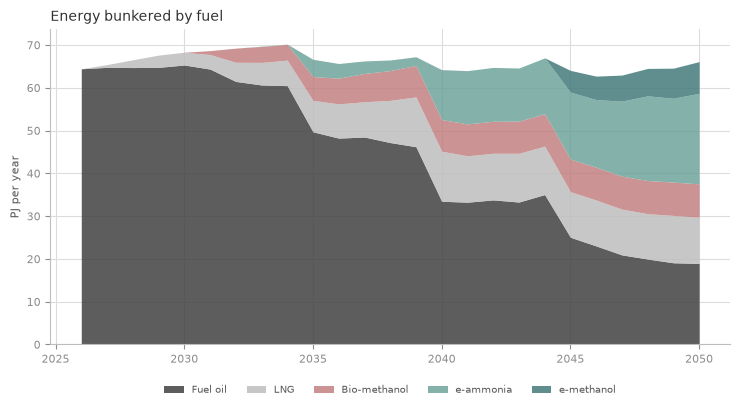

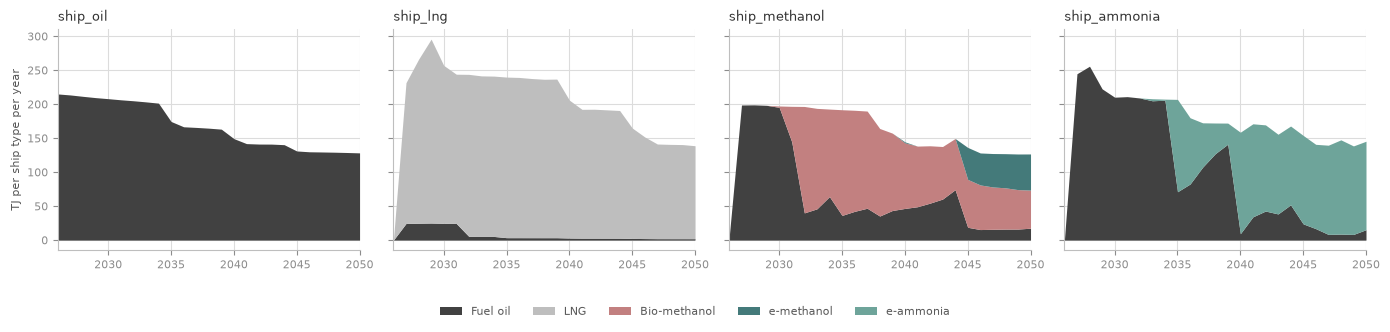

In [36]:
fuels = fuel_frame(base)
fuels = fuels[fuel_sorted(fuels.columns)]      # Navigate's own stacking order
_fc = [fuel_colour(f) for f in fuels.columns]
# fuel_frame is in GJ; PJ keeps the axis to two digits, as the producer panels use
_show = (fuels / 1e6).rename(columns=fuel_label)   # "Bio-methanol", not "methanol_bio"

fig, ax1 = plt.subplots(figsize=(7.5, 4.2))

_show.plot.area(ax=ax1, linewidth=0, alpha=0.85, color=_fc)
ax1.set_title("Energy bunkered by fuel", fontsize=10, color=INK, loc="left")
ax1.set_ylabel("PJ per year", fontsize=8, color=SUBINK)
ax1.legend(fontsize=7, frameon=False, labelcolor=SUBINK, ncol=5,
           loc="upper center", bbox_to_anchor=(0.5, -0.10))
ax1.grid(color=GRID, lw=0.8)
ax1.set_axisbelow(True)
ax1.tick_params(colors=TICK, labelsize=8)
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax1.spines[side].set_color(AXIS)

fig.tight_layout()

print("Share of total energy over 2026-2050:")
energy_share = (fuels.sum() / fuels.sum().sum() * 100).round(1)
for k, v in energy_share.items():
    print(f"  {fuel_label(k):26} {v:5.1f}%")
plt.show()


# The fleet view above hides which HULL burned what, and that is what explains the
# compliance bills in Stage 1: a methanol ship that cannot get methanol burns oil and
# pays for it. One panel per configuration, in Navigate's own fuel colours.
#
# Note this is what was actually bunkered, not what the look-ahead expected. Navigate
# resets the expected-bunkering accumulator on every forward solve, so the expectation
# is only ever the latest year - the realised series is the one that can be read back.
from navigate.illustrations.plots._labels import FUEL_ORDER

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(14, 3.2), sharey=True)

for ax, name in zip(axes, CONFIGS):
    consumed = base.nodes.vessels[name].profile.get_consumed_energy()
    frame = pd.DataFrame({f: np.nan_to_num(np.asarray(v, dtype=float))
                          for f, v in consumed.items()}, index=YEARS)
    frame = frame.loc[:, frame.sum() > 0]
    order = [f for f in FUEL_ORDER if f in frame.columns]

    bottom = np.zeros(len(frame))
    for fuel in order:
        values = frame[fuel].to_numpy() / 1e3
        ax.fill_between(YEARS, bottom, bottom + values, color=fuel_colour(fuel),
                        label=fuel_label(fuel), linewidth=0)
        bottom += values

    ax.set_title(name, fontsize=9.5, color=INK, loc="left")
    ax.set_xlabel("")
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    ax.margins(x=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

axes[0].set_ylabel("TJ per ship type per year", fontsize=8, color=SUBINK)

# one legend for the four panels, listing every fuel that appears in any of them
seen = {}
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        seen.setdefault(label, handle)
fig.legend(seen.values(), seen.keys(), fontsize=8, frameon=False, labelcolor=SUBINK,
           ncol=len(seen), loc="lower center", bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

### What the feedstock ceilings decided

Part 2 drew these two ceilings as the deck sets them. Here they are again with
what the run actually drew against them, which is what settles whether a ceiling
was ever more than a line on a chart.

The two bite very differently: biomass runs short from 2038 and stays short, so
it shapes the second half of the horizon, while biogenic CO2 only catches up with the plants
drawing on it in the last years. A ceiling matters where the line meets it, not
because it is there.


  Gasification feedstock     ceiling  0.95 Mt/yr by 2050,   binds from 2038, in 13 of 25 years
  Biogenic CO2 (PS)          ceiling  0.53 Mt/yr by 2050,   binds from 2049, in 2 of 25 years


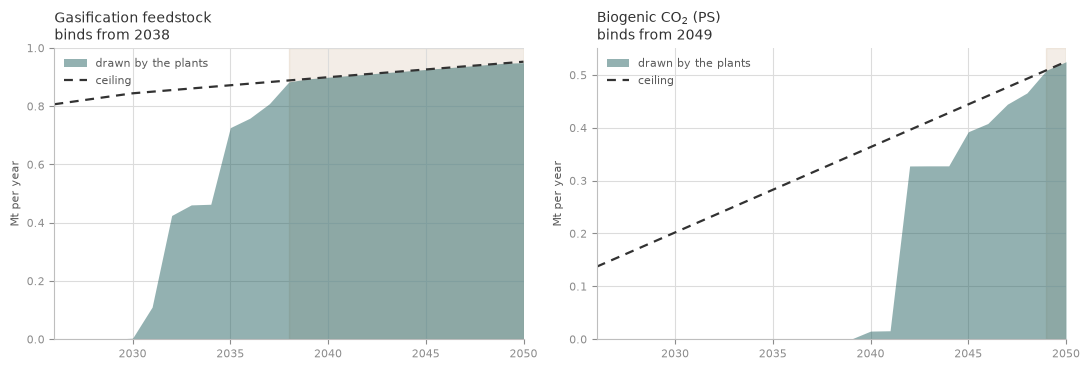

In [37]:
# The same two ceilings as Part 2, now against what the run drew. Consumption is
# a run output - the profile aggregates it, and each constrained feed has one
# producer in this deck, so the two line up. The ceilings are reused from
# CEILINGS rather than recomputed: they are deck inputs and have not moved.
DREW = []
for _c in CEILINGS:
    _drawn = np.nan_to_num(np.asarray(
        base.profile.get_feed_mass(_c["feed"]), dtype=float)) / 1e6
    _tight = _drawn >= 0.99 * _c["cap"]
    DREW.append({**_c, "drawn": _drawn, "tight": _tight,
                 "from": int(YEARS[_tight][0]) if _tight.any() else None,
                 "count": int(_tight.sum()),
                 "peak": float(np.nanmax(_drawn / _c["cap"]))})

fig, axes = plt.subplots(1, len(DREW), figsize=(11, 3.8), sharex=True)

for ax, c in zip(np.atleast_1d(axes), DREW):
    ax.fill_between(YEARS, 0., c["drawn"], color=GREEN, alpha=.5, linewidth=0,
                    label="drawn by the plants")
    ax.plot(YEARS, c["cap"], color=INK, lw=1.6, ls=(0, (4, 3)), label="ceiling")
    if c["from"]:
        # the years the ceiling, rather than the price, is deciding
        ax.axvspan(c["from"], YEARS[-1], color=ORANGE, alpha=.12, zorder=0)
        head = f"binds from {c['from']}"
    else:
        head = f"never binds \u2014 peak {100 * c['peak']:.0f}% of it"
    ax.set_title(f"{FEEDSTOCK_LABEL.get(c['feed'], c['feed'])}\n{head}",
                 fontsize=10, color=INK, loc="left")
    ax.set_ylabel("Mt per year", fontsize=8, color=SUBINK)
    ax.set_ylim(bottom=0.)
    ax.margins(x=0)
    ax.legend(fontsize=8, frameon=False, labelcolor=SUBINK, loc="upper left")
    ax.grid(color=GRID, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for _side in ("top", "right"):
        ax.spines[_side].set_visible(False)
    for _side in ("left", "bottom"):
        ax.spines[_side].set_color(AXIS)

fig.tight_layout()

for c in DREW:
    _name = FEEDSTOCK_LABEL.get(c["feed"], c["feed"]).replace("$_2$", "2").replace("$", "")
    _when = (f"binds from {c['from']}, in {c['count']} of {len(YEARS)} years"
             if c["from"] else
             f"never binds, peak draw {100 * c['peak']:.0f}% of it")
    print(f"  {_name:26} ceiling {c['cap'][-1]:5.2f} Mt/yr by {YEARS[-1]},"
          f"   {_when}")
plt.show()

### What the producers sanctioned, and the lag before it arrives

Stage 3 showed the two axes a producer chooses on, for one year. This is what
those choices added up to over the horizon — and what the fleet could actually
burn as a result.

The two actors never talk to each other. They read and write shared state: the
operator's expected bunkering **is** the producer's order book, and the
producer's output **is** the supply the operator can buy. The lag is deliberate.
The demand figure a producer acts on is the fleet's expectation computed earlier
in the same time step, before that year's newbuild and retrofit decisions, and
the plant's build lead time comes on top of that.

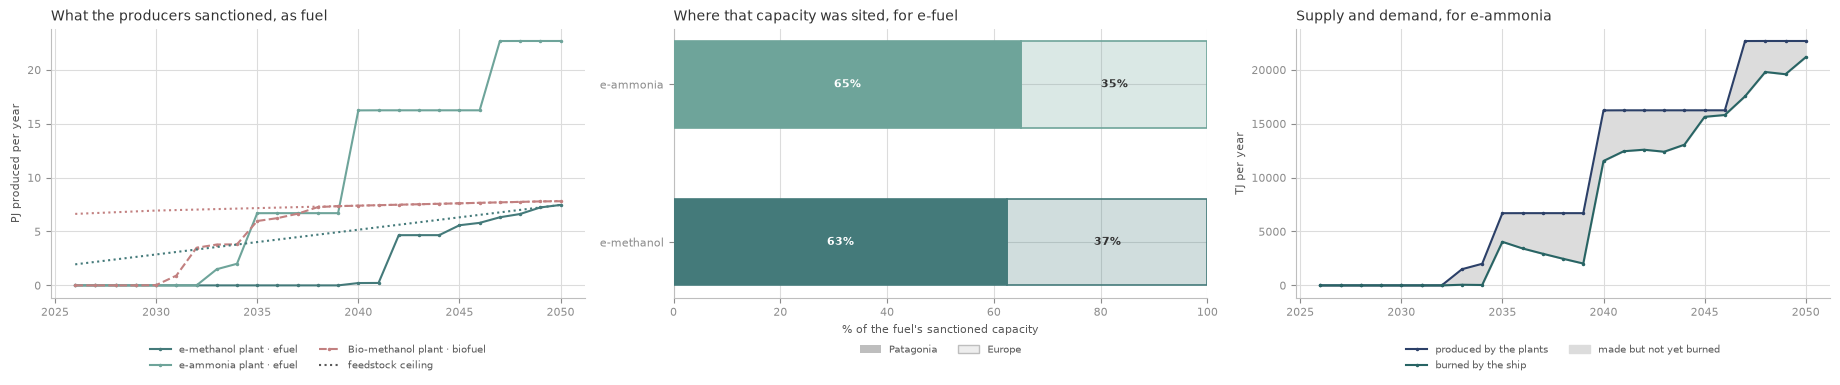

  first capacity sanctioned: 2028
  first e-ammonia burned:  2032
  production vs delivery, largest gap over the horizon: 0.0 TJ/year

The e-fuel producer owns both sites for each of its fuels, so it splits
its build between them on delivered cost instead of picking one.


In [38]:
FUEL = "ammonia_electro"        # the largest e-fuel in the baseline; the others behave the same

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18.5, 4.2))

# What those sanctions actually produce. A plant COUNT is not comparable across
# fuels or across years: an ammonia plant and a methanol plant are different
# sizes, and the library's capacity forecast grows over the horizon, so a plant
# built in 2030 is smaller than one built in 2040. Energy is the common unit, and
# get_production_energy is the model's own number rather than count x capacity.
# Colour is the fuel, so two plants making it share one - the region is the dash.
for _producer in base.nodes.producers.values():
    for _fuel, _series in _producer.profile.get_production_energy().items():
        _made = np.nan_to_num(np.asarray(_series, dtype=float)) / 1e6
        if _made.max() <= 0:
            continue
        ax1.plot(YEARS, _made, marker=".", ms=3, color=fuel_colour(_fuel),
                 ls="-" if "efuel" in _producer.get_name() else "--",
                 label=f"{fuel_label(_fuel)} plant \u00b7 "
                       f"{_producer.get_name().replace('producer_', '')}")
ax1.set_title("What the producers sanctioned, as fuel", fontsize=10, color=INK,
              loc="left")
ax1.set_ylabel("PJ produced per year", fontsize=8, color=SUBINK)

# The feedstock ceilings, drawn as the most fuel they allow. A Conversions entry
# is tons of feed per ton of fuel, so the ceiling over it, times the heating
# value, is the production that ceiling caps. Only a ceiling production actually
# comes near is drawn: e-ammonia has no constrained feed at all, and one sitting
# far above its fuel says nothing and flattens everything else into the floor.
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

NEAR = 0.5          # near enough to draw: production reaches half of it


def _resolve(node, when):
    """A deck number that may be a Forecast, an Expression or a plain value."""
    if hasattr(node, "calculate"):
        return float(node.calculate(when))
    try:
        return float(node.get(when))
    except TypeError:
        return float(node.get())


_days = base.get_timeline()
_drew_ceiling = False
for _producer in base.nodes.producers.values():
    for _feed, _node in _producer.feed_constraints.items():
        if _node is None:
            continue
        for _plant in _producer.get_plants():
            _names = [f.get_name() for f in _plant.process.feeds]
            if _feed not in _names:
                continue
            _fuel_name = _plant.fuel.get_name()
            _conv = _resolve(_plant.process.conversions[_names.index(_feed)], 0.)
            _lhv = float(_plant.fuel.lower_heating_value.get())
            _cap = np.array([_resolve(_node, _w) for _w in _days]) / _conv * _lhv / 1e6
            _drawn = np.nan_to_num(np.asarray(
                _producer.profile.get_production_energy(_fuel_name), dtype=float)) / 1e6
            if np.nanmax(_drawn / _cap) >= NEAR:
                ax1.plot(YEARS, _cap, ls=":", lw=1.5, zorder=2,
                         color=fuel_colour(_fuel_name))
                _drew_ceiling = True
            break          # the plants of one producer share the one ceiling

_h, _l = ax1.get_legend_handles_labels()
if _drew_ceiling:
    _h = _h + [Line2D([], [], ls=":", lw=1.5, color=SUBINK)]
    _l = _l + ["feedstock ceiling"]
ax1.legend(_h, _l, fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))

# ---- where that capacity was sited -----------------------------------------
# The producer owns two sites for each e-fuel and splits the build between them
# on delivered cost. This is that split, weighted by what was actually built
# each year and summed over the horizon. It is capacity sanctioned, not output:
# Navigate records production per (producer, fuel) and never per plant, so the
# realised split by region is not something the run can be asked for.
REGION_LABEL = {"americas": "Patagonia", "europe": "Europe"}
sited = {}
for _step in STEPS:
    for _pname, _assets, _share in snaps[_step].get("producer_uptake", []):
        _built = float(np.nan_to_num(np.asarray(
            base.nodes.producers[_pname].profile.get_development(), dtype=float))[_step])
        if _built <= 0:
            continue
        for _asset, _u in zip(_assets, _share):
            _seen = snaps[_step]["producer"].get(_asset)
            if _seen is None or _u <= 0:
                continue
            _plant = base.nodes.plants[_asset]
            _key = (_plant.fuel.get_name(), _plant.region.get_name())
            sited[_key] = sited.get(_key, 0.) + (
                _u * _built * _seen["plant_output"] * _seen["lhv"] / 1e3)

# Only a fuel the producer could have built in more than one place. Bio-methanol
# has just the one site, so its 100% is an artefact of there being no choice, not
# a decision the delivered-cost axis made.
_sited_fuels = fuel_sorted({f for f, _r in sited
                            if sum(v for (ff, _rr), v in sited.items() if ff == f) > 0
                            and len({r for ff, r in sited if ff == f}) > 1})
_sited_regions = sorted({r for _f, r in sited})
for _i, _f in enumerate(_sited_fuels):
    _tot = sum(v for (ff, _r), v in sited.items() if ff == _f)
    _left = 0.
    for _r in _sited_regions:
        _pct = 100. * sited.get((_f, _r), 0.) / _tot
        if _pct <= 0:
            continue
        _solid = _r == "americas"
        ax2.barh(_i, _pct, left=_left, height=.55, zorder=3,
                 facecolor=fuel_colour(_f) if _solid else to_rgba(fuel_colour(_f), .25),
                 edgecolor=fuel_colour(_f), linewidth=1.2)
        if _pct >= 12:
            ax2.annotate(f"{_pct:.0f}%", (_left + _pct / 2, _i), ha="center",
                         va="center", fontsize=8, fontweight="bold", zorder=5,
                         color="white" if _solid else INK)
        _left += _pct
ax2.set_yticks(range(len(_sited_fuels)), [fuel_label(f) for f in _sited_fuels])
ax2.invert_yaxis()
ax2.set_xlim(0, 100)
ax2.set_title("Where that capacity was sited, for e-fuel", fontsize=10,
              color=INK, loc="left")
ax2.set_xlabel("% of the fuel's sanctioned capacity", fontsize=8, color=SUBINK)
ax2.legend(handles=[Patch(facecolor=MUTED, label=REGION_LABEL["americas"]),
                    Patch(facecolor=to_rgba(MUTED, .25), edgecolor=MUTED,
                          label=REGION_LABEL["europe"])],
           fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))

# The lag, for one fuel: what the plants made, and what the ship burned. In a
# closed two-port system everything made is delivered - see the check printed
# below - so the bottleneck is never the port; it is the plant and its build
# lead time.
consumed = np.nan_to_num(np.asarray(
    copper_trade.profile.get_consumed_energy(FUEL), dtype=float))
produced = np.nan_to_num(np.asarray(
    sum(p.profile.get_production_energy(FUEL) for p in base.nodes.producers.values()
        if p.can_produce(FUEL)), dtype=float))
supply = np.nan_to_num(np.asarray(
    sum(port.profile.get_bunker_supply_energy(FUEL) for port in base.nodes.ports.values()),
    dtype=float))

ax3.plot(YEARS, produced / 1e3, label="produced by the plants",
         marker=".", ms=3, color=BLUE)
ax3.plot(YEARS, consumed / 1e3, label="burned by the ship",
         marker=".", ms=3, color=GREEN)
ax3.fill_between(YEARS, consumed / 1e3, produced / 1e3, color=PALE, zorder=0,
                 label="made but not yet burned")
ax3.set_title(f"Supply and demand, for {fuel_label(FUEL)}", fontsize=10, color=INK,
              loc="left")
ax3.set_ylabel("TJ per year", fontsize=8, color=SUBINK)
ax3.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=2,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))

for ax in (ax1, ax2, ax3):
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

# the lag, as two dates rather than a shape
_first_burn = next((y for y, c in zip(YEARS, consumed) if c > 0), None)
_dev = [np.nan_to_num(np.asarray(p.profile.get_cumulative_development(), dtype=float))
        for p in base.nodes.producers.values() if p.can_produce(FUEL)]
_sanctioned = sum(_dev) if _dev else np.zeros(len(YEARS))
_first_plant = next((y for y, d in zip(YEARS, _sanctioned) if d > 0), None)
print(f"  first capacity sanctioned: {_first_plant}")
print(f"  first {fuel_label(FUEL)} burned:  {_first_burn}")
print(f"  production vs delivery, largest gap over the horizon: "
      f"{np.max(np.abs(supply - produced)) / 1e3:,.1f} TJ/year")
print()
print("The e-fuel producer owns both sites for each of its fuels, so it splits")
print("its build between them on delivered cost instead of picking one.")

## 3. What the regulations did

Both schemes have been charging the fleet all along. The first panel is the
one that decides it: where each configuration's blended intensity sits
against the FuelEU limit, on green ground where it earns surplus and red
where it buys compliance.

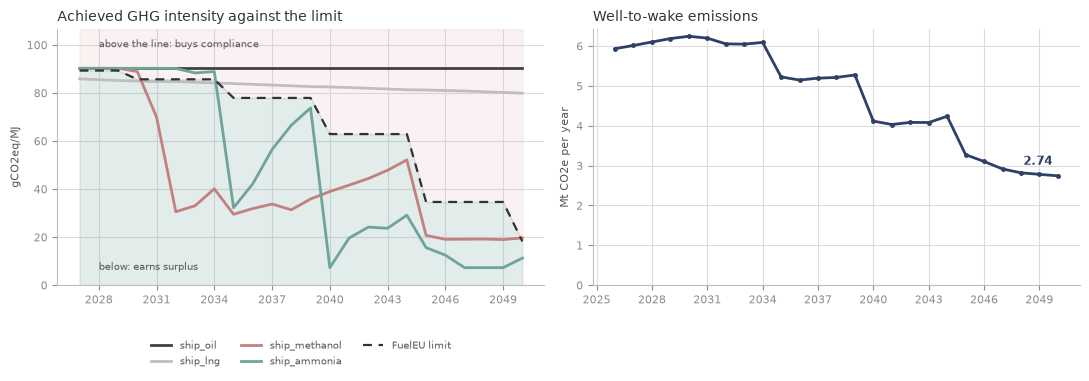

  well-to-wake 2026:    5.93 Mt/yr   2050:    2.74 Mt/yr   over the horizon     119.1 Mt
  EU ETS   2027:     335 M USD   2050:     449 M USD   over the horizon    10,514 M USD
  FuelEU   2027:      23 M USD   2050:     640 M USD   over the horizon     6,172 M USD
  ship_oil        below the limit in  0 of 24 years
  ship_lng        below the limit in  8 of 24 years
  ship_methanol   below the limit in 19 of 24 years
  ship_ammonia    below the limit in 16 of 24 years


In [39]:
# The compliance panel borrows regulation_compliance.py's colours - COMPLIANT
# and BREACH are that module's own green and red - but not its shading. The
# library splits each measured value at the threshold and stacks the two halves;
# here the GROUND is shaded instead, so four hulls can be drawn over it and
# compared. Beside it, the emissions the fleet ends up with - the line the whole
# compliance story is trying to bend.
from matplotlib.ticker import MaxNLocator
# status colours, imported here rather than in Part 2's setup cell so this
# section stays self-contained
from _style import BREACH, COMPLIANT

fuel_eu = base.nodes.regulations["fuel_eu"]
eu_ets = base.nodes.regulations["eu_ets"]


def whole(getter):
    return np.nan_to_num(np.asarray(getter(), dtype=float))


# step 0 takes no decisions, so compliance is not computed there - start at the
# first year that has one, or the lines drop to zero and the axis follows them
live = slice(1, None)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

# ---- 1. over and under the limit -------------------------------------------
# FuelEU credits the fuel actually burned, not the hull's capability, so what
# matters is the BLENDED intensity each configuration achieves.
limit = whole(fuel_eu.profile.get_shared_threshold)
achieved = fuel_eu.profile.get_vessel_compliance()
_top = max(limit[live].max(),
           max(whole(lambda n=n: achieved[n])[live].max() for n in CONFIGS)) * 1.18

# the ground, as the library shades it: compliant below the threshold, breach above
axL.fill_between(YEARS[live], 0., limit[live], color=COMPLIANT, alpha=.20, zorder=1)
axL.fill_between(YEARS[live], limit[live], _top, color=BREACH, alpha=.14, zorder=1)
for name in CONFIGS:
    axL.plot(YEARS[live], whole(lambda n=name: achieved[n])[live], lw=2,
             color=config_colour(name), label=config_label(name), zorder=3)
axL.plot(YEARS[live], limit[live], lw=1.6, ls=(0, (4, 3)), color=INK,
         label="FuelEU limit", zorder=4)
axL.annotate("above the line: buys compliance", (YEARS[2], _top * .93),
             fontsize=7.5, color=SUBINK)
axL.annotate("below: earns surplus", (YEARS[2], _top * .06), fontsize=7.5,
             color=SUBINK)
axL.set_title("Achieved GHG intensity against the limit", fontsize=10, color=INK,
              loc="left")
axL.set_ylabel("gCO2eq/MJ", fontsize=8, color=SUBINK)
axL.set_ylim(0, _top)
axL.legend(fontsize=7.5, frameon=False, labelcolor=SUBINK, ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, -0.18))

# ---- 2. what it all adds up to ---------------------------------------------
# The same series notebook 5 plots for the whole world fleet, here for one
# trade: WELL-TO-WAKE, so how each fuel was made counts too, not just the
# funnel. Every lever in Part 4 is ultimately aimed at this line.
# Mt, not kt: get_best_unit_mass picks Mt/year at this fleet's magnitude, so
# fleet_emission_absolute.py would label it the same way. Part 4 below reports
# the same quantity in kt, where a one-per-cent change still has to be legible.
_wtw = whole(copper_trade.profile.get_total_equivalent_WTW) / 1e6
axR.plot(YEARS, _wtw, lw=2, marker=".", ms=5, color=BLUE)
axR.annotate(f"{_wtw[-1]:,.2f}", (YEARS[-1], _wtw[-1]), xytext=(-4, 8),
             textcoords="offset points", ha="right", fontsize=8.5,
             color=BLUE, fontweight="bold")
axR.set_title("Well-to-wake emissions", fontsize=10, color=INK, loc="left")
axR.set_ylabel("Mt CO2e per year", fontsize=8, color=SUBINK)
axR.set_ylim(bottom=0.)

for ax in (axL, axR):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

print(f"  {'well-to-wake':8} {YEARS[0]}: {_wtw[0]:7,.2f} Mt/yr   "
      f"{YEARS[-1]}: {_wtw[-1]:7,.2f} Mt/yr   "
      f"over the horizon {_wtw.sum():9,.1f} Mt")
for _name, _reg in (("EU ETS", eu_ets), ("FuelEU", fuel_eu)):
    _bill = (whole(_reg.profile.get_remedial_expenses)
             + whole(_reg.profile.get_flexibility_expenses)) / 1e6
    print(f"  {_name:8} {YEARS[1]}: {_bill[1]:7,.0f} M USD   "
          f"{YEARS[-1]}: {_bill[-1]:7,.0f} M USD   "
          f"over the horizon {_bill[live].sum():9,.0f} M USD")
for _name in CONFIGS:
    _under = int(np.sum(whole(lambda n=_name: achieved[n])[live] < limit[live]))
    print(f"  {_name:15} below the limit in {_under:2d} of {len(YEARS) - 1} years")

## 4. What the trade cost

The number a cargo owner actually feels. Two views, both in **USD per
thousand cargo-miles** - the unit Navigate's own plots use:

- The **instantaneous freight rate** on the fleet: what the trade cost in that
  year, given the fuel prices and compliance bills that actually materialised.
- The **investment freight rate** on each vessel configuration: the
  forward-looking, levelized cost of transport. This is the number the
  discrete-choice model compares between configurations, so it is what explains
  *why* one was picked. A configuration that is not in the fleet in a given year
  has no value and simply does not plot.

instantaneous freight rate   2026: 3.48   2050: 4.74   (+36%)

In the right-hand panel, whichever configuration sits lowest in a given
year is the one most likely to be ordered that year. That crossover is
the mechanism behind the fuel mix in section 2.


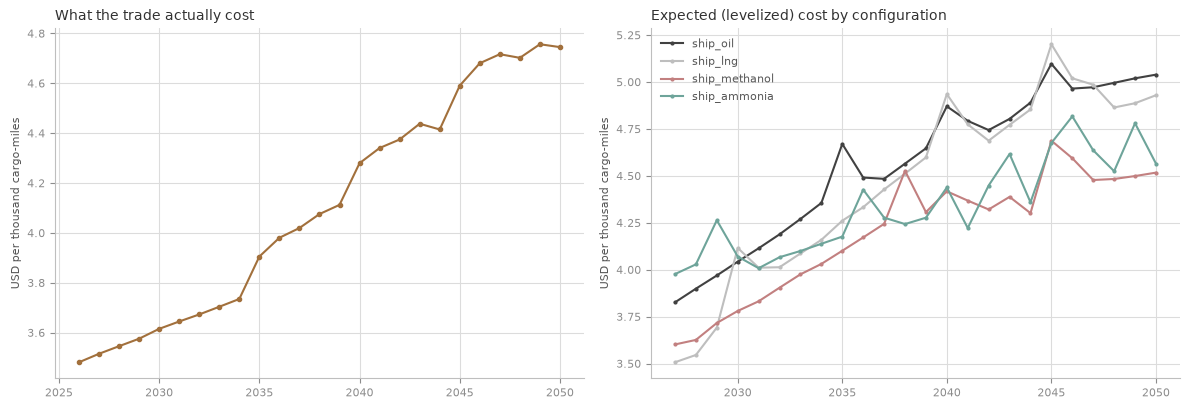

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# USD per THOUSAND cargo-miles, which is what Navigate's own
# fleet_investment_metric plot reports (divisor = 1./1e3) and what notebook 5
# uses. Per cargo-mile the numbers read 0.0046 - four leading zeros on an axis.
inst = 1e3 * np.asarray(copper_trade.profile.get_instantaneous_freight_rate(),
                        dtype=float)
ax1.plot(YEARS, inst, marker="o", ms=3, color=ORANGE)
ax1.set_title("What the trade actually cost", fontsize=10, color=INK, loc="left")
ax1.set_ylabel("USD per thousand cargo-miles", fontsize=8, color=SUBINK)

# What each configuration was expected to cost. This is the metric the
# newbuild choice is made on.
for name, vessel in base.nodes.vessels.items():
    ax2.plot(YEARS, 1e3 * np.asarray(vessel.profile.get_investment_freight_rate(),
                                     dtype=float),
             marker=".", ms=4, color=config_colour(name),
             label=config_label(name))
ax2.set_title("Expected (levelized) cost by configuration", fontsize=10, color=INK,
              loc="left")
ax2.set_ylabel("USD per thousand cargo-miles", fontsize=8, color=SUBINK)
ax2.legend(fontsize=8, frameon=False, labelcolor=SUBINK)

for ax in (ax1, ax2):
    ax.grid(color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

fig.tight_layout()

print(f"instantaneous freight rate   {YEARS[0]}: {inst[0]:.2f}   "
      f"{YEARS[-1]}: {inst[-1]:.2f}   ({(inst[-1] / inst[0] - 1) * 100:+.0f}%)")
print()
print("In the right-hand panel, whichever configuration sits lowest in a given")
print("year is the one most likely to be ordered that year. That crossover is")
print("the mechanism behind the fuel mix in section 2.")
plt.show()

## Who decided what

Every result in this notebook comes from one of four mechanisms. Worth keeping
straight, because they fail in different ways and respond to different inputs.

| Result you saw | Actor | Mechanism | Turn it with |
|---|---|---|---|
| Which fuel is bunkered where, each year | operator | **linear program**, all vessels at once, cost minimising | prices, supply, regulation |
| Speed, and fitting efficiency technology | operator | **heuristic on shadow prices** from the LP duals | `TechnologySensitivity`, `MaximumSpeedChange` |
| Retrofit or not | operator | **logit on NPV** against ship CAPEX | `FuelConversionSensitivity`, conversion costs |
| Newbuild mix | operator | **two-axis logit** on levelized transport cost | `InterFuelSensitivity`, `IntraFuelSensitivity` |
| Scrapping | operator | **age rule**, not a choice at all | `Lifetime`, `FixedScrapRate` |
| Which plants get built | producer | **two-axis logit** on demand then delivered cost | `FuelDemandSensitivity`, `FuelCostSensitivity` |
| Compliance cost | regulation | **exogenous**, no reaction | the regulation files |
| Cargo carried | nobody | **exogenous**, no demand response | `TradeGrowth` |

The last two are the ones to say out loud in a workshop. The regulator never
responds to the emissions it sees, and the cargo owner never responds to the
freight rate. So the 2050 cost increase above is absorbed in full by the
cargo owner, because the model gives them no way out.

The **Turn it with** column is the agenda for Part 4: every one of those is an
input we can change to see how much of the answer it was holding up.


---

# Part 4: Sensitivity analysis

The baseline is one answer under one set of assumptions. What matters is which
of them it depends on — so this part turns the dials from the table that closed
Part 3 and puts your version beside the reference.



Run the cell below to prepare the sensitivity analysis.

In [41]:
# ===========================================================================
#  The machinery. Nothing to edit here - the levers are in the next cell.
# ===========================================================================
from _style import scen_colour


def scale(forecast_name, factor):
    """Multiply a forecast by `factor`, keeping what the deck already set.

    set_multiplier REPLACES the Multiplier rather than compounding with it, and
    several library forecasts ship a non-unity one - fuel_eu_target_reduction
    is 91.16. Writing the factor straight in would not scale that limit, it
    would delete it.
    """
    def tweak(m):
        f = m.nodes.forecasts[forecast_name]
        f.set_multiplier(f.get_multiplier() * float(factor))
    return tweak

def both(*tweaks):
    """Apply several levers to one freshly parsed deck."""
    def tweak(m):
        for t in tweaks:
            t(m)
    return tweak

def penalty(factor):
    """Scale the FuelEU non-compliance penalty.

    The base value is the library's own Variable("fuel_eu_remedial_cost"),
    read off the parsed deck rather than hardcoded, so this lever follows the
    assumptions library if it is ever revised. It is a Variable and not a
    Forecast, which is why it needs its own helper rather than scale().
    """
    def tweak(m):
        base_cost = m.nodes.variables["fuel_eu_remedial_cost"].get()
        m.nodes.regulations["fuel_eu"].set_remedial_cost(base_cost * factor)
    return tweak

def sensitivity(attribute, odds):
    """Set one of the decision sensitivities outright.

    Unlike the price levers these are not multipliers: the value IS the odds
    ratio the deck would have carried, and what it is measured against depends
    on the metric. The fuel choice runs on LCOT, which is lower-is-better: the
    odds a fuel gets when its LCOT is 10% higher, so it sits below 1 and lower
    is sharper. Conversion and technology run on NPV: the odds an option gets
    when its NPV advantage equals 5% of the ship CAPEX, so they sit above 1 and
    higher is sharper.
    """
    def tweak(m):
        getattr(m.nodes.fleets["copper_trade"],
                f"set_{attribute}_sensitivity")(float(odds))
    return tweak

def chile_in_scope(m):
    """Put San Antonio inside both schemes.

    With both ends of the voyage in the jurisdiction it becomes an *intra*
    voyage, so IntraFraction = 1 applies and the whole trip is counted - the
    honest way to model full coverage, rather than editing InterFraction.
    """
    for r in ("eu_ets", "fuel_eu"):
        m.nodes.regulations[r].jurisdiction = [m.nodes.ports["rotterdam"],
                                               m.nodes.ports["san_antonio"]]

def without_new_technology(m):
    """Freeze efficiency where the fleet already is: nothing more gets fitted.

    BOTH limits are needed - the retrofit limit alone still lets a measure
    arrive on a newbuild. Measures with an initial share keep it, they just
    never grow.
    """
    fleet = m.nodes.fleets["copper_trade"]
    for technology in fleet.technologies:
        fleet.set_retrofit_technology_limit(technology.get_name(), 0.)
        fleet.set_newbuild_technology_limit(technology.get_name(), 0.)

TARGET = "fuel_eu_target_reduction"
FOSSIL = {"fossil_fuel_oil", "liquefied_natural_gas"}
# one lever each, named after the deck's own sensitivity, in the order Part 3
# met them. Inter and intra are the two axes of the newbuild choice: which fuel
# type, then which fuel within that type.
# IntraFuelSensitivity is left out on purpose: it picks between ship designs
# burning one fuel type, and this deck has a single design per type, so it is a
# group of one and no value changes anything. Part 3 says what it means.
SENSITIVITIES = [
    ("INTER_FUEL", "inter_fuel", "newbuild mix, between fuel types"),
    ("FUEL_CONVERSION", "fuel_conversion", "whether to retrofit an existing hull"),
    ("TECHNOLOGY", "technology", "whether to fit efficiency technology"),
]
# where each one starts, so the lever cell can tell an edited value from the
# default without those defaults being typed in twice
REFERENCE_ODDS = {
    _attribute: float(getattr(base.nodes.fleets["copper_trade"],
                              f"{_attribute}_sensitivity").get())
    for _lever, _attribute, _what in SENSITIVITIES}


def summarise(m):
    """One solve, read the way notebook 5 reads its fleets."""
    fleet = m.nodes.fleets["copper_trade"]
    years = years_of(m)
    wtw = np.nan_to_num(np.asarray(
        fleet.profile.get_total_equivalent_WTW(), dtype=float))

    energy, by_year = {}, {}
    for fuel, series in fleet.profile.get_consumed_energy().items():
        values = np.nan_to_num(np.asarray(series, dtype=float))
        if values.sum() <= 0:
            continue
        energy[fuel] = float(values.sum())
        by_year[fuel] = values
    grand = sum(energy.values())
    last_all = sum(float(v[-1]) for v in by_year.values())
    last_alt = sum(float(v[-1]) for f, v in by_year.items() if f not in FOSSIL)

    return {"years": years,
            "wtw": wtw / 1e3,                                  # kt CO2e per year
            "mix": {k: 100. * v / grand for k, v in energy.items()},
            # PJ per year, stacked in Navigate's own fuel order
            "by_year": {f: by_year[f] / 1e6 for f in fuel_sorted(by_year)},
            # USD per THOUSAND cargo-miles, as everywhere else in the workshop
            "freight": 1e3 * np.asarray(
                fleet.profile.get_instantaneous_freight_rate(), dtype=float),
            "alt_last": 100. * last_alt / last_all if last_all else 0.}


# `base` is the untouched Part 3 run and is already solved, so the reference
# costs nothing here - only your scenario is re-solved, once, below.
ref = summarise(base)

print(f"the reference, {YEARS[0]}-{YEARS[-1]}")
for _label, _value, _unit in (
        (f"well-to-wake in {YEARS[0]}", f"{ref['wtw'][0]:,.0f}", "kt CO2e/yr"),
        (f"well-to-wake in {YEARS[-1]}", f"{ref['wtw'][-1]:,.0f}", "kt CO2e/yr"),
        ("cumulative over the horizon", f"{ref['wtw'].sum():,.0f}", "kt CO2e"),
        (f"alternative fuels in {YEARS[-1]}", f"{ref['alt_last']:.1f}", "%"),
        (f"freight rate in {YEARS[-1]}", f"{ref['freight'][-1]:,.2f}",
         "USD per k cargo-mile")):
    print(f"  {_label:30} {_value:>9}  {_unit}")


# ---------------------------------------------------------------------------
# The levers, with the numbers they multiply. Read off the parsed deck rather
# than typed in here, so the table follows `assumptions/` if the Center revises
# it. Units are labels, not data, so those are stated.
# ---------------------------------------------------------------------------
LEVER_SPEC = [
    ("OIL_PRICE", "fossil bunker fuel",
     "fossil_fuel_oil_price_global", "USD/t", 1., "{:,.0f}"),
    ("GAS_PRICE", "fossil LNG",
     "liquefied_natural_gas_price_global", "USD/t", 1., "{:,.0f}"),
    ("CARBON_PRICE", "EU ETS allowance",
     "eu_ets_carbon_credit_price", "USD/t", 1., "{:,.0f}"),
    ("FUELEU_TARGET", "the FuelEU intensity limit",
     TARGET, "gCO2eq/MJ", 1., "{:,.1f}"),
    ("CHILEAN_POWER", "electricity at the Patagonian plants",
     "electricity_cost_americas_mid", "USD/MWh", 1., "{:,.0f}"),
    ("EUROPEAN_POWER", "electricity at the European plants",
     "electricity_cost_europe_mid", "USD/MWh", 1., "{:,.0f}"),
    ("BIOMASS", "the global gasifiable biomass pool",
     "feedstock_biomethanol_gasification_availability", "Mt/yr", 1e-6, "{:,.0f}"),
    ("BIOGENIC_CO2", "the global biogenic CO2 pool",
     "carbon_dioxide_biogenic_availability", "Mt/yr", 1e-6, "{:,.0f}"),
    ("TRADE_GROWTH", "growth of the copper trade",
     "trade_growth_bulk_carrier", "%/yr", 100., "{:,.1f}"),
]

_days = base.get_timeline()               # days since the deck's start date

print(f"{chr(10)}  the levers, and what the deck says today")
print(f"  {'':16}{'':38}{YEARS[0]:>11}{YEARS[-1]:>11}")
for _name, _what, _node, _unit, _factor, _fmt in LEVER_SPEC:
    _f = base.nodes.forecasts[_node]
    print(f"  {_name:16}{_what:38}"
          f"{_fmt.format(_f.calculate(_days[0]) * _factor):>11}"
          f"{_fmt.format(_f.calculate(_days[-1]) * _factor):>11}   {_unit}")
# the penalty is a Variable, not a Forecast: one number, no timeline
print(f"  {'FUELEU_PENALTY':16}{'a ton of excess emission':38}"
      f"{base.nodes.variables['fuel_eu_remedial_cost'].get():>11,.0f}"
      f"{base.nodes.variables['fuel_eu_remedial_cost'].get():>11,.0f}   USD/t")
# the sensitivities are odds ratios too: one number each, no timeline
for _lever, _attr, _what in SENSITIVITIES:
    _odds = float(getattr(base.nodes.fleets["copper_trade"],
                          f"{_attr}_sensitivity").get())
    print(f"  {_lever:16}{_what:38}{_odds:>11.2f}{_odds:>11.2f}   odds ratio")

the reference, 2026-2050
  well-to-wake in 2026               5,935  kt CO2e/yr
  well-to-wake in 2050               2,744  kt CO2e/yr
  cumulative over the horizon      119,139  kt CO2e
  alternative fuels in 2050           55.0  %
  freight rate in 2050                4.74  USD per k cargo-mile

  the levers, and what the deck says today
                                                               2026       2050
  OIL_PRICE       fossil bunker fuel                            485        485   USD/t
  GAS_PRICE       fossil LNG                                    436        436   USD/t
  CARBON_PRICE    EU ETS allowance                              126        417   USD/t
  FUELEU_TARGET   the FuelEU intensity limit                   89.3       18.2   gCO2eq/MJ
  CHILEAN_POWER   electricity at the Patagonian plants           62         41   USD/MWh
  EUROPEAN_POWER  electricity at the European plants             72         53   USD/MWh
  BIOMASS         the global gasifiable biomass p

## The levers

The results of the previous cell give you the value of some levers in the reference scenario that we have been using throughout this part of the workshop. Use the cell below to change the original values and see what happens! 

All levers that we prepared can be changed with multipliers, except two that can be used as switches:

- **`FULL_COVERAGE`** puts San Antonio inside both regulatory schemes.
- **`FREEZE_EFFICIENCY`** stops anything further being fitted, on newbuilds as
  well as on retrofits.

One last group changes the operator rather than the world it operates in.
These are not multipliers: each one *is* one of the sensitivities you met in
Part 3 - the "behavioral traits" that turn a gap into a share - so you set the
odds ratio directly, starting from the value the deck already carries:

- **`INTER_FUEL`** (`InterFuelSensitivity`): how sharply it picks between fuel
  types when ordering a newbuild.
- **`FUEL_CONVERSION`** (`FuelConversionSensitivity`): how decisively it
  retrofits a hull it already owns.
- **`TECHNOLOGY`** (`TechnologySensitivity`): how decisively it fits efficiency
  technology.

The fourth one, `IntraFuelSensitivity`, has no lever because it cannot decide
anything here: it picks between ship designs burning the *same* fuel type, and
this deck has one design per type.

What an odds ratio is measured against depends on the metric. `INTER_FUEL`
runs on levelized transport cost, which is lower-is-better: it is the odds a
fuel gets when its cost is 10 % higher, so `0.5` halves them. It sits *below* 1,
and moving it further down makes the operator more decisive. The other two run
on NPV: they are the odds an option gets when its NPV advantage is worth 5 % of
the ship CAPEX, so `2` doubles them. They sit *above* 1, and moving them up does
the same. Push any of them towards 1 and the operator stops
caring, spreading its orders evenly instead.

Because these are calibration rather than assumptions about the world, treat
what they do as a check on how much the answer rests on the model of the
operator, not as scenarios you could go out and bring about.

**GAME**: Find out which scenario (realistic?) leads to the lowest emissions and transport costs by 2050!

In [42]:
# ===========================================================================
#  YOUR SCENARIO.  Set a lever, run the cell, read the answer below it.
#
#  Every number down to TRADE_GROWTH is a MULTIPLIER on what the deck already
#  says, so 1.0 is the reference. The cell above printed what each 1.0 is worth
#  at both ends of the horizon, so you can judge whether a factor of two is a
#  big change or a small one. The BEHAVIOR block at the bottom is not like that:
#  those are the values themselves, and they start at the deck's own. The
#  right-hand column repeats that table for convenience; the printed one is read
#  off the parsed deck, so trust it if the two ever disagree.
#
#                        suggested span   what 1.0 means in the deck
OIL_PRICE      = 1.0   #  0.7 - 1.6       485 USD/t, flat to 2050
GAS_PRICE      = 1.0   #  0.7 - 1.6       436 USD/t, flat to 2050
CARBON_PRICE   = 1.0   #  0.5 - 3.0       126 USD/t in 2026, 417 by 2050
FUELEU_TARGET  = 1.0   #  0.3 - 1.2       89.3 gCO2eq/MJ in 2026, 18.2 by 2050; under 1.0 is STRICTER
FUELEU_PENALTY = 1.0   #  1.0 - 5.0       760 USD/t of excess emission, flat
CHILEAN_POWER  = 1.0   #  0.6 - 1.4       62 USD/MWh in 2026, 41 by 2050
EUROPEAN_POWER = 1.0   #  0.6 - 1.4       72 USD/MWh in 2026, 53 by 2050
BIOMASS        = 1.0   #  0.1 - 10.0      1,152 Mt/yr pool in 2026, 1,361 by 2050; this ceiling BINDS
BIOGENIC_CO2   = 1.0   #  0.5 - 2.0       92 Mt/yr pool in 2026, 350 by 2050; binds 2049, gone by x2
TRADE_GROWTH   = 1.0   #  0.0 - 2.0       2.2 %/yr in 2026, 1.4-1.5 %/yr from 2030
#                          1.0 = the deck's growth; 0.0 = trade stays at its 2026 volume;
#                         -1.0 = trade shrinks as fast as it would have grown

FULL_COVERAGE     = False   # San Antonio inside both schemes: the whole voyage counts
FREEZE_EFFICIENCY = False   # nothing further gets fitted, newbuild or retrofit

#  BEHAVIOR. Not a price and not a rule: how the operator itself decides, one
#  lever per decision. These are the odds ratios themselves, NOT multipliers,
#  and they start at what the deck says. Which way sharpens differs by metric.
#
#                         suggested span   which way is sharper
INTER_FUEL      = 0.75  #  0.3 - 0.95     LOWER is sharper: LCOT, lower-is-better
FUEL_CONVERSION = 2.0   #  1.2 - 16       HIGHER is sharper: NPV against ship CAPEX
TECHNOLOGY      = 2.0   #  1.2 - 16       HIGHER is sharper: NPV on the measure
# ===========================================================================

from matplotlib.ticker import MaxNLocator

MULTIPLIERS = [("OIL_PRICE", OIL_PRICE, "fossil_fuel_oil_price_global"),
               ("GAS_PRICE", GAS_PRICE,
                "liquefied_natural_gas_price_global"),
               ("CARBON_PRICE", CARBON_PRICE, "eu_ets_carbon_credit_price"),
               ("FUELEU_TARGET", FUELEU_TARGET, TARGET),
               ("CHILEAN_POWER", CHILEAN_POWER, "electricity_cost_americas_mid"),
               ("EUROPEAN_POWER", EUROPEAN_POWER, "electricity_cost_europe_mid"),
               ("BIOMASS", BIOMASS,
                "feedstock_biomethanol_gasification_availability"),
               ("BIOGENIC_CO2", BIOGENIC_CO2, "carbon_dioxide_biogenic_availability"),
               ("TRADE_GROWTH", TRADE_GROWTH, "trade_growth_bulk_carrier")]

# Trade is compounded as log(1 + growth), so a year shrinking by 100 % or more has
# no meaning - say so here rather than let the solve fail on it.
_growth = base.nodes.forecasts["trade_growth_bulk_carrier"]
if min(TRADE_GROWTH * _growth.calculate(_d) for _d in base.get_timeline()) <= -1.:
    raise ValueError(f"TRADE_GROWTH = {TRADE_GROWTH} would make trade shrink by 100 % "
                     "or more in a year. Pick a value closer to zero.")

CHANGED = [(n, v) for n, v, _ in MULTIPLIERS if v != 1.0]
TWEAKS = [scale(t, v) for n, v, t in MULTIPLIERS if v != 1.0]
if FUELEU_PENALTY != 1.0:
    CHANGED.append(("FUELEU_PENALTY", FUELEU_PENALTY))
    TWEAKS.append(penalty(FUELEU_PENALTY))
if FULL_COVERAGE:
    CHANGED.append(("FULL_COVERAGE", True))
    TWEAKS.append(chile_in_scope)
if FREEZE_EFFICIENCY:
    CHANGED.append(("FREEZE_EFFICIENCY", True))
    TWEAKS.append(without_new_technology)
BEHAVIOR = [("INTER_FUEL", INTER_FUEL, "inter_fuel"),
            ("FUEL_CONVERSION", FUEL_CONVERSION, "fuel_conversion"),
            ("TECHNOLOGY", TECHNOLOGY, "technology")]
CHANGED += [(n, v) for n, v, a in BEHAVIOR if v != REFERENCE_ODDS[a]]
TWEAKS += [sensitivity(a, v) for _n, v, a in BEHAVIOR if v != REFERENCE_ODDS[a]]

if not TWEAKS:
    print("Every lever is still at its reference, so this would just re-solve it.")
    print("Change one of the numbers above and run this cell again.")
else:
    print("solving your scenario:")
    for _name, _value in CHANGED:
        print(f"  {_name:16} {_value}")
    yours = run_case(both(*TWEAKS))
    you = summarise(yours)

    print(f"{chr(10)}  {'':32} {'reference':>11} {'yours':>11} {'change':>13}")
    for _label, _r, _y, _fmt, _pp in (
            (f"well-to-wake in {YEARS[-1]}, kt/yr",
             ref["wtw"][-1], you["wtw"][-1], ",.0f", False),
            ("cumulative, kt", ref["wtw"].sum(), you["wtw"].sum(), ",.0f", False),
            # a share is already a percentage, so it moves in POINTS, not per cent
            (f"alternative fuels in {YEARS[-1]}, %",
             ref["alt_last"], you["alt_last"], ".1f", True),
            (f"freight rate in {YEARS[-1]}, USD/k mile",
             ref["freight"][-1], you["freight"][-1], ",.2f", False)):
        _change = (f"{_y - _r:+.1f} pp" if _pp
                   else f"{100. * (_y / _r - 1.):+.1f} %")
        print(f"  {_label:32} {_r:11{_fmt}} {_y:11{_fmt}} {_change:>13}")

    order = ["reference", "your scenario"]
    cases = {"reference": ref, "your scenario": you}

    # Emissions and cost span both rows; the mix gets one row each, on a shared
    # scale, so the two can be read against each other rather than separately.
    fig = plt.figure(figsize=(15.5, 6.6), constrained_layout=True)
    grid = fig.add_gridspec(2, 3, width_ratios=[1.1, 1.3, 1.0])
    axE = fig.add_subplot(grid[:, 0])
    axR = fig.add_subplot(grid[0, 1])
    axY = fig.add_subplot(grid[1, 1], sharex=axR, sharey=axR)
    axC = fig.add_subplot(grid[:, 2])

    for s in order:
        axE.plot(cases[s]["years"], cases[s]["wtw"], lw=2, marker=".", ms=5,
                 label=s, color=scen_colour(s))
    axE.set_title("Well-to-wake emissions", fontsize=10, color=INK, loc="left")
    axE.set_ylabel("kt CO2e per year", fontsize=8, color=SUBINK)
    axE.set_ylim(bottom=0.)
    axE.legend(fontsize=8, frameon=False, labelcolor=SUBINK,
               loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=1)

    fuels = fuel_sorted({f for c in cases.values() for f in c["by_year"]})
    for ax, s in zip((axR, axY), order):
        stack = [cases[s]["by_year"].get(f, np.zeros(len(cases[s]["years"])))
                 for f in fuels]
        ax.stackplot(cases[s]["years"], *stack,
                     colors=[fuel_colour(f) for f in fuels],
                     labels=[fuel_label(f) for f in fuels], linewidth=0, alpha=.9)
        ax.set_title(f"Fuel bunkered, {s}", fontsize=10, color=INK, loc="left")
        ax.set_ylabel("PJ per year", fontsize=8, color=SUBINK)
        ax.margins(x=0)
    axY.legend(fontsize=7, frameon=False, labelcolor=SUBINK, ncol=5,
               loc="upper center", bbox_to_anchor=(0.5, -0.18))

    # the two end labels land within a few cents of each other, so push the
    # lower series' label below its point rather than letting them overlap
    _high = max(order, key=lambda s: cases[s]["freight"][-1])
    for s in order:
        axC.plot(cases[s]["years"], cases[s]["freight"], lw=2, marker=".", ms=5,
                 label=s, color=scen_colour(s))
        axC.annotate(f"{cases[s]['freight'][-1]:,.2f}",
                     (cases[s]["years"][-1], cases[s]["freight"][-1]),
                     xytext=(-4, 7 if s == _high else -14),
                     textcoords="offset points", ha="right",
                     fontsize=8, color=scen_colour(s), fontweight="bold")
    axC.set_title("Freight rate: what moving the cargo cost", fontsize=10,
                  color=INK, loc="left")
    axC.set_ylabel("USD per thousand cargo-miles", fontsize=8, color=SUBINK)
    axC.set_ylim(bottom=0.)
    # The rate carries what the fleet pays out and almost nothing it gets back:
    # Navigate has no rebate or subsidy funded from what a regulator collects,
    # so a scheme that recycled its revenue would sit lower than this.
    axC.text(.02, .03,
             "Carbon and compliance payments are in this rate." + chr(10)
             + "None of what regulators collect is paid back:" + chr(10)
             + "the model has no rebate or subsidy funded from it.",
             transform=axC.transAxes, fontsize=7, color=SUBINK,
             va="bottom", ha="left", linespacing=1.5)

    for ax in (axE, axR, axY, axC):
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(color=GRID, lw=.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=TICK, labelsize=8, length=0)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(AXIS)

    fig.suptitle("  " + ",  ".join(f"{n} x {v}" for n, v in CHANGED),
                 fontsize=9, color=SUBINK, x=0.01, ha="left")
    plt.show()

    print("what moved most, in percentage points of the fuel mix:")
    _delta = sorted(((you["mix"].get(f, 0.) - ref["mix"].get(f, 0.), f)
                     for f in set(ref["mix"]) | set(you["mix"])),
                    key=lambda d: -abs(d[0]))
    for _d, _f in _delta[:5]:
        print(f"  {fuel_label(_f):20} {_d:+6.1f} pp")

Every lever is still at its reference, so this would just re-solve it.
Change one of the numbers above and run this cell again.


## Do you want more?

Advanced sensitivities or personalized simulations can be done by:
- editing the deck in `simulations/examples/example_4/` itself (needs a local installation)
- building a new case from scratch as [notebook 3](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-build-your-own-case.ipynb) describes (needs a local installation)
- you can also check out our Horizon-zcs tool on GitHub for global sensitivity analysis (which is what we are using for our own analyses)

## Workshop notebooks

**Next: [3. Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-build-your-own-case.ipynb)**

Each link opens the notebook in Google Colab, in a fresh session, so run it
from the top.

1. [Test set-up](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-setup-and-quicktest.ipynb)
2. **Illustrating the Navigate logic with a simple case** (this notebook)
3. [Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-build-your-own-case.ipynb) (you can read it in Colab; its prompts need Navigate installed on your own machine)
4. [Run the reference scenarios](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-a-reference-scenario.ipynb)
5. [Change the numbers and see what moves](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-whatif.ipynb)